# PHASE 1: PREPARATION

## Step 1: Load All Raw Data

**Purpose**  
Loads the full set of raw empirical inputs required for the quantitative model, including electricity price data, generation and consumption data, financial market benchmarks, and project-level technical and commercial assumptions.

**Methodology**  
Raw input data are imported from publicly available and institutionally maintained sources and standardised for downstream processing in the empirical model. The raw data is loaded at hourly frequency where relevant and retained in its original form before monthly aggregation and transformation in later steps.

**Specifications**

- **Primary:** DK1 day-ahead electricity prices
- **Robustness:** DK2 day-ahead electricity prices

**Parameters / Inputs**
- Historical hourly day-ahead spot prices for DK1 and DK2 from the ENTSO-E Transparency Platform
- Sample period: 1 January 2019 to 31 December 2025
- Number of hourly observations: 87,614 per bidding zone
- Unit: EUR/MWh
- Hourly solar production data from Energinet’s Energi Data Service
- Hourly gross consumption data from Energinet’s Energi Data Service
- Ten-year Danish government bond yield from Danmarks Nationalbank as the risk-free rate proxy
- Damodaran sector-level unlevered asset betas for the global power sector and the global green and renewable energy sector
- Damodaran Denmark Equity Risk Premium (ERP)
- Technical and commercial assumptions from IEA (2025), IRENA (2024), Pexapark (2025), LevelTen Energy (2025), and KYOS (2025)

**Output**  
Creates the raw hourly and benchmark input objects used in Step 2 for monthly aggregation, capture-price construction, and the preparation of financial and technical model inputs.


DK1: 87614 observations | 2019-01-01 to 2025-12-31
DK2: 87614 observations | 2019-01-01 to 2025-12-31

Solar data: 61440 rows
Period: 2019-01-01 00:00:00 to 2025-12-31 23:00:00
Columns: ['HourUTC', 'HourDK', 'SolarPowerGe40kW_MWhDK1', 'SolarPowerGe40kW_MWhDK2', 'GrossConsumptionMWhDK1', 'GrossConsumptionMWhDK2']

All raw data loaded successfully!


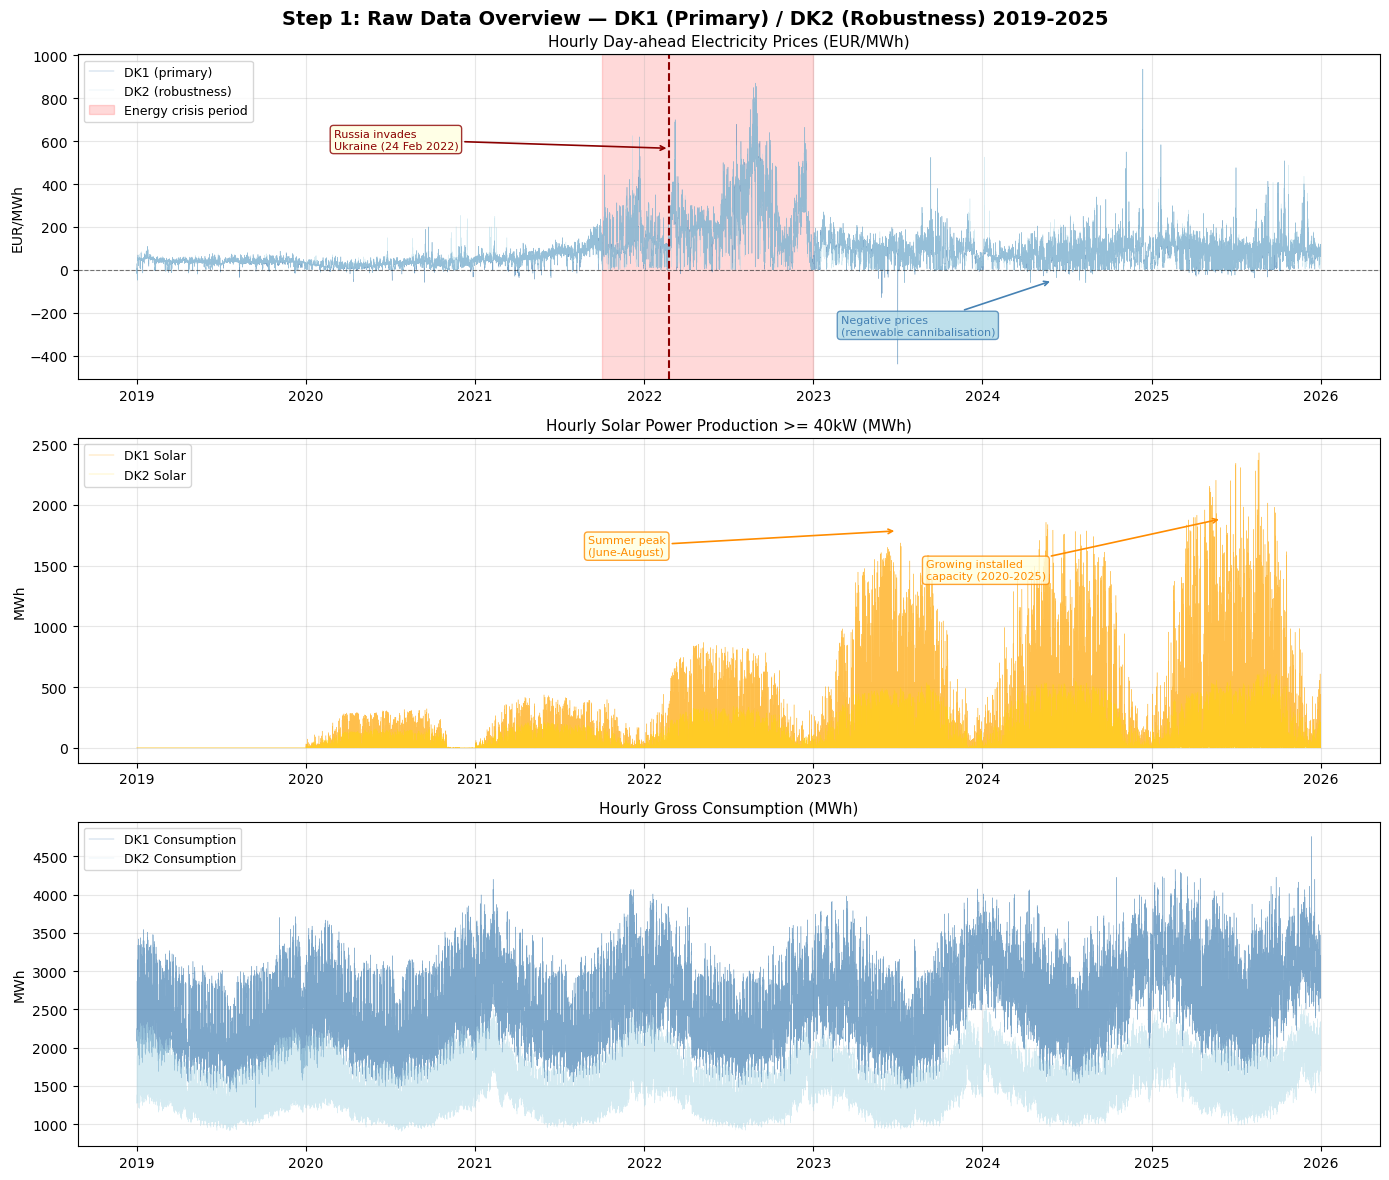

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step1_Raw_Data_Overview.png
Individual plots saved: Step1a, Step1b, Step1c


In [84]:
# ── STEP 1: LOAD ALL RAW DATA ──────────────────────────────────────────────
# Source 1: ENTSO-E Transparency Platform — Day-ahead Energy Prices
#           DK1 = primary specification | DK2 = robustness check
#           Period: 01/01/2019 - 31/12/2025 | Frequency: Hourly
# Source 2: Energy Data Service (Energinet.dk) — Solar Production + Gross Consumption
#           Period: 01/01/2019 - 31/12/2025 | Frequency: Hourly
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
# ── FILE PATHS ─────────────────────────────────────────────────────────────
base      = '/Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis'
raw_elec  = base + '/1. Raw data/1. Electricity Prices'
raw_solar = base + '/1. Raw data/2. Solar and Consumption Data'
# ── LOAD ELECTRICITY PRICES (ENTSO-E) ──────────────────────────────────────
def load_zone(folder):
    dfs = []
    for f in sorted(os.listdir(folder)):
        if f.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder, f), quotechar='"')
            df.columns = ['MTU','Area','Sequence','Price','IntraP','IntraPrice']
            df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
            df['datetime'] = pd.to_datetime(
                df['MTU'].str.split(' - ').str[0],
                format='%d/%m/%Y %H:%M:%S', errors='coerce')
            df = df.dropna(subset=['datetime','Price'])
            dfs.append(df)
    combined = pd.concat(dfs).sort_values('datetime').drop_duplicates('datetime')
    return combined

dk1 = load_zone(raw_elec + '/DK1')
dk2 = load_zone(raw_elec + '/DK2')
print(f"DK1: {len(dk1)} observations | {dk1['datetime'].min().date()} to {dk1['datetime'].max().date()}")
print(f"DK2: {len(dk2)} observations | {dk2['datetime'].min().date()} to {dk2['datetime'].max().date()}")
# ── LOAD ENERGINET SOLAR AND CONSUMPTION DATA ──────────────────────────────
energy_file = raw_solar + '/Solar and Consumption Data (Energinet).xlsx'
solar_raw   = pd.read_excel(energy_file, sheet_name='data')
print(f"\nSolar data: {len(solar_raw)} rows")
print(f"Period: {solar_raw['HourDK'].min()} to {solar_raw['HourDK'].max()}")
print(f"Columns: {solar_raw.columns.tolist()}")
print("\nAll raw data loaded successfully!")
# ── VISUALISATION ──────────────────────────────────────────────────────────
solar_raw['datetime_plot'] = pd.to_datetime(solar_raw['HourDK'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Step 1: Raw Data Overview — DK1 (Primary) / DK2 (Robustness) 2019-2025',
             fontsize=14, fontweight='bold', y=0.98)
# ── Plot 1: Hourly electricity prices ─────────────────────────────────────
ax1 = axes[0]
ax1.plot(dk1['datetime'], dk1['Price'], color='steelblue',
         linewidth=0.3, alpha=0.7, label='DK1 (primary)')
ax1.plot(dk2['datetime'], dk2['Price'], color='lightblue',
         linewidth=0.3, alpha=0.5, label='DK2 (robustness)')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.axvspan(datetime(2021,10,1), datetime(2023,1,1),
            alpha=0.15, color='red', label='Energy crisis period')
ax1.axvline(x=datetime(2022,2,24), color='darkred', linewidth=1.5, linestyle='--')
ax1.annotate('Russia invades\nUkraine (24 Feb 2022)',
             xy=(datetime(2022,2,24), dk1['Price'].quantile(0.999)*0.85),
             xytext=(datetime(2020,3,1), dk1['Price'].quantile(0.999)*0.85),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax1.annotate('Negative prices\n(renewable cannibalisation)',
             xy=(datetime(2024,6,1), -50),
             xytext=(datetime(2023,3,1), -300),
             fontsize=8, color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue',
                       edgecolor='steelblue', alpha=0.8))
ax1.set_title('Hourly Day-ahead Electricity Prices (EUR/MWh)', fontsize=11)
ax1.set_ylabel('EUR/MWh')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)
# ── Plot 2: Solar production ───────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(solar_raw['datetime_plot'], solar_raw['SolarPowerGe40kW_MWhDK1'],
         color='orange', linewidth=0.3, alpha=0.7, label='DK1 Solar')
ax2.plot(solar_raw['datetime_plot'], solar_raw['SolarPowerGe40kW_MWhDK2'],
         color='gold', linewidth=0.3, alpha=0.5, label='DK2 Solar')
ax2.annotate('Summer peak\n(June-August)',
             xy=(datetime(2023,7,1),
                 solar_raw['SolarPowerGe40kW_MWhDK1'].quantile(0.999)*0.9),
             xytext=(datetime(2021,9,1),
                     solar_raw['SolarPowerGe40kW_MWhDK1'].quantile(0.999)*0.8),
             fontsize=8, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkorange', alpha=0.8))
ax2.annotate('Growing installed\ncapacity (2020-2025)',
             xy=(datetime(2025,6,1),
                 solar_raw['SolarPowerGe40kW_MWhDK1'].quantile(0.999)*0.95),
             xytext=(datetime(2023,9,1),
                     solar_raw['SolarPowerGe40kW_MWhDK1'].quantile(0.999)*0.7),
             fontsize=8, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkorange', alpha=0.8))
ax2.set_title('Hourly Solar Power Production >= 40kW (MWh)', fontsize=11)
ax2.set_ylabel('MWh')
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)
# ── Plot 3: Gross consumption ──────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(solar_raw['datetime_plot'], solar_raw['GrossConsumptionMWhDK1'],
         color='steelblue', linewidth=0.3, alpha=0.7, label='DK1 Consumption')
ax3.plot(solar_raw['datetime_plot'], solar_raw['GrossConsumptionMWhDK2'],
         color='lightblue', linewidth=0.3, alpha=0.5, label='DK2 Consumption')
ax3.set_title('Hourly Gross Consumption (MWh)', fontsize=11)
ax3.set_ylabel('MWh')
ax3.legend(loc='upper left', fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(True, alpha=0.3)

plt.tight_layout()

# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step1_Raw_Data_Overview.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")

# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()

extent1 = ax1.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step1a_Electricity_Prices.png', dpi=300, bbox_inches=extent1)

extent2 = ax2.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step1b_Solar_Production.png', dpi=300, bbox_inches=extent2)

extent3 = ax3.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step1c_Gross_Consumption.png', dpi=300, bbox_inches=extent3)

# ── GLOBAL PROJECT PARAMETERS ──────────────────────────────────────────────
N_MONTHS = 300        # 25 years × 12 months
N_PATHS = 10000       # Monte Carlo paths
PPA_MONTHS = 120      # 10-year PPA tenor
master_path = '/Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx'
# ... any other shared constants

print("Individual plots saved: Step1a, Step1b, Step1c")

## Step 2: Monthly Aggregation & Capture Price Calculation

**Purpose**  
Transforms hourly data into monthly observations for stochastic modelling and cannibalisation analysis.

**Methodology**  
Three monthly transformations are performed:

$$
\text{Monthly Spot Price}_m = \frac{1}{N_m}\sum_{h \in m} P_h
$$

$$
\text{Solar Penetration}_m = \frac{\text{Solar Production}_m}{\text{Gross Consumption}_m}
$$

$$
\text{Capture Price}_m = \frac{\sum_{h \in m} \left(P_h \cdot Solar_h\right)}{\sum_{h \in m} Solar_h}
$$

$$
CPR_m = \frac{\text{Capture Price}_m}{\text{Spot Price}_m}
$$

**Specifications**

- **Primary:** DK1 monthly spot price, solar penetration, capture price, and CPR
- **Robustness:** DK2 monthly spot price, solar penetration, capture price, and CPR

**Parameters / Inputs**
- Hourly day-ahead prices
- Hourly solar production
- Hourly gross consumption
- Sample period: 2019–2025
- Monthly output frequency
- Solar-derived variables available from January 2020 onwards only

**Sub-blocks**
- **2A: Monthly spot prices:** arithmetic mean of all hourly prices within each calendar month for DK1 and DK2
- **2B: Solar penetration proxy:** monthly solar production divided by monthly gross consumption; used as the independent variable (X) in the cannibalisation regression in Step 7
- **2C: Capture price and CPR:** solar-weighted average monthly price and the corresponding capture-price ratio

**Output**  
Produces a monthly dataframe with 84 observations (2019–2025). The 2019 observations retain spot-price data but are set to NaN for all solar-derived variables because Energinet solar production data begins in January 2020. DK1 penetration and DK1 CPR are the primary series used in the cannibalisation regression.

Monthly observations: 84
Period: 2019-01-01 to 2025-12-01

Sample (first 3 rows from 2020):
      month   DK1_Spot   DK2_Spot  DK1_Penetration  DK1_Capture_Price   DK1_CPR
12  2020-01  24.994543  27.385242         0.002264          25.223210  1.009149
13  2020-02  17.585072  18.816997         0.005247          22.835819  1.298591
14  2020-03  18.301727  20.052497         0.020202          15.941073  0.871015

Monthly aggregation complete!


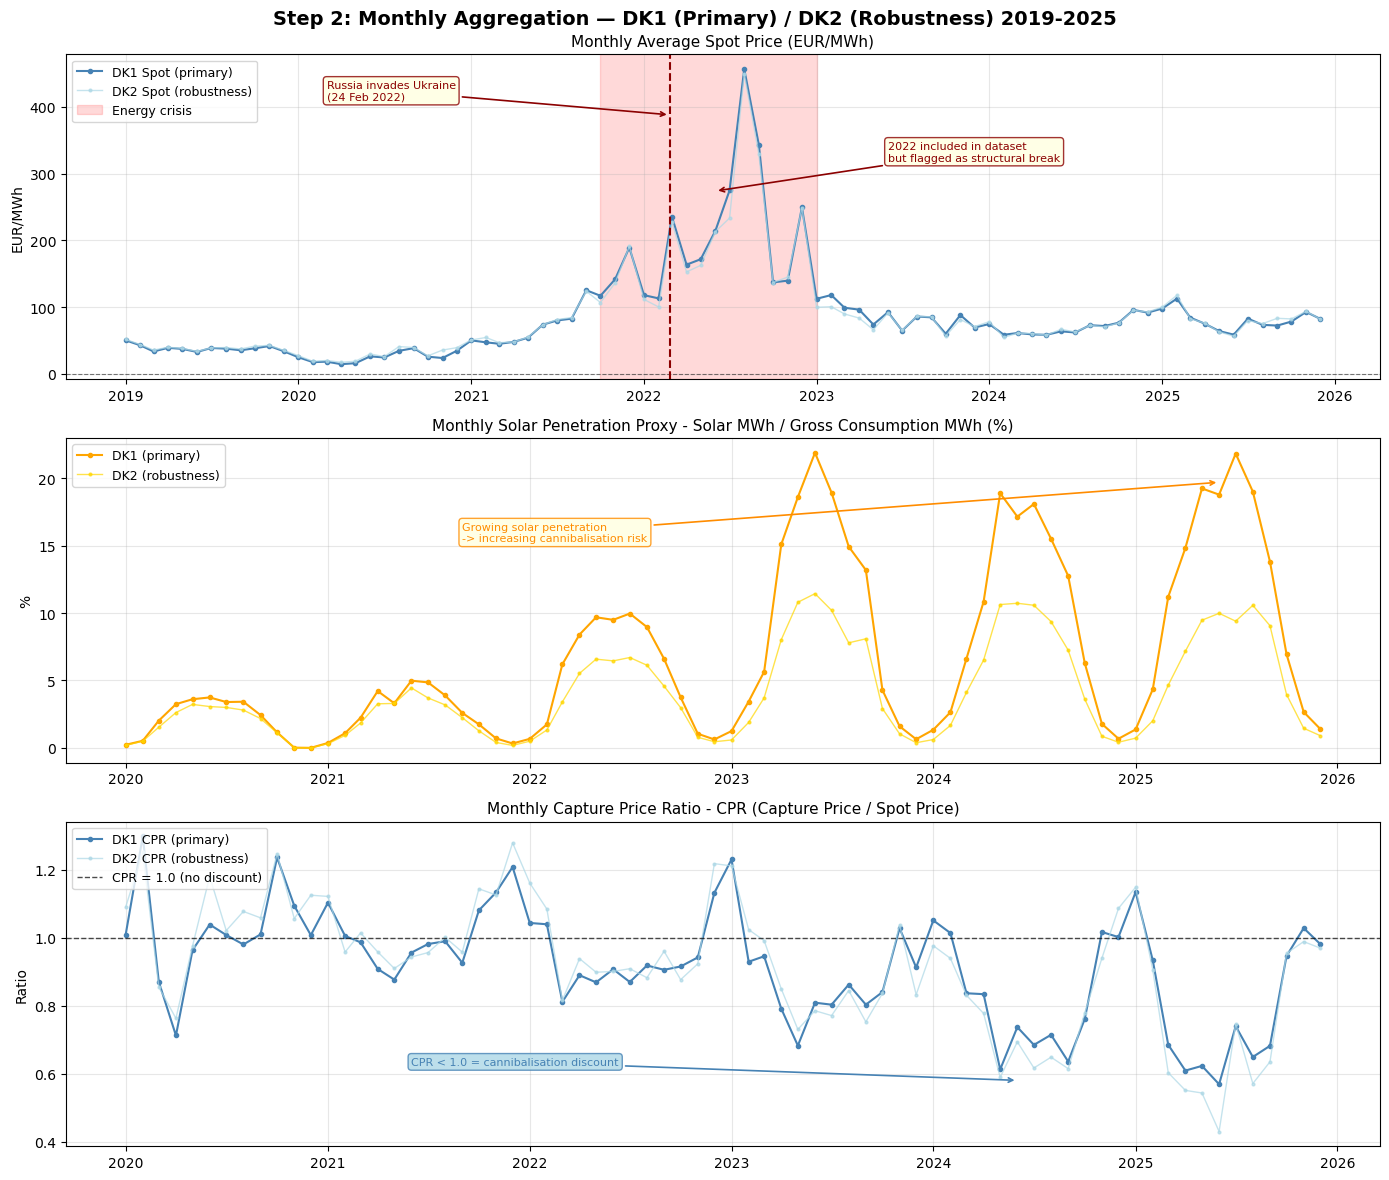

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step2_Monthly_Aggregation.png
Individual plots saved: Step2a, Step2b, Step2c
Capture Price Inputs exported — 84 rows | DK1 primary | DK2 robustness


In [85]:
# ── STEP 2: MONTHLY AGGREGATION & CAPTURE PRICE CALCULATION ───────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
# ── DEFENSIVE GUARD: ensure dk1 and dk2 are proper DataFrames ─────────────
if not isinstance(dk1, pd.DataFrame) or 'datetime' not in dk1.columns:
    print("dk1 not a DataFrame with 'datetime' column — reloading from Step 1...")
    dk1 = load_zone(raw_elec + '/DK1')
if not isinstance(dk2, pd.DataFrame) or 'datetime' not in dk2.columns:
    print("dk2 not a DataFrame with 'datetime' column — reloading from Step 1...")
    dk2 = load_zone(raw_elec + '/DK2')
# ── 2A: MONTHLY SPOT PRICES ────────────────────────────────────────────────
dk1['month'] = dk1['datetime'].dt.to_period('M')
dk2['month'] = dk2['datetime'].dt.to_period('M')
monthly_dk1 = dk1.groupby('month')['Price'].mean().reset_index()
monthly_dk2 = dk2.groupby('month')['Price'].mean().reset_index()
monthly_dk1.columns = ['month', 'DK1_Spot']
monthly_dk2.columns = ['month', 'DK2_Spot']
# ── 2B: SOLAR PENETRATION PROXY ────────────────────────────────────────────
solar_raw['datetime'] = pd.to_datetime(solar_raw['HourDK'])
solar_raw['month']    = solar_raw['datetime'].dt.to_period('M')
solar_monthly = solar_raw.groupby('month').agg(
    DK1_Solar_MWh   = ('SolarPowerGe40kW_MWhDK1', 'sum'),
    DK2_Solar_MWh   = ('SolarPowerGe40kW_MWhDK2', 'sum'),
    DK1_Consumption = ('GrossConsumptionMWhDK1',  'sum'),
    DK2_Consumption = ('GrossConsumptionMWhDK2',  'sum')
).reset_index()
monthly = monthly_dk1.merge(monthly_dk2, on='month')
monthly = monthly.merge(solar_monthly, on='month')
monthly['month_dt'] = monthly['month'].dt.to_timestamp()
# Solar Penetration = Solar MWh / Gross Consumption MWh
monthly['DK1_Penetration'] = monthly['DK1_Solar_MWh'] / monthly['DK1_Consumption']
monthly['DK2_Penetration'] = monthly['DK2_Solar_MWh'] / monthly['DK2_Consumption']
# ── 2C: CAPTURE PRICE & CPR ────────────────────────────────────────────────
dk1_weighted = dk1.copy()
dk1_weighted['month'] = dk1_weighted['datetime'].dt.to_period('M')
dk1_solar_h  = solar_raw[['datetime','month','SolarPowerGe40kW_MWhDK1']].copy()
dk1_solar_h.columns = ['datetime','month','Solar_DK1']
dk1_merged   = dk1_weighted.merge(dk1_solar_h[['datetime','Solar_DK1']],
                                   on='datetime', how='left')
dk1_merged['PxQ_DK1'] = dk1_merged['Price'] * dk1_merged['Solar_DK1']
dk2_weighted = dk2.copy()
dk2_weighted['month'] = dk2_weighted['datetime'].dt.to_period('M')
dk2_solar_h  = solar_raw[['datetime','month','SolarPowerGe40kW_MWhDK2']].copy()
dk2_solar_h.columns = ['datetime','month','Solar_DK2']
dk2_merged   = dk2_weighted.merge(dk2_solar_h[['datetime','Solar_DK2']],
                                   on='datetime', how='left')
dk2_merged['PxQ_DK2'] = dk2_merged['Price'] * dk2_merged['Solar_DK2']
dk1_capture = dk1_merged.groupby('month').agg(
    PxQ_DK1_sum = ('PxQ_DK1', 'sum'),
    Q_DK1_sum   = ('Solar_DK1', 'sum')
).reset_index()
dk1_capture['DK1_Capture_Price'] = dk1_capture['PxQ_DK1_sum'] / dk1_capture['Q_DK1_sum']
dk2_capture = dk2_merged.groupby('month').agg(
    PxQ_DK2_sum = ('PxQ_DK2', 'sum'),
    Q_DK2_sum   = ('Solar_DK2', 'sum')
).reset_index()
dk2_capture['DK2_Capture_Price'] = dk2_capture['PxQ_DK2_sum'] / dk2_capture['Q_DK2_sum']
monthly = monthly.merge(dk1_capture[['month','DK1_Capture_Price']], on='month', how='left')
monthly = monthly.merge(dk2_capture[['month','DK2_Capture_Price']], on='month', how='left')
monthly['DK1_CPR'] = monthly['DK1_Capture_Price'] / monthly['DK1_Spot']
monthly['DK2_CPR'] = monthly['DK2_Capture_Price'] / monthly['DK2_Spot']
# ── Solar/CPR metrics only available from 2020 ────────────────────────────
solar_start = pd.Timestamp('2020-01-01')
monthly.loc[monthly['month_dt'] < solar_start,
            ['DK1_Penetration','DK2_Penetration',
             'DK1_Capture_Price','DK2_Capture_Price',
             'DK1_CPR','DK2_CPR']] = np.nan
print(f"Monthly observations: {len(monthly)}")
print(f"Period: {monthly['month_dt'].min().date()} to {monthly['month_dt'].max().date()}")
print(f"\nSample (first 3 rows from 2020):")
print(monthly[['month','DK1_Spot','DK2_Spot',
               'DK1_Penetration','DK1_Capture_Price','DK1_CPR']]
      [monthly['month_dt'] >= '2020-01-01'].head(3).to_string())
print("\nMonthly aggregation complete!")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Step 2: Monthly Aggregation — DK1 (Primary) / DK2 (Robustness) 2019-2025',
             fontsize=14, fontweight='bold', y=0.98)
# ── Plot 1: Monthly spot prices ────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(monthly['month_dt'], monthly['DK1_Spot'], color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='DK1 Spot (primary)')
ax1.plot(monthly['month_dt'], monthly['DK2_Spot'], color='lightblue',
         linewidth=1.0, marker='o', markersize=2, alpha=0.7,
         label='DK2 Spot (robustness)')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.axvspan(datetime(2021,10,1), datetime(2023,1,1),
            alpha=0.15, color='red', label='Energy crisis')
ax1.axvline(x=datetime(2022,2,24), color='darkred', linewidth=1.5, linestyle='--')
ax1.annotate('Russia invades Ukraine\n(24 Feb 2022)',
             xy=(datetime(2022,2,24), monthly['DK1_Spot'].max()*0.85),
             xytext=(datetime(2020,3,1), monthly['DK1_Spot'].max()*0.9),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax1.annotate('2022 included in dataset\nbut flagged as structural break',
             xy=(datetime(2022,6,1), monthly['DK1_Spot'].max()*0.6),
             xytext=(datetime(2023,6,1), monthly['DK1_Spot'].max()*0.7),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax1.set_title('Monthly Average Spot Price (EUR/MWh)', fontsize=11)
ax1.set_ylabel('EUR/MWh')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)
# ── Plot 2: Solar penetration ──────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(monthly['month_dt'], monthly['DK1_Penetration']*100,
         color='orange', linewidth=1.5, marker='o', markersize=3,
         label='DK1 (primary)')
ax2.plot(monthly['month_dt'], monthly['DK2_Penetration']*100,
         color='gold', linewidth=1.0, marker='o', markersize=2, alpha=0.7,
         label='DK2 (robustness)')
ax2.annotate('Growing solar penetration\n-> increasing cannibalisation risk',
             xy=(datetime(2025,6,1), monthly['DK1_Penetration'].max()*100*0.9),
             xytext=(datetime(2021,9,1), monthly['DK1_Penetration'].max()*100*0.7),
             fontsize=8, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkorange', alpha=0.8))
ax2.set_title('Monthly Solar Penetration Proxy - Solar MWh / Gross Consumption MWh (%)',
              fontsize=11)
ax2.set_ylabel('%')
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)
# ── Plot 3: Capture Price Ratio ────────────────────────────────────────────
ax3 = axes[2]
valid_dk1 = monthly[monthly['DK1_CPR'].notna()]
valid_dk2 = monthly[monthly['DK2_CPR'].notna()]
ax3.plot(valid_dk1['month_dt'], valid_dk1['DK1_CPR'],
         color='steelblue', linewidth=1.5, marker='o', markersize=3,
         label='DK1 CPR (primary)')
ax3.plot(valid_dk2['month_dt'], valid_dk2['DK2_CPR'],
         color='lightblue', linewidth=1.0, marker='o', markersize=2, alpha=0.7,
         label='DK2 CPR (robustness)')
ax3.axhline(y=1.0, color='black', linewidth=1.0, linestyle='--', alpha=0.7,
            label='CPR = 1.0 (no discount)')
ax3.annotate('CPR < 1.0 = cannibalisation discount',
             xy=(datetime(2024,6,1), valid_dk1['DK1_CPR'].min()*1.02),
             xytext=(datetime(2021,6,1), valid_dk1['DK1_CPR'].min()*1.1),
             fontsize=8, color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue',
                       edgecolor='steelblue', alpha=0.8))
ax3.set_title('Monthly Capture Price Ratio - CPR (Capture Price / Spot Price)',
              fontsize=11)
ax3.set_ylabel('Ratio')
ax3.legend(loc='upper left', fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(True, alpha=0.3)
plt.tight_layout()
# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step2_Monthly_Aggregation.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")
# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()
extent1 = ax1.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step2a_Monthly_Spot_Price.png', dpi=300, bbox_inches=extent1)
extent2 = ax2.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step2b_Solar_Penetration.png', dpi=300, bbox_inches=extent2)
extent3 = ax3.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step2c_Capture_Price_Ratio.png', dpi=300, bbox_inches=extent3)
print("Individual plots saved: Step2a, Step2b, Step2c")
# ── EXPORT — CAPTURE PRICE INPUTS SHEET ──────────────────────────────────
from openpyxl import load_workbook
from openpyxl.chart import LineChart, Reference
wb = load_workbook(master_path)
ws = wb['Capture Price Inputs']
ws.delete_rows(1, ws.max_row)
capture_data = monthly[[
    'month_dt',
    'DK1_Solar_MWh', 'DK2_Solar_MWh',
    'DK1_Consumption', 'DK2_Consumption',
    'DK1_Penetration', 'DK2_Penetration',
    'DK1_Capture_Price', 'DK2_Capture_Price',
    'DK1_CPR', 'DK2_CPR'
]].copy()
capture_data.columns = [
    'Month',
    'DK1 Solar Production (MWh) — Primary',
    'DK2 Solar Production (MWh) — Robustness',
    'DK1 Gross Consumption (MWh)',
    'DK2 Gross Consumption (MWh)',
    'DK1 Solar Penetration (%) — Primary',
    'DK2 Solar Penetration (%) — Robustness',
    'DK1 Capture Price (EUR/MWh) — Primary',
    'DK2 Capture Price (EUR/MWh) — Robustness',
    'DK1 CPR — Primary',
    'DK2 CPR — Robustness'
]
capture_data['Month'] = capture_data['Month'].dt.strftime('%Y-%m')
headers = capture_data.columns.tolist()
for col, header in enumerate(headers, 1):
    ws.cell(row=1, column=col, value=header)
for row_idx, row in enumerate(capture_data.itertuples(index=False), 2):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)
n_rows = len(capture_data) + 1
# Chart 1: DK1/DK2 solar penetration
chart1 = LineChart()
chart1.title        = "Solar Penetration - DK1 Primary | DK2 Robustness"
chart1.style        = 10
chart1.y_axis.title = "Solar Penetration (%)"
chart1.x_axis.title = "Month"
chart1.width        = 20
chart1.height       = 12
for col, color in [(6, "FF8C00"), (7, "FFD700")]:
    data = Reference(ws, min_col=col, min_row=1, max_row=n_rows)
    chart1.add_data(data, titles_from_data=True)
    chart1.series[col-6].graphicalProperties.line.solidFill = color
ws.add_chart(chart1, "M2")
# Chart 2: DK1/DK2 capture price
chart2 = LineChart()
chart2.title        = "Capture Price - DK1 Primary | DK2 Robustness"
chart2.style        = 10
chart2.y_axis.title = "EUR/MWh"
chart2.x_axis.title = "Month"
chart2.width        = 20
chart2.height       = 12
for col, color in [(8, "2E75B6"), (9, "9DC3E6")]:
    data = Reference(ws, min_col=col, min_row=1, max_row=n_rows)
    chart2.add_data(data, titles_from_data=True)
    chart2.series[col-8].graphicalProperties.line.solidFill = color
ws.add_chart(chart2, "M24")
# Chart 3: DK1/DK2 CPR
chart3 = LineChart()
chart3.title        = "Capture Price Ratio - DK1 Primary | DK2 Robustness"
chart3.style        = 10
chart3.y_axis.title = "CPR"
chart3.x_axis.title = "Month"
chart3.width        = 20
chart3.height       = 12
for col, color in [(10, "2E75B6"), (11, "9DC3E6")]:
    data = Reference(ws, min_col=col, min_row=1, max_row=n_rows)
    chart3.add_data(data, titles_from_data=True)
    chart3.series[col-10].graphicalProperties.line.solidFill = color
ws.add_chart(chart3, "M46")
wb.save(master_path)
print(f"Capture Price Inputs exported — {len(capture_data)} rows | DK1 primary | DK2 robustness")

# PHASE 2: DIAGNOSTICS

## Step 3: De-seasonalisation

**Purpose**  
Removes deterministic seasonal patterns from the monthly spot-price series before stochastic calibration.

**Methodology**  
Electricity prices exhibit strong seasonal variation. If seasonality is not removed, the OU calibration may confound deterministic seasonal patterns with stochastic mean reversion. Seasonality is therefore estimated by OLS using 12 monthly dummy variables and no intercept. The de-seasonalised series is then defined as:

- De-seasonalised series = Actual price - Fitted seasonal component

**Specifications**

- **Primary:** DK1 monthly spot-price series
- **Robustness:** DK2 monthly spot-price series, de-seasonalised separately

**Parameters / Inputs**
- Monthly DK1 spot-price series
- Monthly DK2 spot-price series
- 12 calendar-month dummy variables
- Full sample including 2022

**Output**  
Produces the monthly `DK1_deseasoned` and `DK2_deseasoned` series.

**Note**  
The year 2022 remains included in the full dataset at this stage. It represents a structural break associated with the Russia–Ukraine war and is treated as an instance of Knightian uncertainty. Its influence on the seasonal coefficients is acknowledged, but it is not removed during de-seasonalisation. The treatment of 2022 is handled separately in the OU calibration step.

=== SEASONAL COEFFICIENTS (EUR/MWh) ===
Month         DK1        DK2
----------------------------
Jan         75.53      74.23
Feb         72.91      70.13
Mar         82.51      80.58
Apr         70.83      68.27
May         68.05      66.06
Jun         80.33      80.70
Jul         89.73      83.98
Aug        120.62     121.25
Sep        110.14     109.82
Oct         76.23      75.43
Nov         89.13      90.04
Dec        107.33     108.61

=== DE-SEASONALISED SERIES ===
  DK1 mean: 0.0000 (should be ~0.000)
  DK2 mean: 0.0000 (should be ~0.000)

De-seasonalisation complete!


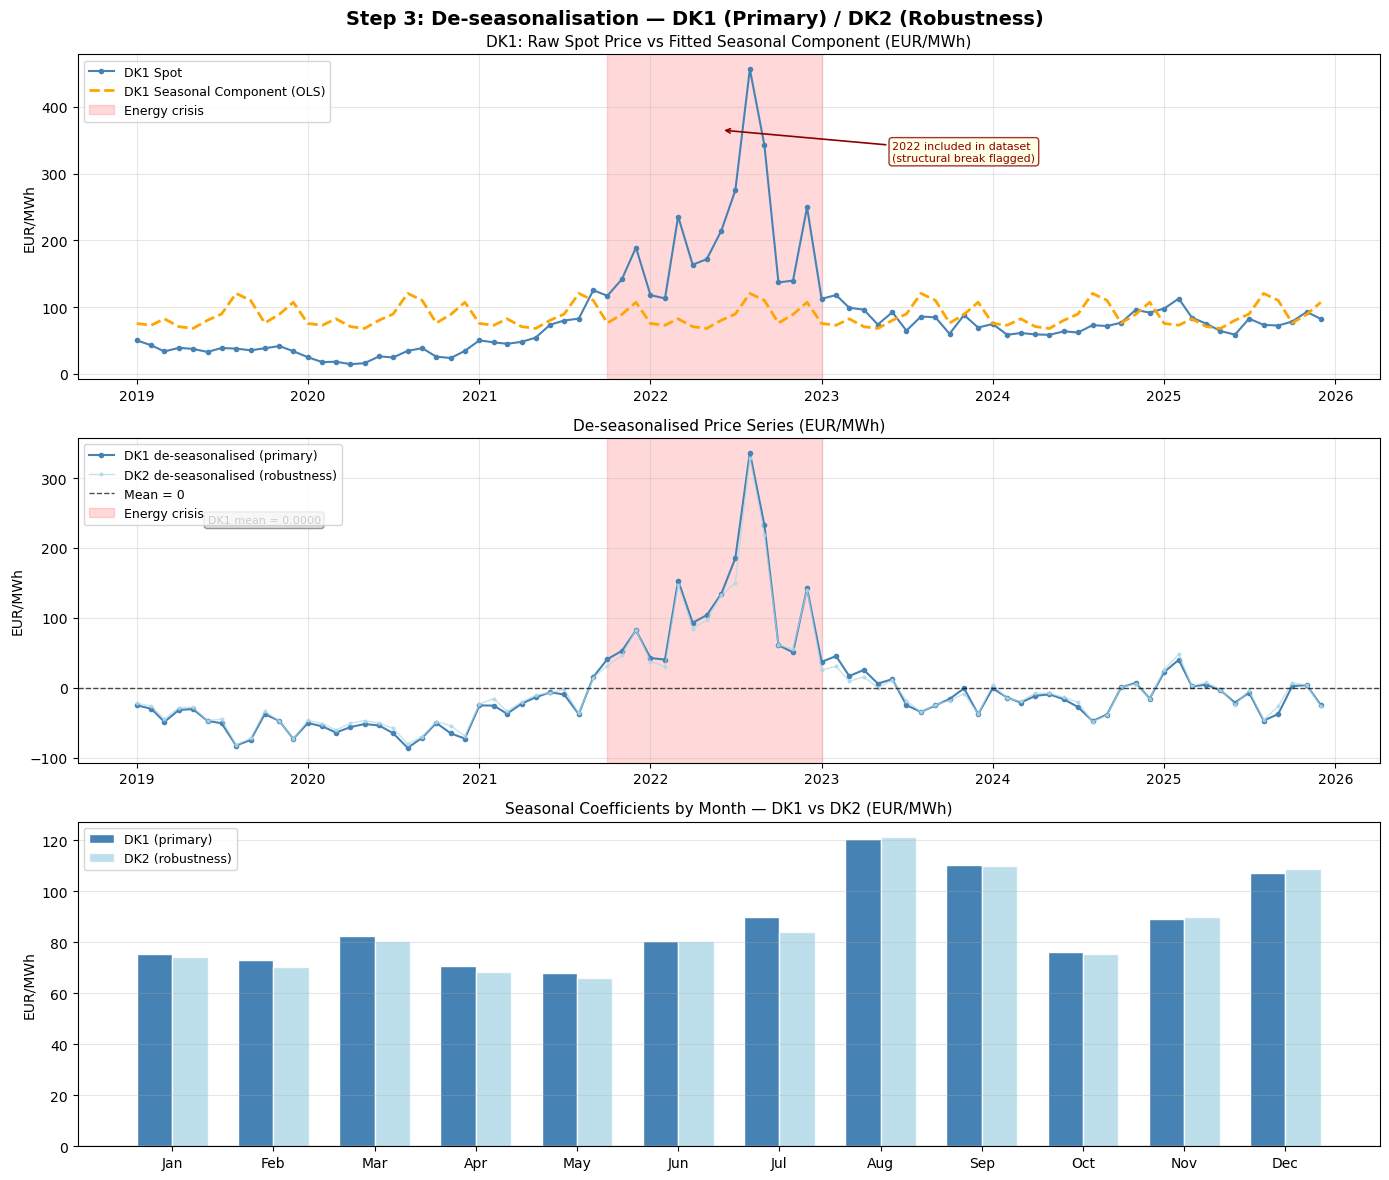

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step3_Deseasoning.png
Individual plots saved: Step3a, Step3b, Step3c
Electricity Price Data exported — 84 rows | DK1 primary | DK2 robustness


In [86]:
# ── STEP 3: DE-SEASONALISATION ─────────────────────────────────────────────
from openpyxl import load_workbook
from openpyxl.chart import LineChart, Reference
import calendar
from numpy.linalg import lstsq
monthly['month_num'] = monthly['month_dt'].dt.month
for m in range(1, 13):
    monthly[f'M{m}'] = (monthly['month_num'] == m).astype(int)
X = monthly[[f'M{m}' for m in range(1, 13)]].values
# ── DK1 primary ────────────────────────────────────────────────────────────
y_dk1 = monthly['DK1_Spot'].values
coeffs_dk1, _, _, _    = lstsq(X, y_dk1, rcond=None)
monthly['DK1_seasonal']   = X @ coeffs_dk1
monthly['DK1_deseasoned'] = monthly['DK1_Spot'] - monthly['DK1_seasonal']
# ── DK2 robustness ─────────────────────────────────────────────────────────
y_dk2 = monthly['DK2_Spot'].values
coeffs_dk2, _, _, _    = lstsq(X, y_dk2, rcond=None)
monthly['DK2_seasonal']   = X @ coeffs_dk2
monthly['DK2_deseasoned'] = monthly['DK2_Spot'] - monthly['DK2_seasonal']
print("=== SEASONAL COEFFICIENTS (EUR/MWh) ===")
print(f"{'Month':<6} {'DK1':>10} {'DK2':>10}")
print("-" * 28)
for m, (c1, c2) in enumerate(zip(coeffs_dk1, coeffs_dk2), 1):
    print(f"{calendar.month_abbr[m]:<6} {c1:>10.2f} {c2:>10.2f}")
print(f"\n=== DE-SEASONALISED SERIES ===")
print(f"  DK1 mean: {monthly['DK1_deseasoned'].mean():.4f} (should be ~0.000)")
print(f"  DK2 mean: {monthly['DK2_deseasoned'].mean():.4f} (should be ~0.000)")
print("\nDe-seasonalisation complete!")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Step 3: De-seasonalisation — DK1 (Primary) / DK2 (Robustness)',
             fontsize=14, fontweight='bold', y=0.98)
# ── Plot 1: DK1 raw vs seasonal fit ───────────────────────────────────────
ax1 = axes[0]
ax1.plot(monthly['month_dt'], monthly['DK1_Spot'], color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='DK1 Spot')
ax1.plot(monthly['month_dt'], monthly['DK1_seasonal'], color='orange',
         linewidth=2.0, linestyle='--', label='DK1 Seasonal Component (OLS)')
ax1.axvspan(datetime(2021,10,1), datetime(2023,1,1),
            alpha=0.15, color='red', label='Energy crisis')
ax1.annotate('2022 included in dataset\n(structural break flagged)',
             xy=(datetime(2022,6,1), monthly['DK1_Spot'].max()*0.8),
             xytext=(datetime(2023,6,1), monthly['DK1_Spot'].max()*0.7),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax1.set_title('DK1: Raw Spot Price vs Fitted Seasonal Component (EUR/MWh)',
              fontsize=11)
ax1.set_ylabel('EUR/MWh')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)
# ── Plot 2: DK1 de-seasonalised ────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(monthly['month_dt'], monthly['DK1_deseasoned'], color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='DK1 de-seasonalised (primary)')
ax2.plot(monthly['month_dt'], monthly['DK2_deseasoned'], color='lightblue',
         linewidth=1.0, marker='o', markersize=2, alpha=0.7,
         label='DK2 de-seasonalised (robustness)')
ax2.axhline(y=0, color='black', linewidth=1.0, linestyle='--', alpha=0.7,
            label='Mean = 0')
ax2.axvspan(datetime(2021,10,1), datetime(2023,1,1),
            alpha=0.15, color='red', label='Energy crisis')
ax2.annotate(f'DK1 mean = {monthly["DK1_deseasoned"].mean():.4f}',
             xy=(datetime(2019,6,1), 0),
             xytext=(datetime(2019,6,1), monthly['DK1_deseasoned'].max()*0.7),
             fontsize=8, color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey',
                       edgecolor='grey', alpha=0.8))
ax2.set_title('De-seasonalised Price Series (EUR/MWh)', fontsize=11)
ax2.set_ylabel('EUR/MWh')
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)
# ── Plot 3: Seasonal coefficients ─────────────────────────────────────────
ax3 = axes[2]
months_abbr = [calendar.month_abbr[m] for m in range(1, 13)]
x = np.arange(12)
width = 0.35
ax3.bar(x - width/2, coeffs_dk1, width, color='steelblue',
        label='DK1 (primary)', edgecolor='white')
ax3.bar(x + width/2, coeffs_dk2, width, color='lightblue',
        label='DK2 (robustness)', edgecolor='white', alpha=0.8)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_title('Seasonal Coefficients by Month — DK1 vs DK2 (EUR/MWh)', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(months_abbr)
ax3.set_ylabel('EUR/MWh')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step3_Deseasoning.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")
# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()
extent1 = ax1.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step3a_Raw_vs_Seasonal.png', dpi=300, bbox_inches=extent1)
extent2 = ax2.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step3b_Deseasoned_Series.png', dpi=300, bbox_inches=extent2)
extent3 = ax3.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step3c_Seasonal_Coefficients.png', dpi=300, bbox_inches=extent3)
print("Individual plots saved: Step3a, Step3b, Step3c")
# ── EXPORT — ELECTRICITY PRICE DATA SHEET ────────────────────────────────
clean_data = monthly[[
    'month_dt', 'DK1_Spot', 'DK2_Spot',
    'DK1_seasonal', 'DK1_deseasoned',
    'DK2_seasonal', 'DK2_deseasoned'
]].copy()
clean_data.columns = [
    'Month',
    'DK1 Spot Price (EUR/MWh) — Primary',
    'DK2 Spot Price (EUR/MWh) — Robustness',
    'DK1 Seasonal Component (EUR/MWh)',
    'DK1 De-seasonalised Price (EUR/MWh)',
    'DK2 Seasonal Component (EUR/MWh)',
    'DK2 De-seasonalised Price (EUR/MWh)'
]
clean_data['Month'] = clean_data['Month'].dt.strftime('%Y-%m')
wb = load_workbook(master_path)
ws = wb['Electricity Price Data']
ws.delete_rows(1, ws.max_row)
headers = clean_data.columns.tolist()
for col, header in enumerate(headers, 1):
    ws.cell(row=1, column=col, value=header)
for row_idx, row in enumerate(clean_data.itertuples(index=False), 2):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)
n_rows = len(clean_data) + 1
# Chart 1: DK1/DK2 spot prices
chart1 = LineChart()
chart1.title        = "Monthly Spot Prices - DK1 (Primary) and DK2 (Robustness)"
chart1.style        = 10
chart1.y_axis.title = "EUR/MWh"
chart1.x_axis.title = "Month"
chart1.width        = 20
chart1.height       = 12
for col, color in [(2, "2E75B6"), (3, "9DC3E6")]:
    data = Reference(ws, min_col=col, min_row=1, max_row=n_rows)
    chart1.add_data(data, titles_from_data=True)
    chart1.series[col-2].graphicalProperties.line.solidFill = color
ws.add_chart(chart1, "I2")
# Chart 2: DK1 de-seasonalised
chart2 = LineChart()
chart2.title        = "DK1 De-seasonalised Price Series (Primary)"
chart2.style        = 10
chart2.y_axis.title = "EUR/MWh"
chart2.x_axis.title = "Month"
chart2.width        = 20
chart2.height       = 12
data = Reference(ws, min_col=5, min_row=1, max_row=n_rows)
chart2.add_data(data, titles_from_data=True)
chart2.series[0].graphicalProperties.line.solidFill = "2E75B6"
ws.add_chart(chart2, "I24")
wb.save(master_path)
print(f"Electricity Price Data exported — {len(clean_data)} rows | DK1 primary | DK2 robustness")

## Step 4: Stationarity Testing: ADF Test

**Purpose**  
Tests whether the de-seasonalised price series contains a unit root and therefore whether the series is consistent with a stationary, mean-reverting stochastic process.

**Methodology**  
The Augmented Dickey-Fuller (ADF) test is applied to the de-seasonalised spot-price series.

**Hypotheses**
- H0: Unit root present -> non-stationary (random walk)
- H1: No unit root -> stationary (mean-reverting)

**Specifications**

- **Primary:** DK1 de-seasonalised spot price
- **Robustness:** DK2 de-seasonalised spot price

**Parameters / Inputs**
- De-seasonalised monthly spot-price series
- Three DK1 sub-samples:
  1. Full series (2019–2025) — includes the 2022 energy crisis
  2. Full series excluding 2022 — primary calibration sample (72 observations)
  3. Post-crisis (2023–2025) — robustness check (36 observations)
- DK2 tested as an additional robustness specification
- MacKinnon (1994) critical values:
  - 1% = -3.51
  - 5% = -2.89
  - 10% = -2.58

**Output**  
Reports ADF test statistics for the DK1 and DK2 specifications and identifies whether the primary calibration sample is sufficiently stationary to support OU calibration in Step 5.

Critical values: 1% = -3.51 | 5% = -2.89 | 10% = -2.58

=== ADF TEST: DK1 FULL SERIES (2019-2025) (n=84) ===
  Lags=0: t-stat = -2.7049 *   Reject H0 at 10% — STATIONARY
  Lags=1: t-stat = -2.5651     Fail to reject H0 — NON-STATIONARY
  Lags=2: t-stat = -1.7820     Fail to reject H0 — NON-STATIONARY
  Lags=3: t-stat = -1.6911     Fail to reject H0 — NON-STATIONARY
  Lags=4: t-stat = -1.6501     Fail to reject H0 — NON-STATIONARY

=== ADF TEST: DK1 FULL SERIES EX-2022 (primary calibration sample) (n=72) ===
  Lags=0: t-stat = -2.7732 *   Reject H0 at 10% — STATIONARY
  Lags=1: t-stat = -2.3519     Fail to reject H0 — NON-STATIONARY
  Lags=2: t-stat = -1.8495     Fail to reject H0 — NON-STATIONARY
  Lags=3: t-stat = -1.8987     Fail to reject H0 — NON-STATIONARY
  Lags=4: t-stat = -1.8872     Fail to reject H0 — NON-STATIONARY

=== ADF TEST: DK1 POST-CRISIS 2023-2025 (n=36) ===
  Lags=0: t-stat = -3.4350 **  Reject H0 at 5%  — STATIONARY
  Lags=1: t-stat = -3.4777 **  Reject H0 at 5%  —

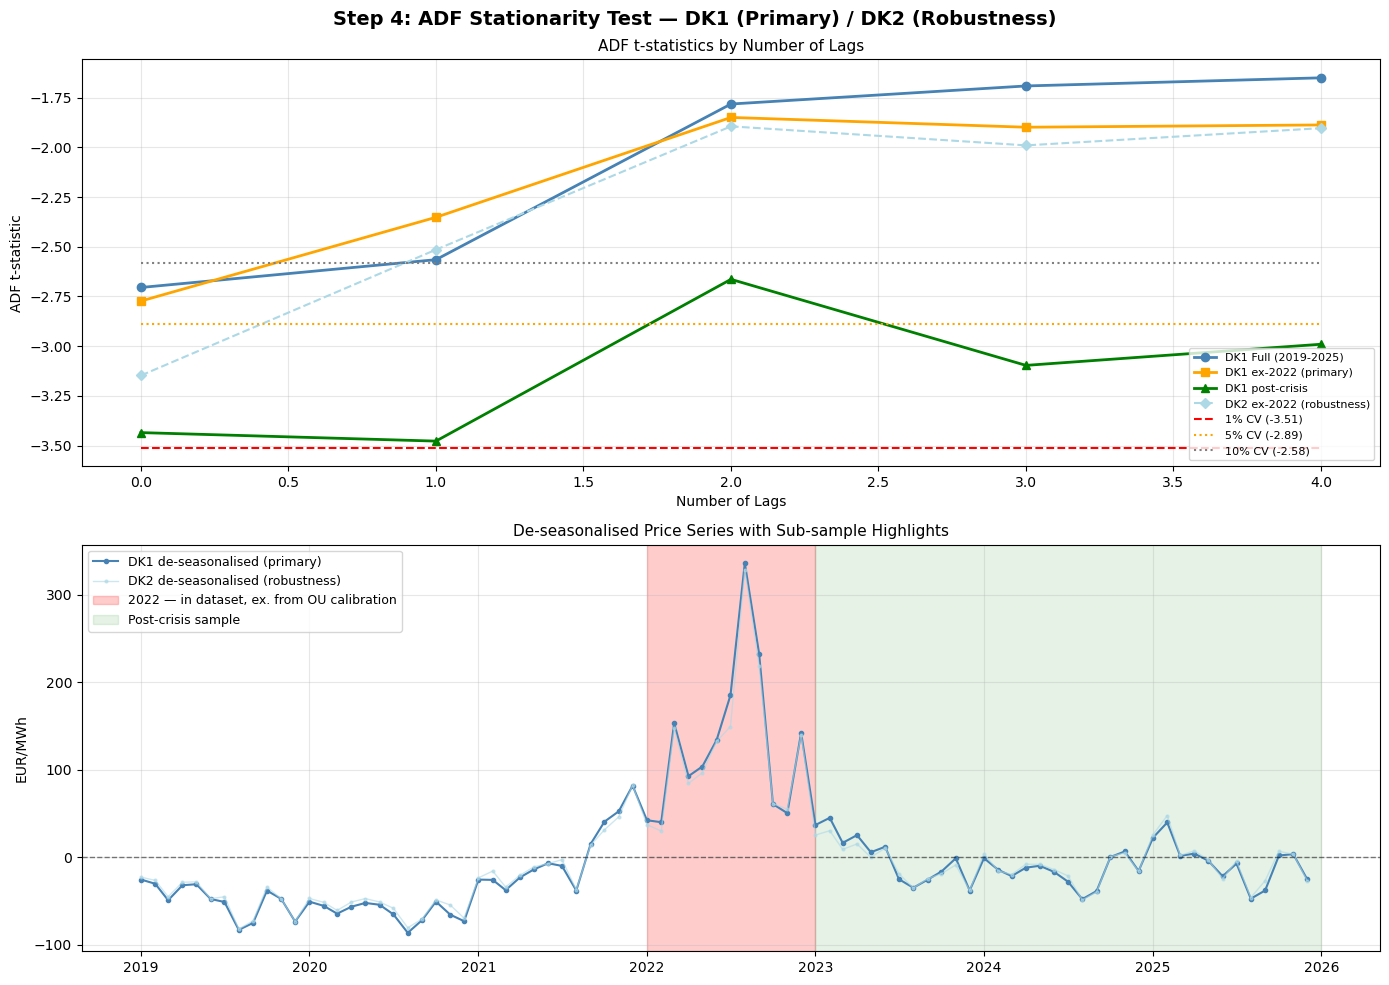

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step4_ADF_Test.png
Individual plots saved: Step4a, Step4b


In [101]:
# ── STEP 4: AUGMENTED DICKEY-FULLER TEST ──────────────────────────────────
from numpy.linalg import lstsq
def adf_test(series, label, max_lags=4):
    y  = np.array(series)
    dy = np.diff(y)
    n  = len(dy)
    cv = {1: -3.51, 5: -2.89, 10: -2.58}
    print(f"\n=== ADF TEST: {label} (n={len(y)}) ===")
    results = {}
    for lags in range(0, max_lags+1):
        T   = n - lags
        Y   = dy[lags:]
        X_c = [np.ones(T), y[lags:n]]
        for i in range(1, lags+1):
            X_c.append(dy[lags-i:n-i])
        X      = np.column_stack(X_c)
        b, _, _, _ = lstsq(X, Y, rcond=None)
        e      = Y - X @ b
        s2     = np.sum(e**2) / (T - X.shape[1])
        se     = np.sqrt(s2 * np.diag(np.linalg.inv(X.T @ X)))
        t_stat = b[1] / se[1]
        if t_stat < cv[1]:    sig = "*** Reject H0 at 1%  — STATIONARY"
        elif t_stat < cv[5]:  sig = "**  Reject H0 at 5%  — STATIONARY"
        elif t_stat < cv[10]: sig = "*   Reject H0 at 10% — STATIONARY"
        else:                 sig = "    Fail to reject H0 — NON-STATIONARY"
        results[lags] = t_stat
        print(f"  Lags={lags}: t-stat = {t_stat:.4f} {sig}")
    return results
print("Critical values: 1% = -3.51 | 5% = -2.89 | 10% = -2.58")
# ── DK1 PRIMARY ────────────────────────────────────────────────────────────
adf_dk1_full    = adf_test(monthly['DK1_deseasoned'],
                            'DK1 FULL SERIES (2019-2025)')
adf_dk1_ex2022  = adf_test(
    monthly[~monthly['month_dt'].dt.year.isin([2022])]['DK1_deseasoned'],
    'DK1 FULL SERIES EX-2022 (primary calibration sample)')
adf_dk1_post    = adf_test(
    monthly[monthly['month_dt'] >= '2023-01-01']['DK1_deseasoned'],
    'DK1 POST-CRISIS 2023-2025')
# ── DK2 ROBUSTNESS ─────────────────────────────────────────────────────────
adf_dk2_full    = adf_test(monthly['DK2_deseasoned'],
                            'DK2 FULL SERIES (2019-2025) — ROBUSTNESS')
adf_dk2_ex2022  = adf_test(
    monthly[~monthly['month_dt'].dt.year.isin([2022])]['DK2_deseasoned'],
    'DK2 FULL SERIES EX-2022 — ROBUSTNESS')
print("\n=== CONCLUSION ===")
print("  Primary: DK1 full series ex-2022 (72 obs) — used for OU calibration")
print("  Robustness: DK1 post-crisis + DK2 full series ex-2022")
print("  2022 retained in dataset — excluded only from OU calibration sample")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Step 4: ADF Stationarity Test — DK1 (Primary) / DK2 (Robustness)',
             fontsize=14, fontweight='bold', y=0.98)
lags_range = list(range(5))
cv_1  = [-3.51]*5
cv_5  = [-2.89]*5
cv_10 = [-2.58]*5
ax1 = axes[0]
ax1.plot(lags_range, list(adf_dk1_full.values()),   color='steelblue',
         linewidth=2, marker='o', markersize=6, label='DK1 Full (2019-2025)')
ax1.plot(lags_range, list(adf_dk1_ex2022.values()), color='orange',
         linewidth=2, marker='s', markersize=6, label='DK1 ex-2022 (primary)')
ax1.plot(lags_range, list(adf_dk1_post.values()),   color='green',
         linewidth=2, marker='^', markersize=6, label='DK1 post-crisis')
ax1.plot(lags_range, list(adf_dk2_ex2022.values()), color='lightblue',
         linewidth=1.5, marker='D', markersize=5, linestyle='--',
         label='DK2 ex-2022 (robustness)')
ax1.plot(lags_range, cv_1,  color='red',    linewidth=1.5,
         linestyle='--', label='1% CV (-3.51)')
ax1.plot(lags_range, cv_5,  color='orange', linewidth=1.5,
         linestyle=':', label='5% CV (-2.89)')
ax1.plot(lags_range, cv_10, color='grey',   linewidth=1.5,
         linestyle=':', label='10% CV (-2.58)')
ax1.set_title('ADF t-statistics by Number of Lags', fontsize=11)
ax1.set_xlabel('Number of Lags')
ax1.set_ylabel('ADF t-statistic')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax2 = axes[1]
ax2.plot(monthly['month_dt'], monthly['DK1_deseasoned'], color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='DK1 de-seasonalised (primary)')
ax2.plot(monthly['month_dt'], monthly['DK2_deseasoned'], color='lightblue',
         linewidth=1.0, marker='o', markersize=2, alpha=0.6,
         label='DK2 de-seasonalised (robustness)')
ax2.axhline(y=0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax2.axvspan(datetime(2022,1,1), datetime(2022,12,31),
            alpha=0.2, color='red', label='2022 — in dataset, ex. from OU calibration')
ax2.axvspan(datetime(2023,1,1), datetime(2025,12,31),
            alpha=0.1, color='green', label='Post-crisis sample')
ax2.set_title('De-seasonalised Price Series with Sub-sample Highlights', fontsize=11)
ax2.set_ylabel('EUR/MWh')
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step4_ADF_Test.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")

# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()

extent1 = ax1.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step4a_ADF_tstatistics.png', dpi=300, bbox_inches=extent1)

extent2 = ax2.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step4b_Deseasoned_Subsamples.png', dpi=300, bbox_inches=extent2)

print("Individual plots saved: Step4a, Step4b")

# PHASE 3: CALIBRATION

## Step 5: Ornstein-Uhlenbeck Parameter Calibration

**Purpose**  
Estimates the three parameters of the Ornstein-Uhlenbeck (OU) process used in the Monte Carlo simulation.

**Methodology**  
The continuous-time OU process is specified as:$$dS_t = \kappa(\mu - S_t)\,dt + \sigma\,dW_t$$

In discrete time, this becomes:

$$
S_{t+1} = \mu(1-e^{-\kappa}) + e^{-\kappa}S_t + \varepsilon_t,
\qquad
\varepsilon_t \sim N\!\left(0,\frac{\sigma^2}{2\kappa}(1-e^{-2\kappa})\right)
$$

The parameters are estimated by Ordinary Least Squares applied to the discrete-time AR(1) representation.

**Specifications**
- **Primary:** DK1 — Full series excluding 2022 (72 observations)
- **Robustness 1:** DK1 — Post-crisis 2023–2025 (36 observations)
- **Robustness 2:** DK1 — Full series including 2022 (84 observations)
- **Robustness 3:** DK2 — Full series excluding 2022 (72 observations)
- **Robustness 4:** DK2 — Post-crisis 2023–2025 (36 observations)
- **Robustness 5:** DK2 — Full series including 2022 (84 observations)

**Parameters / Inputs**
- μ: Long-run mean (equilibrium price level)
- κ: Speed of mean reversion (how fast prices return to μ)
- σ: Instantaneous volatility
- Monthly spot-price series from the selected calibration samples
- OLS applied to the AR(1) representation of the OU process

**Output**  
Produces `mu_final`, `kappa_final`, and `sigma_final` from the DK1 primary specification, which serve as inputs to the Monte Carlo simulation.

**Note**  
The year 2022 is identified as a structural break consistent with Knightian uncertainty following the Russian invasion of Ukraine. The primary calibration excludes 2022 in order to avoid contaminating long-run parameter estimates. Full-sample results including 2022 are reported as robustness checks in Robustness 2 and Robustness 5.


=== OU PARAMETERS — DK1 - FULL SERIES EX-2022 (72 obs) - PRIMARY ===
  Long-run mean (mu):          68.2947  (SE: 33.0993) EUR/MWh
  Speed of mean reversion (k): 0.1401  (SE: 0.0686) per month
  Volatility (sigma):          17.5069  (SE: 1.4691) EUR/MWh
  Half-life:                   4.95 months (0.41 years)

=== OU PARAMETERS — DK1 - POST-CRISIS 2023-2025 (36 obs) - ROBUSTNESS 1 ===
  Long-run mean (mu):          77.6851  (SE: 24.0452) EUR/MWh
  Speed of mean reversion (k): 0.5931  (SE: 0.2395) per month
  Volatility (sigma):          16.8150  (SE: 2.0098) EUR/MWh
  Half-life:                   1.17 months (0.10 years)

=== OU PARAMETERS — DK1 - FULL SERIES INCL. 2022 (84 obs) - ROBUSTNESS 2 ===
  Long-run mean (mu):          89.0256  (SE: 38.4645) EUR/MWh
  Speed of mean reversion (k): 0.2121  (SE: 0.0804) per month
  Volatility (sigma):          47.3788  (SE: 3.6773) EUR/MWh
  Half-life:                   3.27 months (0.27 years)

=== OU PARAMETERS — DK2 - FULL SERIES EX-2022 (72 o

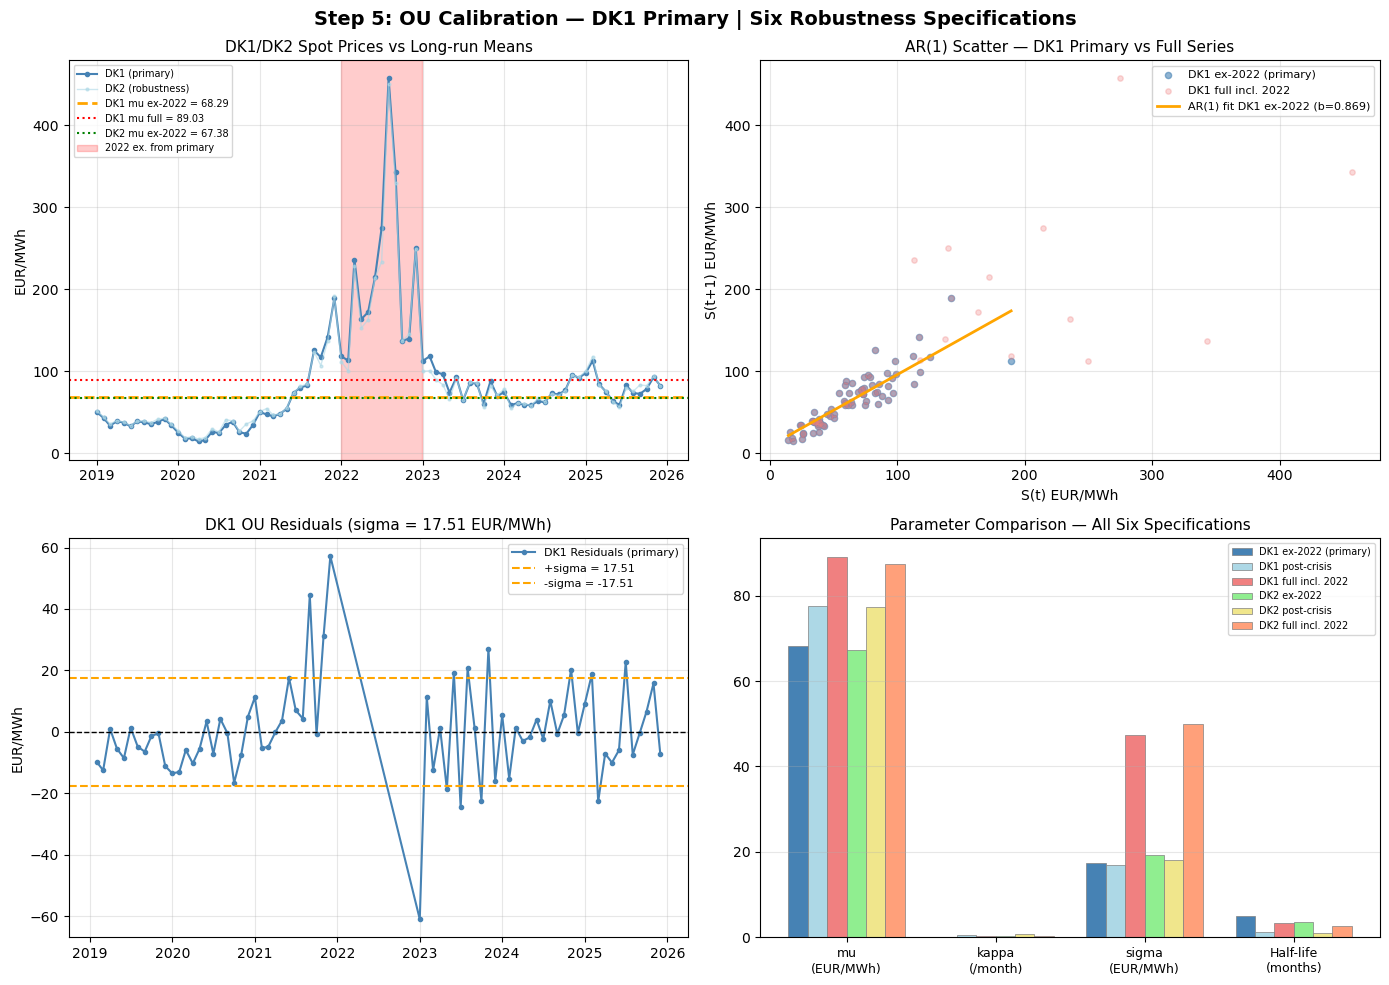

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step5_OU_Calibration.png
Individual plots saved: Step5a, Step5b, Step5c, Step5d


In [88]:
# ── STEP 5: OU PARAMETER CALIBRATION ──────────────────────────────────────
from numpy.linalg import lstsq
def calibrate_ou(series, label):
    S    = np.array(series)
    n    = len(S)
    y_r  = S[1:]
    x_r  = S[:-1]
    X_r  = np.column_stack([np.ones(n-1), x_r])
    b, _, _, _ = lstsq(X_r, y_r, rcond=None)
    a_hat, b_hat = b
    # ── Core parameters ────────────────────────────────────────────────────
    kappa = -np.log(b_hat)
    mu    = a_hat / (1 - b_hat)
    resid = y_r - (a_hat + b_hat * x_r)
    T     = len(resid)
    sigma = np.std(resid, ddof=2) * np.sqrt(2*kappa / (1 - np.exp(-2*kappa)))
    hl    = np.log(2) / kappa
    # ── Standard errors via OLS covariance matrix ──────────────────────────
    s2       = np.sum(resid**2) / (T - 2)
    cov_b    = s2 * np.linalg.inv(X_r.T @ X_r)
    se_a     = np.sqrt(cov_b[0, 0])
    se_b     = np.sqrt(cov_b[1, 1])
    se_mu    = se_a / (1 - b_hat)
    se_kappa = se_b / abs(b_hat)
    se_sigma = np.sqrt(s2 / (2 * T)) * np.sqrt(2*kappa / (1 - np.exp(-2*kappa)))
    print(f"\n=== OU PARAMETERS — {label} ===")
    print(f"  Long-run mean (mu):          {mu:.4f}  (SE: {se_mu:.4f}) EUR/MWh")
    print(f"  Speed of mean reversion (k): {kappa:.4f}  (SE: {se_kappa:.4f}) per month")
    print(f"  Volatility (sigma):          {sigma:.4f}  (SE: {se_sigma:.4f}) EUR/MWh")
    print(f"  Half-life:                   {hl:.2f} months ({hl/12:.2f} years)")
    return mu, kappa, sigma, hl, se_mu, se_kappa, se_sigma
ex2022 = ~monthly['month_dt'].dt.year.isin([2022])
post   =  monthly['month_dt'] >= '2023-01-01'
full   =  monthly['month_dt'].notna()
# ── PRIMARY: DK1 ex-2022 ──────────────────────────────────────────────────
mu_final, kappa_final, sigma_final, hl_final, \
se_mu_final, se_kappa_final, se_sigma_final = calibrate_ou(
    monthly[ex2022]['DK1_Spot'],
    'DK1 - FULL SERIES EX-2022 (72 obs) - PRIMARY')
# ── ROBUSTNESS 1: DK1 post-crisis ─────────────────────────────────────────
mu_dk1r, kappa_dk1r, sigma_dk1r, hl_dk1r, \
se_mu_dk1r, se_kappa_dk1r, se_sigma_dk1r = calibrate_ou(
    monthly[post]['DK1_Spot'],
    'DK1 - POST-CRISIS 2023-2025 (36 obs) - ROBUSTNESS 1')
# ── ROBUSTNESS 2: DK1 full series inkl. 2022 ──────────────────────────────
mu_dk1_full, kappa_dk1_full, sigma_dk1_full, hl_dk1_full, \
se_mu_dk1_full, se_kappa_dk1_full, se_sigma_dk1_full = calibrate_ou(
    monthly[full]['DK1_Spot'],
    'DK1 - FULL SERIES INCL. 2022 (84 obs) - ROBUSTNESS 2')
# ── ROBUSTNESS 3: DK2 ex-2022 ─────────────────────────────────────────────
mu_dk2, kappa_dk2, sigma_dk2, hl_dk2, \
se_mu_dk2, se_kappa_dk2, se_sigma_dk2 = calibrate_ou(
    monthly[ex2022]['DK2_Spot'],
    'DK2 - FULL SERIES EX-2022 (72 obs) - ROBUSTNESS 3')
# ── ROBUSTNESS 4: DK2 post-crisis ─────────────────────────────────────────
mu_dk2r, kappa_dk2r, sigma_dk2r, hl_dk2r, \
se_mu_dk2r, se_kappa_dk2r, se_sigma_dk2r = calibrate_ou(
    monthly[post]['DK2_Spot'],
    'DK2 - POST-CRISIS 2023-2025 (36 obs) - ROBUSTNESS 4')
# ── ROBUSTNESS 5: DK2 full series inkl. 2022 ──────────────────────────────
mu_dk2_full, kappa_dk2_full, sigma_dk2_full, hl_dk2_full, \
se_mu_dk2_full, se_kappa_dk2_full, se_sigma_dk2_full = calibrate_ou(
    monthly[full]['DK2_Spot'],
    'DK2 - FULL SERIES INCL. 2022 (84 obs) - ROBUSTNESS 5')
# ── COMPARISON TABLE ───────────────────────────────────────────────────────
print(f"\n=== PARAMETER COMPARISON TABLE ===")
print(f"  {'Parameter':<22} {'DK1 ex-22':>10} {'DK1 post':>10} "
      f"{'DK1 full':>10} {'DK2 ex-22':>10} {'DK2 post':>10} {'DK2 full':>10}")
print("-" * 105)
for param, v1, v2, v3, v4, v5, v6 in [
    ("mu (EUR/MWh)",      mu_final,    mu_dk1r,    mu_dk1_full,
                          mu_dk2,      mu_dk2r,    mu_dk2_full),
    ("SE(mu)",            se_mu_final, se_mu_dk1r, se_mu_dk1_full,
                          se_mu_dk2,   se_mu_dk2r, se_mu_dk2_full),
    ("kappa (per month)", kappa_final, kappa_dk1r, kappa_dk1_full,
                          kappa_dk2,   kappa_dk2r, kappa_dk2_full),
    ("SE(kappa)",         se_kappa_final, se_kappa_dk1r, se_kappa_dk1_full,
                          se_kappa_dk2,   se_kappa_dk2r, se_kappa_dk2_full),
    ("sigma (EUR/MWh)",   sigma_final, sigma_dk1r, sigma_dk1_full,
                          sigma_dk2,   sigma_dk2r, sigma_dk2_full),
    ("SE(sigma)",         se_sigma_final, se_sigma_dk1r, se_sigma_dk1_full,
                          se_sigma_dk2,   se_sigma_dk2r, se_sigma_dk2_full),
    ("Half-life (mths)",  hl_final,    hl_dk1r,    hl_dk1_full,
                          hl_dk2,      hl_dk2r,    hl_dk2_full),
]:
    print(f"  {param:<22} {v1:>10.4f} {v2:>10.4f} {v3:>10.4f} "
          f"{v4:>10.4f} {v5:>10.4f} {v6:>10.4f}")
print(f"\n=== SELECTED PARAMETERS FOR MONTE CARLO SIMULATION ===")
print(f"  Primary specification: DK1 - Full series ex-2022")
print(f"  mu        = {mu_final:.4f}  (SE: {se_mu_final:.4f}) EUR/MWh")
print(f"  kappa     = {kappa_final:.4f}  (SE: {se_kappa_final:.4f}) per month")
print(f"  sigma     = {sigma_final:.4f}  (SE: {se_sigma_final:.4f}) EUR/MWh")
print(f"  Half-life = {np.log(2)/kappa_final:.2f} months")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Step 5: OU Calibration — DK1 Primary | Six Robustness Specifications',
             fontsize=14, fontweight='bold', y=0.98)
# Plot 1: Price series with long-run means
ax1 = axes[0, 0]
ax1.plot(monthly['month_dt'], monthly['DK1_Spot'], color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='DK1 (primary)')
ax1.plot(monthly['month_dt'], monthly['DK2_Spot'], color='lightblue',
         linewidth=1.0, marker='o', markersize=2, alpha=0.6,
         label='DK2 (robustness)')
ax1.axhline(y=mu_final, color='orange', linewidth=2.0, linestyle='--',
            label=f'DK1 mu ex-2022 = {mu_final:.2f}')
ax1.axhline(y=mu_dk1_full, color='red', linewidth=1.5, linestyle=':',
            label=f'DK1 mu full = {mu_dk1_full:.2f}')
ax1.axhline(y=mu_dk2, color='green', linewidth=1.5, linestyle=':',
            label=f'DK2 mu ex-2022 = {mu_dk2:.2f}')
ax1.axvspan(datetime(2022,1,1), datetime(2022,12,31),
            alpha=0.2, color='red', label='2022 ex. from primary')
ax1.set_title('DK1/DK2 Spot Prices vs Long-run Means', fontsize=11)
ax1.set_ylabel('EUR/MWh')
ax1.legend(loc='upper left', fontsize=7)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)
# Plot 2: AR(1) scatter DK1 primary vs full
ax2 = axes[0, 1]
S_primary = monthly[ex2022]['DK1_Spot'].values
S_full    = monthly[full]['DK1_Spot'].values
ax2.scatter(S_primary[:-1], S_primary[1:], color='steelblue',
            alpha=0.6, s=20, label='DK1 ex-2022 (primary)')
ax2.scatter(S_full[:-1], S_full[1:], color='lightcoral',
            alpha=0.3, s=15, label='DK1 full incl. 2022')
x_line = np.linspace(S_primary.min(), S_primary.max(), 100)
b_hat  = np.exp(-kappa_final)
a_hat  = mu_final * (1 - b_hat)
ax2.plot(x_line, a_hat + b_hat * x_line, color='orange',
         linewidth=2.0, label=f'AR(1) fit DK1 ex-2022 (b={b_hat:.3f})')
ax2.set_title('AR(1) Scatter — DK1 Primary vs Full Series', fontsize=11)
ax2.set_xlabel('S(t) EUR/MWh')
ax2.set_ylabel('S(t+1) EUR/MWh')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
# Plot 3: Residuals DK1 primary
ax3 = axes[1, 0]
resid = S_primary[1:] - (a_hat + b_hat * S_primary[:-1])
ax3.plot(monthly[ex2022]['month_dt'].values[1:], resid, color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='DK1 Residuals (primary)')
ax3.axhline(y=0, color='black', linewidth=1.0, linestyle='--')
ax3.axhline(y=sigma_final, color='orange', linewidth=1.5, linestyle='--',
            label=f'+sigma = {sigma_final:.2f}')
ax3.axhline(y=-sigma_final, color='orange', linewidth=1.5, linestyle='--',
            label=f'-sigma = {-sigma_final:.2f}')
ax3.set_title(f'DK1 OU Residuals (sigma = {sigma_final:.2f} EUR/MWh)', fontsize=11)
ax3.set_ylabel('EUR/MWh')
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(True, alpha=0.3)
# Plot 4: Parameter comparison — alle seks specifikationer
ax4 = axes[1, 1]
params   = ['mu\n(EUR/MWh)', 'kappa\n(/month)', 'sigma\n(EUR/MWh)', 'Half-life\n(months)']
vals_all = [
    ([mu_final,    kappa_final,    sigma_final,    hl_final],    'DK1 ex-2022 (primary)', 'steelblue'),
    ([mu_dk1r,     kappa_dk1r,     sigma_dk1r,     hl_dk1r],     'DK1 post-crisis',       'lightblue'),
    ([mu_dk1_full, kappa_dk1_full, sigma_dk1_full, hl_dk1_full], 'DK1 full incl. 2022',   'lightcoral'),
    ([mu_dk2,      kappa_dk2,      sigma_dk2,      hl_dk2],      'DK2 ex-2022',           'lightgreen'),
    ([mu_dk2r,     kappa_dk2r,     sigma_dk2r,     hl_dk2r],     'DK2 post-crisis',       'khaki'),
    ([mu_dk2_full, kappa_dk2_full, sigma_dk2_full, hl_dk2_full], 'DK2 full incl. 2022',   'lightsalmon'),
]
x     = np.arange(len(params))
width = 0.13
for i, (vals, lbl, color) in enumerate(vals_all):
    ax4.bar(x + i*width - 2.5*width, vals, width,
            color=color, label=lbl, edgecolor='grey', linewidth=0.5)
ax4.set_title('Parameter Comparison — All Six Specifications', fontsize=11)
ax4.set_xticks(x)
ax4.set_xticklabels(params, fontsize=9)
ax4.legend(fontsize=7, loc='upper right')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step5_OU_Calibration.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")

# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()

extent1 = axes[0,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step5a_Spot_vs_LongrunMeans.png', dpi=300, bbox_inches=extent1)

extent2 = axes[0,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step5b_AR1_Scatter.png', dpi=300, bbox_inches=extent2)

extent3 = axes[1,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step5c_OU_Residuals.png', dpi=300, bbox_inches=extent3)

extent4 = axes[1,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step5d_Parameter_Comparison.png', dpi=300, bbox_inches=extent4)

print("Individual plots saved: Step5a, Step5b, Step5c, Step5d")

## Step 6: Cannibalisation Regression

**Purpose**  
Estimates the empirical relationship between solar penetration and the capture-price ratio (CPR) using OLS, thereby providing the empirical basis for the forward α(t) schedule.

**Methodology**  
The cannibalisation regression is specified as:

$$
CPR_t = \beta_0 + \beta_1 \cdot Penetration_t + \varepsilon_t
$$

where:

- CPR_t = Capture Price / Spot Price
- Penetration_t = Solar MWh / Gross Consumption MWh
- β₁ < 0 is expected, implying that higher solar penetration reduces the capture-price ratio

**Specifications**

- **Primary:** DK1
- **Robustness:** DK2

**Parameters / Inputs**
- Monthly capture-price ratio (CPR)
- Monthly solar-penetration proxy
- Sample starts in January 2020
- Only months with non-zero solar production are included

**Output**  
Produces the regression coefficients β₀ and β₁ for DK1 as the primary specification, the corresponding DK2 regression as a robustness check, and the forward α(t) schedule used in the Monte Carlo simulation.

**Note**  
Winter months with zero solar production are excluded because the capture-price ratio is undefined when solar generation is zero.

DK1 regression sample: 72 monthly observations
Period: 2020-01-01 to 2025-12-01
(Winter months with zero solar production excluded)

=== REGRESSION RESULTS — DK1 PRIMARY ===
  Intercept (b0):  1.0513
  Slope (b1):      -2.0262  <- expected negative sign
  R-squared:       0.6658
  p-value (b1):    0.0000
  Std error:       0.1716
  Sign check: PASS - negative slope confirms cannibalisation effect

=== REGRESSION RESULTS — DK2 ROBUSTNESS ===
  Intercept (b0):  1.0930
  Slope (b1):      -4.3648
  R-squared:       0.6409
  p-value (b1):    0.0000

=== ROBUSTNESS COMPARISON: DK1 vs DK2 ===
  Parameter               DK1 (primary)   DK2 (robustness)
--------------------------------------------------------
  Intercept (b0)                 1.0513             1.0930
  Slope (b1)                    -2.0262            -4.3648
  R-squared                      0.6658             0.6409
  p-value                        0.0000             0.0000

=== FORWARD ALPHA(t) SCHEDULE — DK1 PRIMARY ===
  Curr

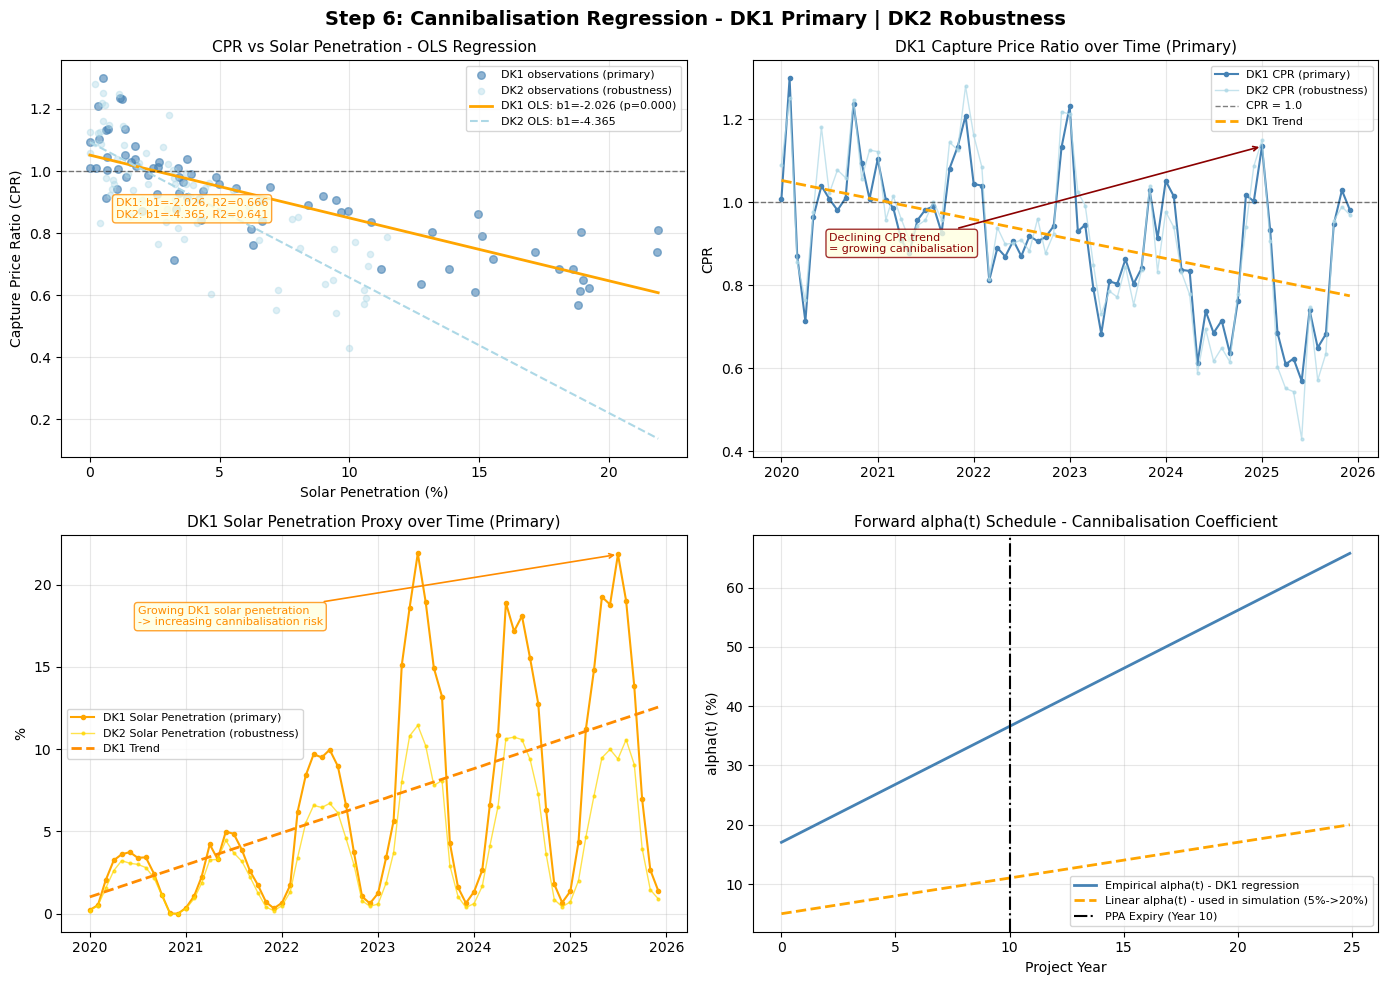

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step6_Cannibalisation_Regression.png
Calibration sheet exported | DK1 primary | DK2 robustness throughout


In [89]:
# ── STEP 6: CANNIBALISATION REGRESSION ────────────────────────────────────
from scipy import stats
# ── PRIMARY: DK1 regression sample ────────────────────────────────────────
reg_dk1 = monthly[
    monthly['DK1_CPR'].notna() &
    monthly['DK1_Penetration'].notna() &
    (monthly['DK1_Penetration'] > 0)].copy()
print(f"DK1 regression sample: {len(reg_dk1)} monthly observations")
print(f"Period: {reg_dk1['month_dt'].min().date()} to {reg_dk1['month_dt'].max().date()}")
print("(Winter months with zero solar production excluded)")
# ── OLS: DK1 CPR = b0 + b1 * DK1_Penetration ─────────────────────────────
X_dk1 = reg_dk1['DK1_Penetration'].values
Y_dk1 = reg_dk1['DK1_CPR'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(X_dk1, Y_dk1)
print(f"\n=== REGRESSION RESULTS — DK1 PRIMARY ===")
print(f"  Intercept (b0):  {intercept:.4f}")
print(f"  Slope (b1):      {slope:.4f}  <- expected negative sign")
print(f"  R-squared:       {r_value**2:.4f}")
print(f"  p-value (b1):    {p_value:.4f}")
print(f"  Std error:       {std_err:.4f}")
if slope < 0:
    print(f"  Sign check: PASS - negative slope confirms cannibalisation effect")
else:
    print(f"  Sign check: FAIL - positive slope, investigate data")
# ── ROBUSTNESS: DK2 regression ────────────────────────────────────────────
reg_dk2 = monthly[
    monthly['DK2_CPR'].notna() &
    monthly['DK2_Penetration'].notna() &
    (monthly['DK2_Penetration'] > 0)].copy()
slope_dk2, intercept_dk2, r_dk2, p_dk2, se_dk2 = stats.linregress(
    reg_dk2['DK2_Penetration'].values,
    reg_dk2['DK2_CPR'].values)
print(f"\n=== REGRESSION RESULTS — DK2 ROBUSTNESS ===")
print(f"  Intercept (b0):  {intercept_dk2:.4f}")
print(f"  Slope (b1):      {slope_dk2:.4f}")
print(f"  R-squared:       {r_dk2**2:.4f}")
print(f"  p-value (b1):    {p_dk2:.4f}")
# ── ROBUSTNESS COMPARISON ──────────────────────────────────────────────────
print(f"\n=== ROBUSTNESS COMPARISON: DK1 vs DK2 ===")
print(f"  {'Parameter':<20} {'DK1 (primary)':>16} {'DK2 (robustness)':>18}")
print("-" * 56)
for param, v1, v2 in [
    ("Intercept (b0)", intercept,    intercept_dk2),
    ("Slope (b1)",     slope,        slope_dk2),
    ("R-squared",      r_value**2,   r_dk2**2),
    ("p-value",        p_value,      p_dk2),
]:
    print(f"  {param:<20} {v1:>16.4f} {v2:>18.4f}")
# ── FORWARD ALPHA(T) SCHEDULE ──────────────────────────────────────────────
penetration_forward = np.linspace(
    reg_dk1['DK1_Penetration'].iloc[-6:].mean(),
    0.35, N_MONTHS)
cpr_forward     = intercept + slope * penetration_forward
alpha_empirical = np.clip(1 - cpr_forward, 0, 1)
alpha_linear    = np.linspace(0.05, 0.20, N_MONTHS)
print(f"\n=== FORWARD ALPHA(t) SCHEDULE — DK1 PRIMARY ===")
print(f"  Current DK1 penetration (avg last 6 months): "
      f"{reg_dk1['DK1_Penetration'].iloc[-6:].mean():.1%}")
print(f"  Projected penetration at Year 25: 35.0%")
print(f"  Empirical alpha(t=0):  {alpha_empirical[0]:.1%}")
print(f"  Empirical alpha(t=25): {alpha_empirical[-1]:.1%}")
print(f"  Linear alpha used in simulation: 5% -> 20%")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Step 6: Cannibalisation Regression - DK1 Primary | DK2 Robustness',
             fontsize=14, fontweight='bold', y=0.98)
# Plot 1: DK1 scatter with regression line
ax1 = axes[0, 0]
ax1.scatter(reg_dk1['DK1_Penetration']*100, reg_dk1['DK1_CPR'],
            color='steelblue', alpha=0.6, s=30, label='DK1 observations (primary)')
ax1.scatter(reg_dk2['DK2_Penetration']*100, reg_dk2['DK2_CPR'],
            color='lightblue', alpha=0.4, s=20, label='DK2 observations (robustness)')
x_line = np.linspace(reg_dk1['DK1_Penetration'].min(),
                      reg_dk1['DK1_Penetration'].max(), 100)
y_line_dk1 = intercept + slope * x_line
y_line_dk2 = intercept_dk2 + slope_dk2 * x_line
ax1.plot(x_line*100, y_line_dk1, color='orange', linewidth=2.0,
         label=f'DK1 OLS: b1={slope:.3f} (p={p_value:.3f})')
ax1.plot(x_line*100, y_line_dk2, color='lightblue', linewidth=1.5,
         linestyle='--', label=f'DK2 OLS: b1={slope_dk2:.3f}')
ax1.axhline(y=1.0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax1.annotate(f'DK1: b1={slope:.3f}, R2={r_value**2:.3f}\n'
             f'DK2: b1={slope_dk2:.3f}, R2={r_dk2**2:.3f}',
             xy=(reg_dk1['DK1_Penetration'].mean()*100,
                 intercept + slope*reg_dk1['DK1_Penetration'].mean()),
             xytext=(reg_dk1['DK1_Penetration'].min()*100+1, 0.85),
             fontsize=8, color='darkorange',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkorange', alpha=0.8))
ax1.set_title('CPR vs Solar Penetration - OLS Regression', fontsize=11)
ax1.set_xlabel('Solar Penetration (%)')
ax1.set_ylabel('Capture Price Ratio (CPR)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
# Plot 2: DK1 CPR over time
ax2 = axes[0, 1]
ax2.plot(reg_dk1['month_dt'], reg_dk1['DK1_CPR'],
         color='steelblue', linewidth=1.5, marker='o', markersize=3,
         label='DK1 CPR (primary)')
ax2.plot(reg_dk2['month_dt'], reg_dk2['DK2_CPR'],
         color='lightblue', linewidth=1.0, marker='o', markersize=2,
         alpha=0.7, label='DK2 CPR (robustness)')
ax2.axhline(y=1.0, color='black', linewidth=1.0, linestyle='--',
            alpha=0.5, label='CPR = 1.0')
z = np.polyfit(range(len(reg_dk1)), reg_dk1['DK1_CPR'], 1)
p = np.poly1d(z)
ax2.plot(reg_dk1['month_dt'], p(range(len(reg_dk1))),
         color='orange', linewidth=2.0, linestyle='--', label='DK1 Trend')
ax2.annotate('Declining CPR trend\n= growing cannibalisation',
             xy=(reg_dk1['month_dt'].iloc[-12], reg_dk1['DK1_CPR'].iloc[-12]),
             xytext=(reg_dk1['month_dt'].iloc[6], 0.88),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax2.set_title('DK1 Capture Price Ratio over Time (Primary)', fontsize=11)
ax2.set_ylabel('CPR')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)
# Plot 3: DK1 solar penetration over time
ax3 = axes[1, 0]
ax3.plot(reg_dk1['month_dt'], reg_dk1['DK1_Penetration']*100,
         color='orange', linewidth=1.5, marker='o', markersize=3,
         label='DK1 Solar Penetration (primary)')
ax3.plot(reg_dk2['month_dt'], reg_dk2['DK2_Penetration']*100,
         color='gold', linewidth=1.0, marker='o', markersize=2,
         alpha=0.7, label='DK2 Solar Penetration (robustness)')
z2 = np.polyfit(range(len(reg_dk1)), reg_dk1['DK1_Penetration']*100, 1)
p2 = np.poly1d(z2)
ax3.plot(reg_dk1['month_dt'], p2(range(len(reg_dk1))),
         color='darkorange', linewidth=2.0, linestyle='--', label='DK1 Trend')
ax3.annotate('Growing DK1 solar penetration\n-> increasing cannibalisation risk',
             xy=(reg_dk1['month_dt'].iloc[-6],
                 reg_dk1['DK1_Penetration'].iloc[-6]*100),
             xytext=(reg_dk1['month_dt'].iloc[6],
                     reg_dk1['DK1_Penetration'].max()*80),
             fontsize=8, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkorange', alpha=0.8))
ax3.set_title('DK1 Solar Penetration Proxy over Time (Primary)', fontsize=11)
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(True, alpha=0.3)
# Plot 4: Forward alpha(t) schedule
ax4 = axes[1, 1]
time_years_plot = np.arange(N_MONTHS) / 12
ax4.plot(time_years_plot, alpha_empirical*100, color='steelblue', linewidth=2.0,
         label='Empirical alpha(t) - DK1 regression')
ax4.plot(time_years_plot, alpha_linear*100,    color='orange',    linewidth=2.0,
         linestyle='--', label='Linear alpha(t) - used in simulation (5%->20%)')
ax4.axvline(x=10, color='black', linewidth=1.5, linestyle='-.',
            label='PPA Expiry (Year 10)')
ax4.set_title('Forward alpha(t) Schedule - Cannibalisation Coefficient', fontsize=11)
ax4.set_xlabel('Project Year')
ax4.set_ylabel('alpha(t) (%)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
output_path = base + '/4. Outputs/Step6_Cannibalisation_Regression.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")
# ── EXPORT — CALIBRATION SHEET ────────────────────────────────────────────
from openpyxl import load_workbook
from openpyxl.chart import LineChart, BarChart, Reference
import calendar
wb = load_workbook(master_path)
ws = wb['Calibration']
ws.delete_rows(1, ws.max_row)
sections = [
    [
        ['ADF TEST RESULTS — DK1 PRIMARY', '', '', '', ''],
        ['Sample', 'Lags=0', 'Lags=1', 'Lags=2', 'Conclusion'],
        ['DK1 Full (2019-2025)',
         round(list(adf_dk1_full.values())[0], 4),
         round(list(adf_dk1_full.values())[1], 4),
         round(list(adf_dk1_full.values())[2], 4),
         'Weakly stationary'],
        ['DK1 Full ex-2022 (primary)',
         round(list(adf_dk1_ex2022.values())[0], 4),
         round(list(adf_dk1_ex2022.values())[1], 4),
         round(list(adf_dk1_ex2022.values())[2], 4),
         'Stationary at 5%'],
        ['DK1 Post-crisis 2023-2025',
         round(list(adf_dk1_post.values())[0], 4),
         round(list(adf_dk1_post.values())[1], 4),
         round(list(adf_dk1_post.values())[2], 4),
         'Stationary at 1%'],
        ['DK2 Full ex-2022 (robustness)',
         round(list(adf_dk2_ex2022.values())[0], 4),
         round(list(adf_dk2_ex2022.values())[1], 4),
         round(list(adf_dk2_ex2022.values())[2], 4),
         'Robustness'],
        ['Critical values: 1% = -3.51', '5% = -2.89', '10% = -2.58', '', ''],
        ['', '', '', '', ''],
    ],
    [
        ['OU PARAMETER ESTIMATES', '', '', '', ''],
        ['Parameter', 'DK1 ex-2022 (primary)', 'DK1 post-crisis',
         'DK2 ex-2022', 'DK2 post-crisis'],
        ['Long-run mean (mu) EUR/MWh',
         round(mu_final,4), round(mu_dk1r,4), round(mu_dk2,4), round(mu_dk2r,4)],
        ['Mean reversion (kappa) /month',
         round(kappa_final,4), round(kappa_dk1r,4), round(kappa_dk2,4), round(kappa_dk2r,4)],
        ['Volatility (sigma) EUR/MWh',
         round(sigma_final,4), round(sigma_dk1r,4), round(sigma_dk2,4), round(sigma_dk2r,4)],
        ['Half-life (months)',
         round(np.log(2)/kappa_final,2), round(np.log(2)/kappa_dk1r,2),
         round(np.log(2)/kappa_dk2,2),   round(np.log(2)/kappa_dk2r,2)],
        ['Observations', 72, 36, 72, 36],
        ['', '', '', '', ''],
    ],
    [
        ['SEASONAL COEFFICIENTS (OLS) — DK1 PRIMARY vs DK2 ROBUSTNESS', '', '', ''],
        ['Month', 'DK1 Coefficient (EUR/MWh)', 'DK2 Coefficient (EUR/MWh)', ''],
    ] + [[calendar.month_abbr[m],
          round(float(coeffs_dk1[m-1]), 2),
          round(float(coeffs_dk2[m-1]), 2), '']
         for m in range(1, 13)] + [['', '', '', '']],
    [
        ['CANNIBALISATION REGRESSION', '', '', ''],
        ['Parameter', 'DK1 (primary)', 'DK2 (robustness)', ''],
        ['Intercept (b0)',  round(intercept,4),     round(intercept_dk2,4), ''],
        ['Slope (b1)',      round(slope,4),          round(slope_dk2,4),     ''],
        ['R-squared',       round(r_value**2,4),     round(r_dk2**2,4),      ''],
        ['p-value (b1)',    round(p_value,4),         round(p_dk2,4),         ''],
        ['Sign check',      'PASS' if slope < 0 else 'FAIL',
                            'PASS' if slope_dk2 < 0 else 'FAIL',           ''],
        ['Observations',    len(reg_dk1),            len(reg_dk2),           ''],
    ],
]
current_row = 1
for section in sections:
    for row_data in section:
        for col_idx, value in enumerate(row_data, 1):
            ws.cell(row=current_row, column=col_idx, value=value)
        current_row += 1
    current_row += 1
# Chart: ADF t-statistics
chart_col = 7
ws.cell(row=1, column=chart_col,   value='Lags')
ws.cell(row=1, column=chart_col+1, value='DK1 Full')
ws.cell(row=1, column=chart_col+2, value='DK1 ex-2022')
ws.cell(row=1, column=chart_col+3, value='DK1 post-crisis')
ws.cell(row=1, column=chart_col+4, value='CV 5%')
for i in range(5):
    ws.cell(row=i+2, column=chart_col,   value=i)
    ws.cell(row=i+2, column=chart_col+1, value=round(list(adf_dk1_full.values())[i],4))
    ws.cell(row=i+2, column=chart_col+2, value=round(list(adf_dk1_ex2022.values())[i],4))
    ws.cell(row=i+2, column=chart_col+3, value=round(list(adf_dk1_post.values())[i],4))
    ws.cell(row=i+2, column=chart_col+4, value=-2.89)
chart = LineChart()
chart.title        = "DK1 ADF t-statistics by Number of Lags"
chart.style        = 10
chart.y_axis.title = "ADF t-statistic"
chart.x_axis.title = "Lags"
chart.width        = 20
chart.height       = 12
for col, color in [
    (chart_col+1, "2E75B6"),
    (chart_col+2, "FF8C00"),
    (chart_col+3, "70AD47"),
    (chart_col+4, "C00000")]:
    data = Reference(ws, min_col=col, min_row=1, max_row=6)
    chart.add_data(data, titles_from_data=True)
    chart.series[col-chart_col-1].graphicalProperties.line.solidFill = color
ws.add_chart(chart, "L2")
wb.save(master_path)
print(f"Calibration sheet exported | DK1 primary | DK2 robustness throughout")

# PHASE 4: SIMULATION

## Step 7: Monte Carlo Simulation & Diagnostic Statistics

**Purpose**  
Simulates 10,000 stochastic price paths over the 25-year project life using the calibrated OU process with a time-varying cannibalisation adjustment, and verifies simulation integrity through descriptive statistics and autocorrelation diagnostics.

**Methodology**  
The simulation is based on the monthly discrete-time OU transition equation:

$$
S_{t+1} = \mu_{capture}(t) + \left(S_t - \mu_{capture}(t)\right)e^{-\kappa} + \varepsilon_t
$$

$$
\varepsilon_t \sim N\left(0,\frac{\sigma^2}{2\kappa}\left(1-e^{-2\kappa}\right)\right)
$$

The cannibalisation-adjusted mean is defined as:

$$
\mu_{capture}(t) = \mu \cdot (1-\alpha(t))
$$

where α(t) grows linearly from 5% to 20% over 25 years, reflecting increasing solar penetration in the Danish market (IEA, 2025).

**Specifications**

- **Primary:** DK1 primary calibration — full series excluding 2022
- **Robustness:** DK2 descriptive statistics, negative price frequency, and autocorrelation diagnostics

**Parameters / Inputs**
- μ = 68.29 EUR/MWh
- κ = 0.1401 per month
- σ = 17.51 EUR/MWh
- Half-life = 4.95 months
- N = 10,000 simulation paths
- Horizon = 300 months (25 years)
- Δt = 1 month
- Random seed = 42 for reproducibility
- α(t) grows linearly from 5% to 20%

**Sub-blocks**
- **7A: Simulated Path Outputs:** P50 median path, P90 10th percentile path, and P99 1st percentile path
- **7B: Descriptive Statistics:** summary statistics for DK1 (primary) and DK2 (robustness) monthly spot prices; high kurtosis is interpreted as evidence of fat tails and supports the use of P90/P99 stress testing
- **7C: Negative Price Frequency:** frequency of negative hourly prices in DK1 and DK2; interpreted as empirical evidence of renewable cannibalisation and merchant-tail risk
- **7D: Autocorrelation Function (ACF):** empirical ACF of the DK1 de-seasonalised series compared with the theoretical OU ACF; exponentially decaying autocorrelation supports the mean-reversion assumption

**Output**  
Produces the Monte Carlo path distributions, diagnostic statistics, Table 6.1, and Figure 6.X for Chapter 6. The P50, P90, and P99 paths feed forward into Step 9 (Monthly FCFF Model).

=== MONTE CARLO SIMULATION COMPLETE ===
  Paths simulated:         10,000
  Project life:            300 months (25 years)
  Starting price:          68.29 EUR/MWh
  Primary specification:   DK1 — Full series ex-2022

=== YEAR 10 (Month 120) ===
  P50: 60.67 EUR/MWh
  P90: 18.27 EUR/MWh
  P99: -17.66 EUR/MWh

=== YEAR 20 (Month 240) ===
  P50: 57.43 EUR/MWh
  P90: 14.71 EUR/MWh
  P99: -19.55 EUR/MWh

=== YEAR 25 (Month 300) ===
  P50: 54.79 EUR/MWh
  P90: 12.55 EUR/MWh
  P99: -22.50 EUR/MWh


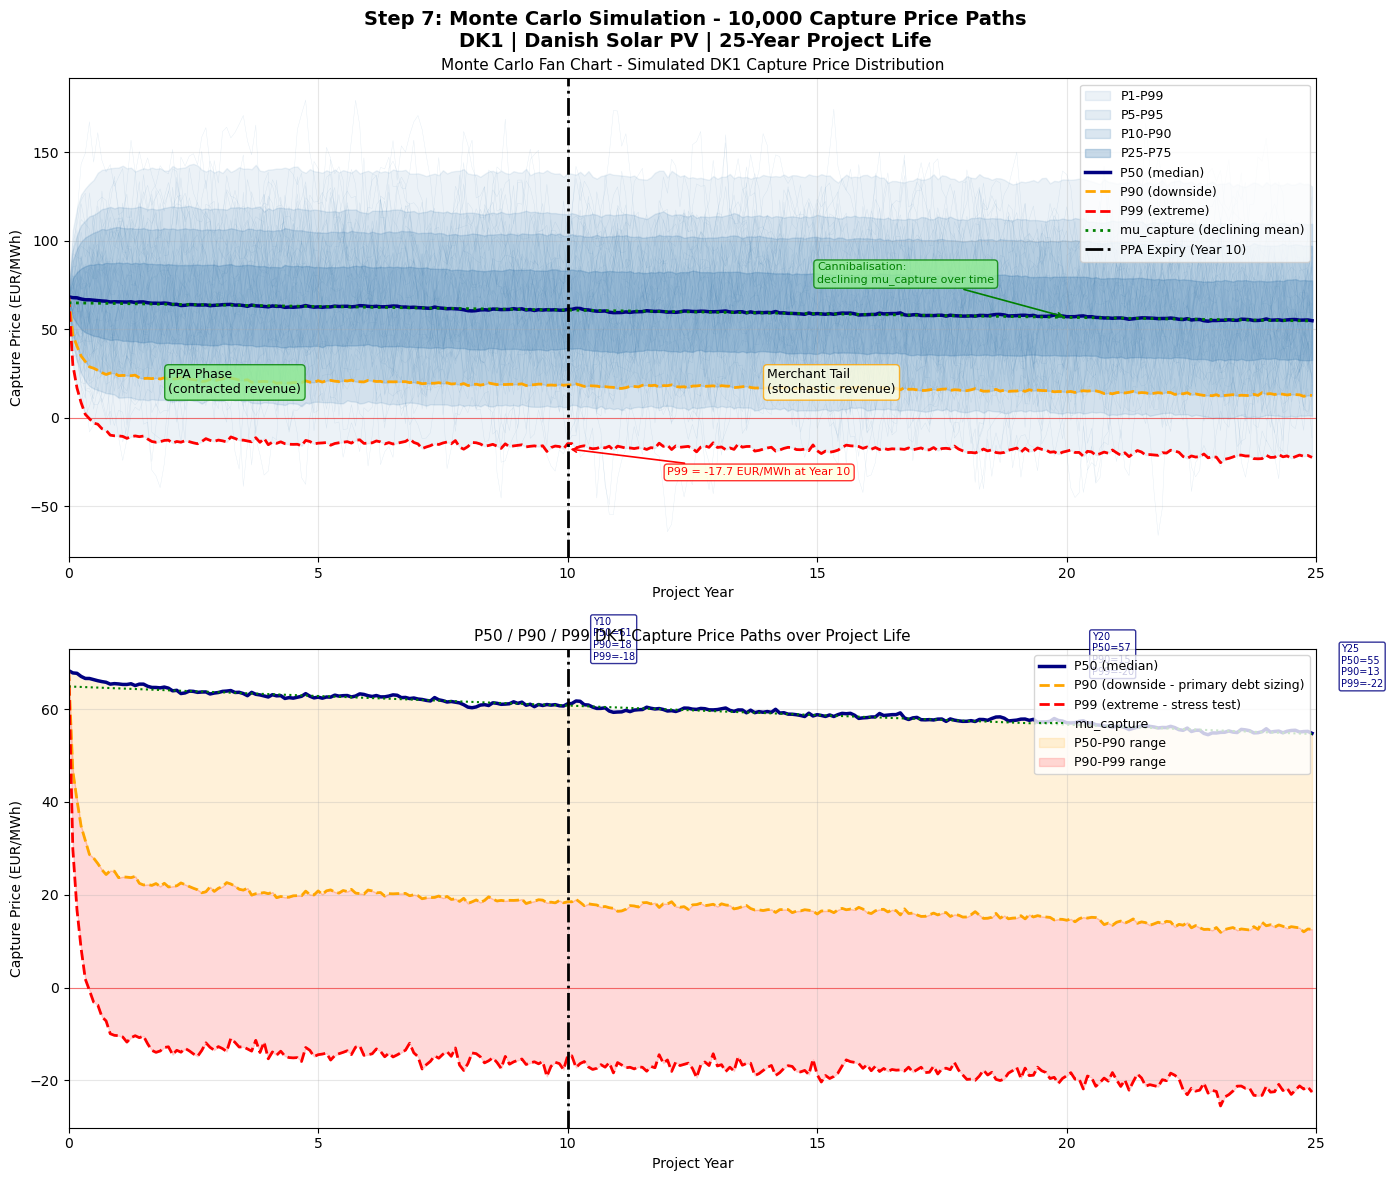

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step7_Monte_Carlo.png
Individual plots saved to: Step7_Monte_Carlo_FanChart.png & Step7_Monte_Carlo_Percentiles.png

=== TABLE 6.1: DESCRIPTIVE STATISTICS ===
Monthly Average Spot Prices (2019-2025)

Statistic               DK1 (primary)   DK2 (robustness)
--------------------------------------------------------
Mean                            86.95              85.76
Median                          72.68              71.75
Std Dev                         72.18              68.67
Min                             14.53              17.35
Max                            456.75             449.77
Skewness                         2.68               2.81
Kurtosis                         9.39              10.47

Note: High kurtosis confirms fat-tailed distribution
      Justifies P90/P99 stress testing framework

=== NEGATIVE PRICE FREQUENCY (Hourly) ===
  DK1 (primary): 2,869 negative hours (3.3% of total)
  DK

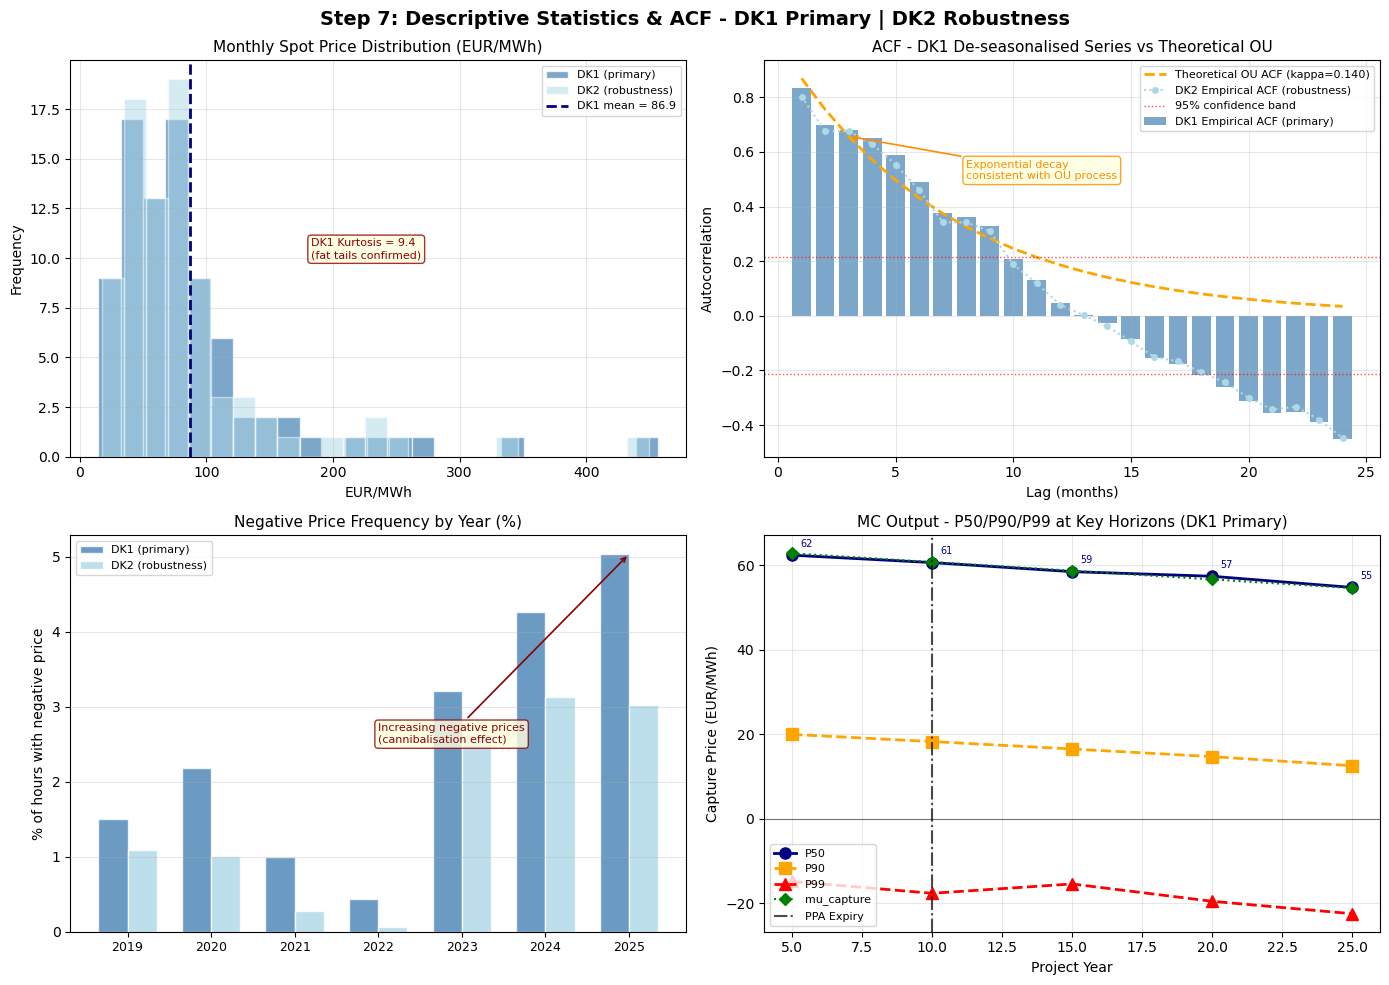

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step7_Descriptive_Statistics.png
Individual plots saved: Step7a, Step7b, Step7c, Step7d
9D: Simulation sheet exported — 300 monthly rows
    DK1 primary parameters used
    Summary table at Years 5, 10, 15, 20, 25
Saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx


In [90]:
# ── STEP 7: MONTE CARLO SIMULATION & DIAGNOSTIC STATISTICS ────────────────

# ════════════════════════════════════════════════════════════════════════════
# 7A: MONTE CARLO SIMULATION
# ════════════════════════════════════════════════════════════════════════════

np.random.seed(42)
dt       = 1
# ── OU parameters from Step 5 (DK1 primary calibration) ───────────────────
mu_ou    = mu_final
kappa_ou = kappa_final
sigma_ou = sigma_final
# ── Cannibalisation coefficient alpha(t) from Step 6 ──────────────────────
# Linear growth from 5% to 20% over 25 years (IEA, 2025)
alpha_t    = np.linspace(0.05, 0.20, N_MONTHS)
mu_capture = mu_ou * (1 - alpha_t)
# ── Discrete-time OU transition parameters ─────────────────────────────────
exp_kdt  = np.exp(-kappa_ou * dt)
var_step = (sigma_ou**2 / (2*kappa_ou)) * (1 - np.exp(-2*kappa_ou*dt))
std_step = np.sqrt(var_step)
# ── Simulate 10,000 paths ──────────────────────────────────────────────────
S0       = mu_ou
paths    = np.zeros((N_PATHS, N_MONTHS))
paths[:, 0] = S0
for t in range(1, N_MONTHS):
    eps = np.random.normal(0, 1, N_PATHS)
    paths[:, t] = (mu_capture[t]
                   + (paths[:, t-1] - mu_capture[t]) * exp_kdt
                   + std_step * eps)
# ── Output statistics ──────────────────────────────────────────────────────
print("=== MONTE CARLO SIMULATION COMPLETE ===")
print(f"  Paths simulated:         {N_PATHS:,}")
print(f"  Project life:            {N_MONTHS} months ({N_MONTHS//12} years)")
print(f"  Starting price:          {S0:.2f} EUR/MWh")
print(f"  Primary specification:   DK1 — Full series ex-2022")
for yr, mo in [(10, 119), (20, 239), (25, 299)]:
    print(f"\n=== YEAR {yr} (Month {mo+1}) ===")
    print(f"  P50: {np.percentile(paths[:,mo], 50):.2f} EUR/MWh")
    print(f"  P90: {np.percentile(paths[:,mo], 10):.2f} EUR/MWh")
    print(f"  P99: {np.percentile(paths[:,mo], 1):.2f} EUR/MWh")

# ── VISUALISATION: MONTE CARLO ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle(
    'Step 7: Monte Carlo Simulation - 10,000 Capture Price Paths\n'
    'DK1 | Danish Solar PV | 25-Year Project Life',
    fontsize=14, fontweight='bold', y=0.98)
time_years = np.arange(N_MONTHS) / 12
p1  = np.percentile(paths, 1,  axis=0)
p5  = np.percentile(paths, 5,  axis=0)
p10 = np.percentile(paths, 10, axis=0)
p25 = np.percentile(paths, 25, axis=0)
p50 = np.percentile(paths, 50, axis=0)
p75 = np.percentile(paths, 75, axis=0)
p90 = np.percentile(paths, 90, axis=0)
p95 = np.percentile(paths, 95, axis=0)
p99 = np.percentile(paths, 99, axis=0)
# ── Plot 1: Fan chart ──────────────────────────────────────────────────────
ax1 = axes[0]
for i in range(50):
    ax1.plot(time_years, paths[i], color='steelblue', linewidth=0.3, alpha=0.15)
ax1.fill_between(time_years, p1,  p99, alpha=0.10, color='steelblue', label='P1-P99')
ax1.fill_between(time_years, p5,  p95, alpha=0.15, color='steelblue', label='P5-P95')
ax1.fill_between(time_years, p10, p90, alpha=0.20, color='steelblue', label='P10-P90')
ax1.fill_between(time_years, p25, p75, alpha=0.30, color='steelblue', label='P25-P75')
ax1.plot(time_years, p50,        color='navy',   linewidth=2.5, label='P50 (median)')
ax1.plot(time_years, p10,        color='orange', linewidth=2.0, linestyle='--',
         label='P90 (downside)')
ax1.plot(time_years, p1,         color='red',    linewidth=2.0, linestyle='--',
         label='P99 (extreme)')
ax1.plot(time_years, mu_capture, color='green',  linewidth=2.0, linestyle=':',
         label='mu_capture (declining mean)')
ax1.axvline(x=10, color='black', linewidth=2.0, linestyle='-.', label='PPA Expiry (Year 10)')
ax1.axhline(y=0,  color='red',   linewidth=0.8, linestyle='-', alpha=0.5)
ax1.annotate('PPA Phase\n(contracted revenue)',
             xy=(5, mu_ou*0.5), xytext=(2, mu_ou*0.2),
             fontsize=9, color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen',
                       edgecolor='green', alpha=0.8))
ax1.annotate('Merchant Tail\n(stochastic revenue)',
             xy=(17, mu_ou*0.5), xytext=(14, mu_ou*0.2),
             fontsize=9, color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='orange', alpha=0.8))
ax1.annotate(f'P99 = {p1[119]:.1f} EUR/MWh at Year 10',
             xy=(10, p1[119]), xytext=(12, p1[119]-15),
             fontsize=8, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='red', alpha=0.8))
ax1.annotate('Cannibalisation:\ndeclining mu_capture over time',
             xy=(20, mu_capture[240]), xytext=(15, mu_capture[240]+20),
             fontsize=8, color='green',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen',
                       edgecolor='green', alpha=0.8))
ax1.set_title('Monte Carlo Fan Chart - Simulated DK1 Capture Price Distribution', fontsize=11)
ax1.set_xlabel('Project Year')
ax1.set_ylabel('Capture Price (EUR/MWh)')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(0, 25)
ax1.grid(True, alpha=0.3)
# ── Plot 2: P50/P90/P99 over time ─────────────────────────────────────────
ax2 = axes[1]
ax2.plot(time_years, p50, color='navy',   linewidth=2.5, label='P50 (median)')
ax2.plot(time_years, p10, color='orange', linewidth=2.0, linestyle='--',
         label='P90 (downside - primary debt sizing)')
ax2.plot(time_years, p1,  color='red',    linewidth=2.0, linestyle='--',
         label='P99 (extreme - stress test)')
ax2.plot(time_years, mu_capture, color='green', linewidth=1.5, linestyle=':',
         label='mu_capture')
ax2.axvline(x=10, color='black', linewidth=2.0, linestyle='-.')
ax2.axhline(y=0,  color='red',   linewidth=0.8, linestyle='-', alpha=0.5)
ax2.fill_between(time_years, p10, p50, alpha=0.15, color='orange', label='P50-P90 range')
ax2.fill_between(time_years, p1,  p10, alpha=0.15, color='red',    label='P90-P99 range')
for yr, mo in [(10, 119), (20, 239), (25, 299)]:
    ax2.annotate(
        f'Y{yr}\nP50={p50[mo]:.0f}\nP90={p10[mo]:.0f}\nP99={p1[mo]:.0f}',
        xy=(yr, p50[mo]), xytext=(yr+0.5, p50[mo]+10),
        fontsize=7, color='navy',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='navy', alpha=0.8))
ax2.set_title('P50 / P90 / P99 DK1 Capture Price Paths over Project Life', fontsize=11)
ax2.set_xlabel('Project Year')
ax2.set_ylabel('Capture Price (EUR/MWh)')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim(0, 25)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step7_Monte_Carlo.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")
# ── Save individual PNGs ───────────────────────────────────────────────────
extent1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step7_Monte_Carlo_FanChart.png',
            dpi=300, bbox_inches=extent1)
extent2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step7_Monte_Carlo_Percentiles.png',
            dpi=300, bbox_inches=extent2)
print(f"Individual plots saved to: Step7_Monte_Carlo_FanChart.png & Step7_Monte_Carlo_Percentiles.png")


# ════════════════════════════════════════════════════════════════════════════
# 7B: DESCRIPTIVE STATISTICS & AUTOCORRELATION ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

# ── 7B-1: Descriptive statistics ──────────────────────────────────────────
print("\n=== TABLE 6.1: DESCRIPTIVE STATISTICS ===")
print("Monthly Average Spot Prices (2019-2025)\n")
print(f"{'Statistic':<20} {'DK1 (primary)':>16} {'DK2 (robustness)':>18}")
print("-" * 56)
for stat, fn in [
    ("Mean",     lambda s: s.mean()),
    ("Median",   lambda s: s.median()),
    ("Std Dev",  lambda s: s.std()),
    ("Min",      lambda s: s.min()),
    ("Max",      lambda s: s.max()),
    ("Skewness", lambda s: s.skew()),
    ("Kurtosis", lambda s: s.kurtosis()),
]:
    v1 = fn(monthly['DK1_Spot'])
    v2 = fn(monthly['DK2_Spot'])
    print(f"{stat:<20} {v1:>16.2f} {v2:>18.2f}")
print("\nNote: High kurtosis confirms fat-tailed distribution")
print("      Justifies P90/P99 stress testing framework")
# ── 7B-2: Negative price frequency ────────────────────────────────────────
print("\n=== NEGATIVE PRICE FREQUENCY (Hourly) ===")
for zone, df in [('DK1 (primary)',   dk1),
                  ('DK2 (robustness)', dk2)]:
    neg   = (df['Price'] < 0).sum()
    total = len(df)
    print(f"  {zone}: {neg:,} negative hours ({100*neg/total:.1f}% of total)")
# ── 7B-3: OU parameter summary ────────────────────────────────────────────
print("\n=== TABLE 6.2: OU PARAMETER ESTIMATES ===")
print(f"{'Parameter':<30} {'DK1 ex-2022':>14} {'DK1 post-crisis':>16} "
      f"{'DK2 ex-2022':>14} {'DK2 post-crisis':>16}")
print("-" * 92)
for param, v1, v2, v3, v4 in [
    ("Long-run mean (mu) EUR/MWh",   mu_final,    mu_dk1r,    mu_dk2,    mu_dk2r),
    ("Mean reversion (kappa) /month",kappa_final, kappa_dk1r, kappa_dk2, kappa_dk2r),
    ("Volatility (sigma) EUR/MWh",   sigma_final, sigma_dk1r, sigma_dk2, sigma_dk2r),
    ("Half-life (months)",           np.log(2)/kappa_final, np.log(2)/kappa_dk1r,
                                     np.log(2)/kappa_dk2,   np.log(2)/kappa_dk2r),
]:
    print(f"{param:<30} {v1:>14.4f} {v2:>16.4f} {v3:>14.4f} {v4:>16.4f}")
# ── 7B-4: Monte Carlo output summary ──────────────────────────────────────
print("\n=== TABLE 6.3: MONTE CARLO SIMULATION OUTPUT — DK1 PRIMARY ===")
print(f"{'Horizon':<12} {'P50':>10} {'P90':>10} {'P99':>10} {'mu_capture':>12}")
print("-" * 56)
for yr, mo in [(5,59),(10,119),(15,179),(20,239),(25,299)]:
    print(f"{'Year '+str(yr):<12} "
          f"{np.percentile(paths[:,mo], 50):>10.2f} "
          f"{np.percentile(paths[:,mo], 10):>10.2f} "
          f"{np.percentile(paths[:,mo],  1):>10.2f} "
          f"{mu_capture[mo]:>12.2f}")
# ── VISUALISATION: DIAGNOSTIC STATISTICS ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Step 7: Descriptive Statistics & ACF - DK1 Primary | DK2 Robustness',
             fontsize=14, fontweight='bold', y=0.98)
# Plot 1: Price distribution histogram
ax1 = axes[0, 0]
ax1.hist(monthly['DK1_Spot'], bins=25, color='steelblue',
         alpha=0.7, edgecolor='white', label='DK1 (primary)')
ax1.hist(monthly['DK2_Spot'], bins=25, color='lightblue',
         alpha=0.5, edgecolor='white', label='DK2 (robustness)')
ax1.axvline(x=monthly['DK1_Spot'].mean(), color='navy', linewidth=2.0,
            linestyle='--', label=f'DK1 mean = {monthly["DK1_Spot"].mean():.1f}')
ax1.annotate(f'DK1 Kurtosis = {monthly["DK1_Spot"].kurtosis():.1f}\n(fat tails confirmed)',
             xy=(monthly['DK1_Spot'].max()*0.6, 8),
             xytext=(monthly['DK1_Spot'].max()*0.4, 10),
             fontsize=8, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax1.set_title('Monthly Spot Price Distribution (EUR/MWh)', fontsize=11)
ax1.set_xlabel('EUR/MWh')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
# Plot 2: ACF of DK1 de-seasonalised series
ax2 = axes[0, 1]
max_lags = 24
acf_dk1 = [monthly['DK1_deseasoned'].autocorr(lag=i) for i in range(1, max_lags+1)]
acf_dk2 = [monthly['DK2_deseasoned'].autocorr(lag=i) for i in range(1, max_lags+1)]
lags    = list(range(1, max_lags+1))
ax2.bar(lags, acf_dk1, color='steelblue', alpha=0.7, label='DK1 Empirical ACF (primary)')
ou_acf = [np.exp(-kappa_final * lag) for lag in lags]
ax2.plot(lags, ou_acf, color='orange', linewidth=2.0, linestyle='--',
         label=f'Theoretical OU ACF (kappa={kappa_final:.3f})')
ax2.plot(lags, acf_dk2, color='lightblue', linewidth=1.5, linestyle=':',
         marker='o', markersize=4, label='DK2 Empirical ACF (robustness)')
conf = 1.96 / np.sqrt(len(monthly))
ax2.axhline(y=conf,  color='red', linewidth=1.0, linestyle=':', alpha=0.7,
            label='95% confidence band')
ax2.axhline(y=-conf, color='red', linewidth=1.0, linestyle=':', alpha=0.7)
ax2.annotate('Exponential decay\nconsistent with OU process',
             xy=(3, ou_acf[2]), xytext=(8, 0.5),
             fontsize=8, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkorange', alpha=0.8))
ax2.set_title('ACF - DK1 De-seasonalised Series vs Theoretical OU', fontsize=11)
ax2.set_xlabel('Lag (months)')
ax2.set_ylabel('Autocorrelation')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
# Plot 3: Negative price frequency by year
ax3 = axes[1, 0]
dk1['year'] = dk1['datetime'].dt.year
dk2['year'] = dk2['datetime'].dt.year
neg_dk1 = dk1.groupby('year').apply(lambda x: (x['Price']<0).sum()/len(x)*100)
neg_dk2 = dk2.groupby('year').apply(lambda x: (x['Price']<0).sum()/len(x)*100)
x_pos   = np.arange(len(neg_dk1))
width   = 0.35
ax3.bar(x_pos - width/2, neg_dk1.values, width, color='steelblue',
        alpha=0.8, label='DK1 (primary)', edgecolor='white')
ax3.bar(x_pos + width/2, neg_dk2.values, width, color='lightblue',
        alpha=0.8, label='DK2 (robustness)', edgecolor='white')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(neg_dk1.index.astype(str), fontsize=9)
ax3.annotate('Increasing negative prices\n(cannibalisation effect)',
             xy=(x_pos[-1], neg_dk1.values[-1]),
             xytext=(x_pos[-4], neg_dk1.values[-1]*0.5),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax3.set_title('Negative Price Frequency by Year (%)', fontsize=11)
ax3.set_ylabel('% of hours with negative price')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')
# Plot 4: MC output summary
ax4 = axes[1, 1]
years_plot = [5, 10, 15, 20, 25]
months_    = [59, 119, 179, 239, 299]
p50_pts = [np.percentile(paths[:,m], 50) for m in months_]
p90_pts = [np.percentile(paths[:,m], 10) for m in months_]
p99_pts = [np.percentile(paths[:,m],  1) for m in months_]
muc_pts = [mu_capture[m] for m in months_]
ax4.plot(years_plot, p50_pts, color='navy',   marker='o', linewidth=2.0,
         markersize=8, label='P50')
ax4.plot(years_plot, p90_pts, color='orange', marker='s', linewidth=2.0,
         markersize=8, linestyle='--', label='P90')
ax4.plot(years_plot, p99_pts, color='red',    marker='^', linewidth=2.0,
         markersize=8, linestyle='--', label='P99')
ax4.plot(years_plot, muc_pts, color='green',  marker='D', linewidth=1.5,
         markersize=6, linestyle=':', label='mu_capture')
ax4.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax4.axvline(x=10, color='black', linewidth=1.5, linestyle='-.', alpha=0.7,
            label='PPA Expiry')
for i, yr in enumerate(years_plot):
    ax4.annotate(f'{p50_pts[i]:.0f}', xy=(yr, p50_pts[i]),
                 xytext=(yr+0.3, p50_pts[i]+2), fontsize=7, color='navy')
ax4.set_title('MC Output - P50/P90/P99 at Key Horizons (DK1 Primary)', fontsize=11)
ax4.set_xlabel('Project Year')
ax4.set_ylabel('Capture Price (EUR/MWh)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
# ── Save combined PNG ──────────────────────────────────────────────────────
output_path = base + '/4. Outputs/Step7_Descriptive_Statistics.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")
# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()
extent1 = axes[0,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step7a_Price_Distribution.png', dpi=300, bbox_inches=extent1)
extent2 = axes[0,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step7b_ACF.png', dpi=300, bbox_inches=extent2)
extent3 = axes[1,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step7c_Negative_Price_Frequency.png', dpi=300, bbox_inches=extent3)
extent4 = axes[1,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step7d_MC_Output_Summary.png', dpi=300, bbox_inches=extent4)
print("Individual plots saved: Step7a, Step7b, Step7c, Step7d")
from openpyxl.chart import LineChart, BarChart, Reference

wb = load_workbook(master_path)
ws = wb['Simulation']
ws.delete_rows(1, ws.max_row)

time_years_arr = np.arange(N_MONTHS) / 12

mc_data = pd.DataFrame({
    'Month':      range(1, N_MONTHS+1),
    'Year':       np.round(time_years_arr, 4),
    'mu_capture': np.round(mu_capture, 4),
    'P50':        np.round(np.percentile(paths, 50, axis=0), 4),
    'P75':        np.round(np.percentile(paths, 75, axis=0), 4),
    'P90':        np.round(np.percentile(paths, 90, axis=0), 4),
    'P25':        np.round(np.percentile(paths, 25, axis=0), 4),
    'P10':        np.round(np.percentile(paths, 10, axis=0), 4),
    'P1':         np.round(np.percentile(paths,  1, axis=0), 4),
})

headers = mc_data.columns.tolist()
for col, header in enumerate(headers, 1):
    ws.cell(row=1, column=col, value=header)
for row_idx, row in enumerate(mc_data.itertuples(index=False), 2):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)

n_rows = len(mc_data) + 1

# Summary table
summary_col = len(headers) + 2
ws.cell(row=1, column=summary_col,   value='MC SIMULATION SUMMARY — DK1 PRIMARY')
ws.cell(row=2, column=summary_col,   value='Horizon')
ws.cell(row=2, column=summary_col+1, value='P50')
ws.cell(row=2, column=summary_col+2, value='P90')
ws.cell(row=2, column=summary_col+3, value='P99')
ws.cell(row=2, column=summary_col+4, value='mu_capture')
for i, (yr, mo) in enumerate([(5,59),(10,119),(15,179),(20,239),(25,299)], 3):
    ws.cell(row=i, column=summary_col,   value=f'Year {yr}')
    ws.cell(row=i, column=summary_col+1, value=round(float(np.percentile(paths[:,mo],50)),2))
    ws.cell(row=i, column=summary_col+2, value=round(float(np.percentile(paths[:,mo],10)),2))
    ws.cell(row=i, column=summary_col+3, value=round(float(np.percentile(paths[:,mo], 1)),2))
    ws.cell(row=i, column=summary_col+4, value=round(float(mu_capture[mo]),2))

ws.cell(row=9,  column=summary_col,   value='PARAMETERS USED (DK1 Primary)')
ws.cell(row=10, column=summary_col,   value='mu (EUR/MWh)')
ws.cell(row=10, column=summary_col+1, value=round(mu_final, 4))
ws.cell(row=11, column=summary_col,   value='kappa (/month)')
ws.cell(row=11, column=summary_col+1, value=round(kappa_final, 4))
ws.cell(row=12, column=summary_col,   value='sigma (EUR/MWh)')
ws.cell(row=12, column=summary_col+1, value=round(sigma_final, 4))
ws.cell(row=13, column=summary_col,   value='N paths')
ws.cell(row=13, column=summary_col+1, value=N_PATHS)
ws.cell(row=14, column=summary_col,   value='Alpha(t=0)')
ws.cell(row=14, column=summary_col+1, value='5%')
ws.cell(row=15, column=summary_col,   value='Alpha(t=25)')
ws.cell(row=15, column=summary_col+1, value='20%')

# Chart 1: P50/P90/P99 fan chart
chart1 = LineChart()
chart1.title        = "MC Simulation - DK1 P50/P90/P99 Capture Price Paths"
chart1.style        = 10
chart1.y_axis.title = "Capture Price (EUR/MWh)"
chart1.x_axis.title = "Month"
chart1.width        = 30
chart1.height       = 16
for col, color in [(3,"70AD47"),(4,"2E75B6"),(6,"FF8C00"),(9,"C00000")]:
    data = Reference(ws, min_col=col, min_row=1, max_row=n_rows)
    chart1.add_data(data, titles_from_data=True)
idx = 0
for color, dash in [("70AD47","dash"),("2E75B6",None),("FF8C00","dash"),("C00000","dash")]:
    chart1.series[idx].graphicalProperties.line.solidFill = color
    if dash:
        chart1.series[idx].graphicalProperties.line.dashDot = dash
    idx += 1
ws.add_chart(chart1, "M2")

# Chart 2: Summary bar chart
chart2 = BarChart()
chart2.title        = "P50/P90/P99 at Key Project Horizons — DK1 Primary"
chart2.style        = 10
chart2.y_axis.title = "Capture Price (EUR/MWh)"
chart2.x_axis.title = "Project Year"
chart2.width        = 20
chart2.height       = 12
chart2.type         = "col"
for col, color in [(summary_col+1,"2E75B6"),(summary_col+2,"FF8C00"),(summary_col+3,"C00000")]:
    data = Reference(ws, min_col=col, min_row=2, max_row=7)
    chart2.add_data(data, titles_from_data=True)
cats = Reference(ws, min_col=summary_col, min_row=3, max_row=7)
chart2.set_categories(cats)
for i, color in enumerate(["2E75B6","FF8C00","C00000"]):
    chart2.series[i].graphicalProperties.solidFill = color
ws.add_chart(chart2, "M32")

wb.save(master_path)
print(f"9D: Simulation sheet exported — {len(mc_data)} monthly rows")
print(f"    DK1 primary parameters used")
print(f"    Summary table at Years 5, 10, 15, 20, 25")
print(f"Saved to: {master_path}")


# PHASE 5: VALUATION

## Step 8: FCFF Model & Segmented NPV

**Purpose**  
Builds the full monthly free cash flow waterfall for all 10,000 Monte Carlo paths and values the project under segmented and single-WACC discounting.

**Methodology**  
The monthly cash flow waterfall is constructed as follows:

- Production (MWh) = Capacity × NCF × (1 − Curtailment) × (1 − Degradation)^year
- Revenue = Production × Price (PPA price during the contracted phase; simulated capture price during the merchant phase)
- OPEX = O&M × (1 + escalation)^year
- EBITDA = Revenue − OPEX
- Tax = EBITDA × tax rate, if EBITDA is positive
- FCFF = EBITDA − Tax

The segmented NPV framework is applied as follows:
- PPA cash flows (months 1–120) are discounted at WACC_PPA,m
- Merchant cash flows (months 121–300) are discounted at WACC_merchant,m back to month 120, and then at WACC_PPA,m back to time 0

A single-WACC benchmark is also computed:
- All cash flows are discounted at one blended WACC for comparison

**Specifications**

- **Primary:** 10,000 DK1 Monte Carlo price paths under the primary calibration
- **Robustness:** Single-WACC benchmark as the comparison framework

**Parameters / Inputs**
- 10,000 simulated price paths
- Capacity
- NCF
- Curtailment
- Degradation
- PPA price
- O&M
- OPEX escalation
- Tax rate
- WACC_PPA,m
- WACC_merchant,m
- Blended single WACC

**Output**  
Produces P50, P90, and P99 monthly FCFF profiles exported to Excel, together with the full NPV distribution across 10,000 paths under both the segmented and single-WACC frameworks.

=== BETA SHIFT & SEGMENTED WACC CONSTRUCTION ===
  Rf=2.25% | ERP=4.23% | τ=22%
  PPA:      β=0.46 | E/V=25% | r_e=4.196% | r_d=4.000% | WACC=3.389%
  Merchant: β=0.57 | E/V=45% | r_e=4.661% | r_d=5.500% | WACC=4.457%
  Δβ = +0.11  →  ΔWACC = +1.068% (annual)
  WACC_PPA,m   = 0.2781%
  WACC_merch,m = 0.3640%
  WACC_single,m= 0.3297%
  Three-channel differentiation:
    (1) r_e rises via beta shift
    (2) r_d rises via higher credit spread
    (3) D/V falls via reduced debt capacity (E/V: 25% → 45%)

=== MODEL PARAMETERS ===
  Capacity:        50 MW
  NCF P50:         12.23%  (CF*curtailment*availability — degradation separate)
  CAPEX:           23,000 EURk
  O&M annual:      414 EURk
  PPA price:       45.0 EUR/MWh
  Tax rate:        22%
  WACC_PPA,m:      0.2781%
  WACC_merchant,m: 0.3640%
  WACC_single,m:   0.3297%

=== SANITY CHECK ===
  Month 1 production: 4463.95 MWh
  Month 1 revenue:    200.88 EURk
  Month 1 OPEX:       -34.50 EURk
  Month 1 EBITDA:     166.38 EURk
  Annual re

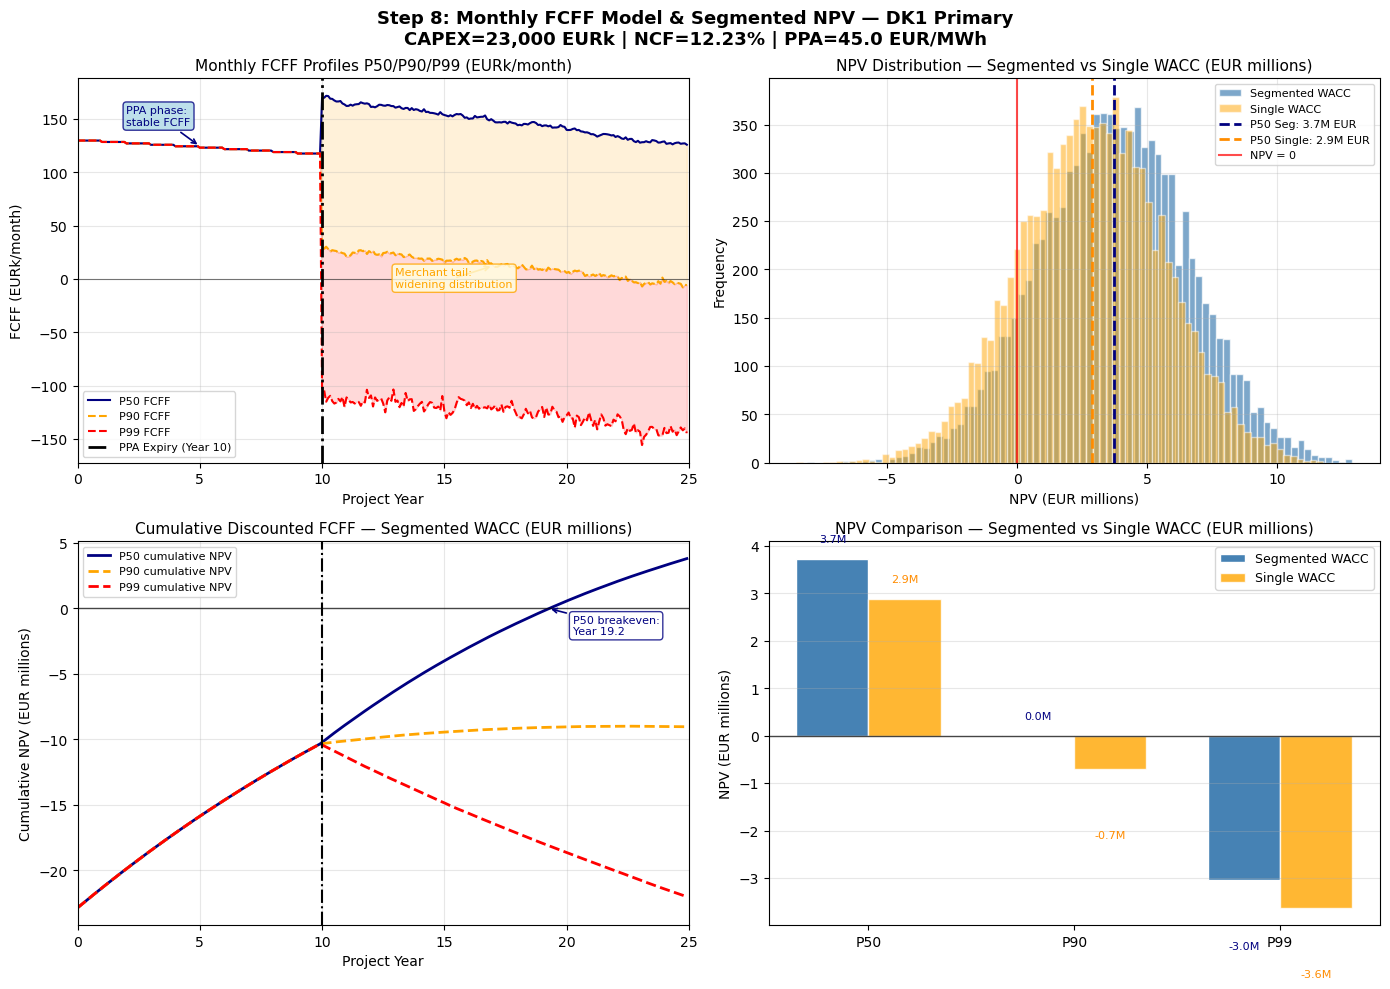

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step8_FCFF_NPV.png
Individual plots saved: Step8a, Step8b, Step8c, Step8d


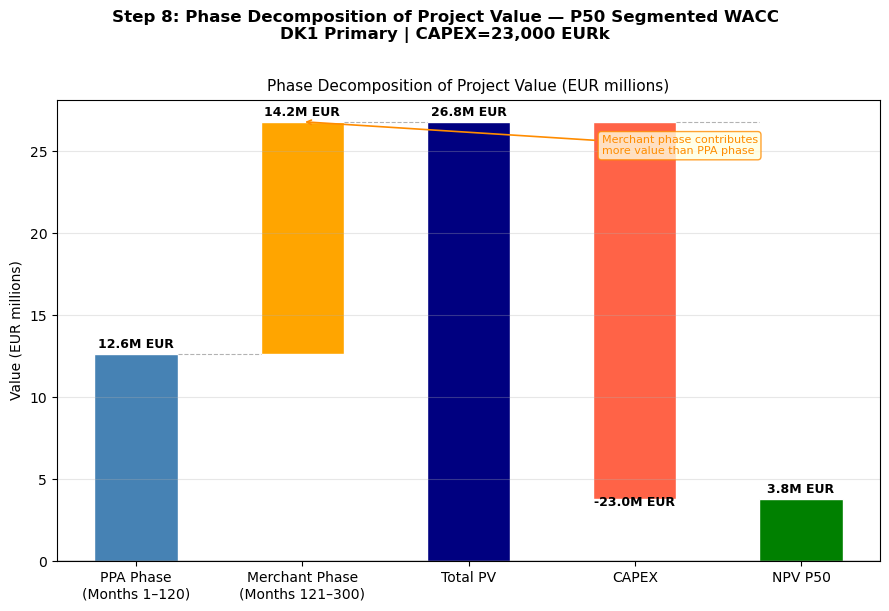

Phase decomposition plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step8e_Phase_Decomposition.png

Exported to Excel: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx
  3 scenario blocks x 10 formula rows x 300 months
  Assumptions: E16 (prod), E23 (deg), E31 (capex),
               E35 (O&M), E36 (esc), E40 (PPA), E47 (tax)
  WACC: E34 (WACC_PPA,m), E35 (WACC_merchant,m)
  Simulation: rows 7-306, P50=E, P90=I, P99=J
Step 8 complete!


In [97]:
# ── STEP 8: MONTHLY FCFF MODEL, SEGMENTED NPV & EXPORT TO EXCEL ───────────

# ════════════════════════════════════════════════════════════════════════════
# BETA SHIFT & SEGMENTED WACC CONSTRUCTION (mirrors Excel WACC sheet)
# All inputs sourced from Data Log; formulas identical to WACC!E18–E35
# ════════════════════════════════════════════════════════════════════════════

# ── Macroeconomic inputs (Data Log E23, E24, E35) ─────────────────────────
RF              = 0.0225   # Risk-free rate (Data Log E23)
ERP             = 0.0423   # Equity Risk Premium (Data Log E24)
TAX_RATE        = 0.22     # Corporate tax rate τ (Data Log E35)

# ── PPA phase inputs (Data Log E26, E29, E32) ─────────────────────────────
BETA_PPA        = 0.46     # β_PPA unlevered asset beta (Data Log E26)
EQUITY_SHARE_PPA= 0.25     # E/V PPA phase (Data Log E32)
DEBT_MARGIN_PPA = 0.0175   # Debt margin PPA (Data Log E29)

# ── Merchant phase inputs (Data Log E27, E30, E33) ────────────────────────
BETA_MERCH      = 0.57     # β_merchant unlevered asset beta (Data Log E27)
EQUITY_SHARE_MC = 0.45     # E/V Merchant phase (Data Log E33) — RISES due to bankability
DEBT_MARGIN_MC  = 0.0325   # Debt margin Merchant (Data Log E30)

# ── PPA phase derivations (WACC sheet E18–E20) ────────────────────────────
DEBT_SHARE_PPA  = 1 - EQUITY_SHARE_PPA
RE_PPA          = RF + BETA_PPA * ERP                                  # CAPM
RD_PPA          = RF + DEBT_MARGIN_PPA                                 # Rf + spread
WACC_PPA_ANN    = EQUITY_SHARE_PPA * RE_PPA + DEBT_SHARE_PPA * RD_PPA * (1 - TAX_RATE)

# ── Merchant phase derivations (WACC sheet E28–E30) ───────────────────────
DEBT_SHARE_MC   = 1 - EQUITY_SHARE_MC
RE_MERCH        = RF + BETA_MERCH * ERP
RD_MERCH        = RF + DEBT_MARGIN_MC
WACC_MERCH_ANN  = EQUITY_SHARE_MC * RE_MERCH + DEBT_SHARE_MC * RD_MERCH * (1 - TAX_RATE)

# ── Monthly conversion (WACC sheet E34, E35) ──────────────────────────────
WACC_PPA_M      = (1 + WACC_PPA_ANN  )**(1/12) - 1
WACC_MERCH_M    = (1 + WACC_MERCH_ANN)**(1/12) - 1

# ── Single WACC benchmark (time-weighted blend) ───────────────────────────
WACC_SINGLE_M   = (120/300) * WACC_PPA_M + (180/300) * WACC_MERCH_M

# ── Three-channel beta-shift diagnostic (WACC sheet rows 39–44) ───────────
BETA_SHIFT      = BETA_MERCH - BETA_PPA
WACC_SHIFT_ANN  = WACC_MERCH_ANN - WACC_PPA_ANN

print("=== BETA SHIFT & SEGMENTED WACC CONSTRUCTION ===")
print(f"  Rf={RF:.2%} | ERP={ERP:.2%} | τ={TAX_RATE:.0%}")
print(f"  PPA:      β={BETA_PPA:.2f} | E/V={EQUITY_SHARE_PPA:.0%} | "
      f"r_e={RE_PPA:.3%} | r_d={RD_PPA:.3%} | WACC={WACC_PPA_ANN:.3%}")
print(f"  Merchant: β={BETA_MERCH:.2f} | E/V={EQUITY_SHARE_MC:.0%} | "
      f"r_e={RE_MERCH:.3%} | r_d={RD_MERCH:.3%} | WACC={WACC_MERCH_ANN:.3%}")
print(f"  Δβ = +{BETA_SHIFT:.2f}  →  ΔWACC = +{WACC_SHIFT_ANN:.3%} (annual)")
print(f"  WACC_PPA,m   = {WACC_PPA_M:.4%}")
print(f"  WACC_merch,m = {WACC_MERCH_M:.4%}")
print(f"  WACC_single,m= {WACC_SINGLE_M:.4%}")
print("  Three-channel differentiation:")
print("    (1) r_e rises via beta shift")
print("    (2) r_d rises via higher credit spread")
print("    (3) D/V falls via reduced debt capacity (E/V: 25% → 45%)")

# ── PROJECT ASSUMPTIONS ────────────────────────────────────────────────────
CAPACITY_MW    = 50
NCF_P50        = 0.1223
CAPEX_EURK     = 23000
OM_ANNUAL_EURK = 414
OPEX_ESC       = 0.02
PPA_PRICE      = 45.0
PPA_MONTHS     = 120
DEGRADATION    = 0.005

print("\n=== MODEL PARAMETERS ===")
print(f"  Capacity:        {CAPACITY_MW} MW")
print(f"  NCF P50:         {NCF_P50:.2%}  (CF*curtailment*availability — degradation separate)")
print(f"  CAPEX:           {CAPEX_EURK:,} EURk")
print(f"  O&M annual:      {OM_ANNUAL_EURK:,} EURk")
print(f"  PPA price:       {PPA_PRICE} EUR/MWh")
print(f"  Tax rate:        {TAX_RATE:.0%}")
print(f"  WACC_PPA,m:      {WACC_PPA_M:.4%}")
print(f"  WACC_merchant,m: {WACC_MERCH_M:.4%}")
print(f"  WACC_single,m:   {WACC_SINGLE_M:.4%}")

# ── MONTHLY PRODUCTION PROFILE ─────────────────────────────────────────────
monthly_production = np.zeros(N_MONTHS)
for t in range(N_MONTHS):
    year = t // 12
    monthly_production[t] = (CAPACITY_MW * 1000 * NCF_P50
                              * 8760 / 12
                              * (1 - DEGRADATION)**year
                              / 1000)

# ── MONTHLY OPEX PROFILE ───────────────────────────────────────────────────
monthly_opex = np.zeros(N_MONTHS)
for t in range(N_MONTHS):
    year = t // 12
    monthly_opex[t] = -(OM_ANNUAL_EURK * (1 + OPEX_ESC)**year) / 12

# ── MONTHLY DISCOUNT FACTORS ───────────────────────────────────────────────
disc_merch  = np.zeros(N_MONTHS)
disc_single = np.zeros(N_MONTHS)
for t in range(N_MONTHS):
    if t < PPA_MONTHS:
        disc_merch[t]  = 1 / (1 + WACC_PPA_M)**(t+1)
    else:
        months_into_merchant = t - PPA_MONTHS + 1
        disc_merch[t] = (1 / (1 + WACC_PPA_M)**PPA_MONTHS
                        * 1 / (1 + WACC_MERCH_M)**months_into_merchant)
    disc_single[t] = 1 / (1 + WACC_SINGLE_M)**(t+1)

# ── SANITY CHECK ───────────────────────────────────────────────────────────
print(f"\n=== SANITY CHECK ===")
print(f"  Month 1 production: {monthly_production[0]:.2f} MWh")
print(f"  Month 1 revenue:    {monthly_production[0]*PPA_PRICE/1000:.2f} EURk")
print(f"  Month 1 OPEX:       {monthly_opex[0]:.2f} EURk")
print(f"  Month 1 EBITDA:     {monthly_production[0]*PPA_PRICE/1000+monthly_opex[0]:.2f} EURk")
print(f"  Annual revenue Y1:  {monthly_production[0]*PPA_PRICE/1000*12:.2f} EURk")

# ── FCFF MODEL ON ALL 10,000 PATHS ────────────────────────────────────────
print("\nRunning FCFF model on all 10,000 paths...")
price_paths = np.zeros((N_PATHS, N_MONTHS))
price_paths[:, :PPA_MONTHS]  = PPA_PRICE
price_paths[:, PPA_MONTHS:]  = paths[:, PPA_MONTHS:]
revenue = price_paths * monthly_production / 1000
opex    = np.tile(monthly_opex, (N_PATHS, 1))
ebitda  = revenue + opex
tax     = np.where(ebitda > 0, -ebitda * TAX_RATE, 0)
fcff    = ebitda + tax

# ── NPV CALCULATIONS ───────────────────────────────────────────────────────
npv_segmented = np.sum(fcff * disc_merch,  axis=1) - CAPEX_EURK
npv_single    = np.sum(fcff * disc_single, axis=1) - CAPEX_EURK

# ── PERCENTILE FCFF PROFILES ───────────────────────────────────────────────
fcff_p50 = np.percentile(fcff, 50, axis=0)
fcff_p90 = np.percentile(fcff, 10, axis=0)
fcff_p99 = np.percentile(fcff,  1, axis=0)
print(f"FCFF model complete — {N_PATHS:,} paths x {N_MONTHS} months")

print("\n=== NPV RESULTS (EURk) ===")
print(f"{'Scenario':<10} {'Segmented':>12} {'Single WACC':>12} {'Difference':>12}")
print("-" * 50)
for scen, pct in [("P50", 50), ("P90", 10), ("P99", 1)]:
    seg  = np.percentile(npv_segmented, pct)
    sing = np.percentile(npv_single,    pct)
    diff = sing - seg
    print(f"{scen:<10} {seg:>12,.0f} {sing:>12,.0f} {diff:>12,.0f}")

print("\n=== NPV DECOMPOSITION P50 ===")
pv_ppa   = np.sum(fcff_p50[:120] * disc_merch[:120])
pv_merch = np.sum(fcff_p50[120:] * disc_merch[120:])
print(f"  PV PPA phase:      {pv_ppa:>10,.0f} EURk")
print(f"  PV Merchant phase: {pv_merch:>10,.0f} EURk")
print(f"  PV Total:          {pv_ppa+pv_merch:>10,.0f} EURk")
print(f"  CAPEX:             {CAPEX_EURK:>10,.0f} EURk")
print(f"  NPV P50:           {pv_ppa+pv_merch-CAPEX_EURK:>10,.0f} EURk")

# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Step 8: Monthly FCFF Model & Segmented NPV — DK1 Primary\n'
             f'CAPEX={CAPEX_EURK:,} EURk | NCF={NCF_P50:.2%} | PPA={PPA_PRICE} EUR/MWh',
             fontsize=13, fontweight='bold', y=0.98)
time_years = np.arange(N_MONTHS) / 12
ax1 = axes[0, 0]
ax1.plot(time_years, fcff_p50, color='navy',   linewidth=1.5, label='P50 FCFF')
ax1.plot(time_years, fcff_p90, color='orange', linewidth=1.5,
         linestyle='--', label='P90 FCFF')
ax1.plot(time_years, fcff_p99, color='red',    linewidth=1.5,
         linestyle='--', label='P99 FCFF')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax1.axvline(x=10, color='black', linewidth=2.0, linestyle='-.',
            label='PPA Expiry (Year 10)')
ax1.fill_between(time_years, fcff_p90, fcff_p50, alpha=0.15, color='orange')
ax1.fill_between(time_years, fcff_p99, fcff_p90, alpha=0.15, color='red')
ax1.annotate('PPA phase:\nstable FCFF',
             xy=(5, fcff_p50[59]),
             xytext=(2, fcff_p50[59] + 20),
             fontsize=8, color='navy',
             arrowprops=dict(arrowstyle='->', color='navy', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue',
                       edgecolor='navy', alpha=0.8))
ax1.annotate('Merchant tail:\nwidening distribution',
             xy=(17, fcff_p90[204]),
             xytext=(13, fcff_p90[204] - 20),
             fontsize=8, color='orange',
             arrowprops=dict(arrowstyle='->', color='orange', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='orange', alpha=0.8))
ax1.set_title('Monthly FCFF Profiles P50/P90/P99 (EURk/month)', fontsize=11)
ax1.set_xlabel('Project Year')
ax1.set_ylabel('FCFF (EURk/month)')
ax1.legend(fontsize=8)
ax1.set_xlim(0, 25)
ax1.grid(True, alpha=0.3)
ax2 = axes[0, 1]
ax2.hist(npv_segmented/1000, bins=80, color='steelblue',
         alpha=0.7, edgecolor='white', label='Segmented WACC')
ax2.hist(npv_single/1000,    bins=80, color='orange',
         alpha=0.5, edgecolor='white', label='Single WACC')
ax2.axvline(x=np.percentile(npv_segmented, 50)/1000, color='navy',
            linewidth=2.0, linestyle='--',
            label=f'P50 Seg: {np.percentile(npv_segmented,50)/1000:,.1f}M EUR')
ax2.axvline(x=np.percentile(npv_single, 50)/1000, color='darkorange',
            linewidth=2.0, linestyle='--',
            label=f'P50 Single: {np.percentile(npv_single,50)/1000:,.1f}M EUR')
ax2.axvline(x=0, color='red', linewidth=1.5, linestyle='-', alpha=0.7,
            label='NPV = 0')
ax2.set_title('NPV Distribution — Segmented vs Single WACC (EUR millions)',
              fontsize=11)
ax2.set_xlabel('NPV (EUR millions)')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax3 = axes[1, 0]
cum_p50 = np.cumsum(fcff_p50 * disc_merch) - CAPEX_EURK
cum_p90 = np.cumsum(fcff_p90 * disc_merch) - CAPEX_EURK
cum_p99 = np.cumsum(fcff_p99 * disc_merch) - CAPEX_EURK
ax3.plot(time_years, cum_p50/1000, color='navy',   linewidth=2.0,
         label='P50 cumulative NPV')
ax3.plot(time_years, cum_p90/1000, color='orange', linewidth=2.0,
         linestyle='--', label='P90 cumulative NPV')
ax3.plot(time_years, cum_p99/1000, color='red',    linewidth=2.0,
         linestyle='--', label='P99 cumulative NPV')
ax3.axhline(y=0, color='black', linewidth=1.0, linestyle='-', alpha=0.7)
ax3.axvline(x=10, color='black', linewidth=1.5, linestyle='-.')
for arr, col, lbl in [(cum_p50,'navy','P50'),(cum_p90,'orange','P90')]:
    crossings = np.where(np.diff(np.sign(arr)))[0]
    if len(crossings) > 0:
        be_yr = time_years[crossings[0]]
        ax3.annotate(f'{lbl} breakeven:\nYear {be_yr:.1f}',
                     xy=(be_yr, 0), xytext=(be_yr+1, -2),
                     fontsize=8, color=col,
                     arrowprops=dict(arrowstyle='->', color=col, lw=1.2),
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                               edgecolor=col, alpha=0.8))
ax3.set_title('Cumulative Discounted FCFF — Segmented WACC (EUR millions)',
              fontsize=11)
ax3.set_xlabel('Project Year')
ax3.set_ylabel('Cumulative NPV (EUR millions)')
ax3.legend(fontsize=8)
ax3.set_xlim(0, 25)
ax3.grid(True, alpha=0.3)
ax4 = axes[1, 1]
scenarios_npv = ['P50', 'P90', 'P99']
seg_vals  = [np.percentile(npv_segmented, p)/1000 for p in [50, 10, 1]]
sing_vals = [np.percentile(npv_single,    p)/1000 for p in [50, 10, 1]]
x     = np.arange(len(scenarios_npv))
width = 0.35
bars1 = ax4.bar(x - width/2, seg_vals,  width, color='steelblue',
                label='Segmented WACC', edgecolor='white')
bars2 = ax4.bar(x + width/2, sing_vals, width, color='orange',
                label='Single WACC',    edgecolor='white', alpha=0.8)
ax4.axhline(y=0, color='black', linewidth=1.0, linestyle='-', alpha=0.7)
for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if bar.get_height() >= 0 else -1.5),
             f'{bar.get_height():,.1f}M',
             ha='center', va='bottom', fontsize=8, color='navy')
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if bar.get_height() >= 0 else -1.5),
             f'{bar.get_height():,.1f}M',
             ha='center', va='bottom', fontsize=8, color='darkorange')
ax4.set_title('NPV Comparison — Segmented vs Single WACC (EUR millions)',
              fontsize=11)
ax4.set_ylabel('NPV (EUR millions)')
ax4.set_xticks(x)
ax4.set_xticklabels(scenarios_npv)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# ── Save combined PNG (original) ───────────────────────────────────────────
plot_path = base + '/4. Outputs/Step8_FCFF_NPV.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")
# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()
extent1 = axes[0,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step8a_FCFF_Profiles.png', dpi=300, bbox_inches=extent1)
extent2 = axes[0,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step8b_NPV_Distribution.png', dpi=300, bbox_inches=extent2)
extent3 = axes[1,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step8c_Cumulative_NPV.png', dpi=300, bbox_inches=extent3)
extent4 = axes[1,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step8d_NPV_Comparison.png', dpi=300, bbox_inches=extent4)
print("Individual plots saved: Step8a, Step8b, Step8c, Step8d")
# ── PHASE DECOMPOSITION FIGURE — WATERFALL ─────────────────────────────────
fig_pd, ax_pd = plt.subplots(figsize=(9, 6))
fig_pd.suptitle('Step 8: Phase Decomposition of Project Value — P50 Segmented WACC\n'
                f'DK1 Primary | CAPEX={CAPEX_EURK:,} EURk',
                fontsize=12, fontweight='bold', y=1.01)
labels  = ['PPA Phase\n(Months 1–120)', 'Merchant Phase\n(Months 121–300)',
           'Total PV', 'CAPEX', 'NPV P50']
values  = [pv_ppa/1000, pv_merch/1000,
           (pv_ppa + pv_merch)/1000, -CAPEX_EURK/1000,
           (pv_ppa + pv_merch - CAPEX_EURK)/1000]
running = 0
bottoms = []
heights = []
colors  = []
for i, (lbl, val) in enumerate(zip(labels, values)):
    if lbl in ['Total PV', 'NPV P50']:
        bottoms.append(0)
        heights.append(val)
        colors.append('navy' if lbl == 'Total PV' else
                       ('green' if val >= 0 else 'red'))
        running = val
    elif val < 0:
        bottoms.append(running + val)
        heights.append(abs(val))
        colors.append('tomato')
        running += val
    else:
        bottoms.append(running)
        heights.append(val)
        colors.append('steelblue' if i == 0 else 'orange')
        running += val
bars = ax_pd.bar(labels, heights, bottom=bottoms, color=colors,
                 edgecolor='white', width=0.5)
connector_pairs = [(0, 1), (1, 2), (3, 4)]
for i, j in connector_pairs:
    top_i = bottoms[i] + heights[i]
    ax_pd.plot([i + 0.25, j - 0.25], [top_i, top_i],
               color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
for bar, bottom, val in zip(bars, bottoms, values):
    label_y = bottom + bar.get_height() + 0.15 if val >= 0 else bottom - 0.6
    ax_pd.text(bar.get_x() + bar.get_width()/2,
               label_y,
               f'{val:+,.1f}M EUR' if val < 0 else f'{val:,.1f}M EUR',
               ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_pd.annotate('Merchant phase contributes\nmore value than PPA phase',
               xy=(1, bottoms[1] + heights[1]),
               xytext=(2.8, bottoms[1] + heights[1] - 2),
               fontsize=8, color='darkorange',
               arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
               bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                         edgecolor='darkorange', alpha=0.8))
ax_pd.axhline(y=0, color='black', linewidth=1.0, linestyle='-', alpha=0.7)
ax_pd.set_ylabel('Value (EUR millions)')
ax_pd.set_title('Phase Decomposition of Project Value (EUR millions)', fontsize=11)
ax_pd.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
phase_decomp_path = base + '/4. Outputs/Step8e_Phase_Decomposition.png'
plt.savefig(phase_decomp_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Phase decomposition plot saved to: {phase_decomp_path}")
# ── EXPORT TO EXCEL — FORMULA-BASED WATERFALL ──────────────────────────────
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
master_path = '/Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx'
wb = load_workbook(master_path)
ws = wb['FCFF Model']
ws.delete_rows(1, ws.max_row)
# ── STYLES ─────────────────────────────────────────────────────────────────
DARK_BLUE  = "1F4E79"
MID_BLUE   = "2E75B6"
LIGHT_BLUE = "D6E4F0"
WHITE      = "FFFFFF"
GREEN      = "E2EFDA"
ORANGE     = "FCE4D6"
RED        = "FFE0E0"
thin = Side(style="thin", color="BFBFBF")
bdr  = Border(left=thin, right=thin, top=thin, bottom=thin)
def hf(h): return PatternFill("solid", start_color=h)
def w(ws, row, col, val, bold=False, color="000000", fill=None,
      align="center", fmt=None, size=9):
    c = ws.cell(row=row, column=col, value=val)
    c.font = Font(name="Arial", bold=bold, color=color, size=size)
    c.alignment = Alignment(horizontal=align, vertical="center")
    c.border = bdr
    if fill: c.fill = fill
    if fmt:  c.number_format = fmt
    return c
# ── COLUMN SETUP ───────────────────────────────────────────────────────────
LABEL_COL   = 1
UNIT_COL    = 2
FIRST_MONTH = 3
ws.column_dimensions['A'].width = 25
ws.column_dimensions['B'].width = 10
for m in range(1, N_MONTHS + 1):
    ws.column_dimensions[get_column_letter(FIRST_MONTH + m - 1)].width = 7
SIM_COLS = {"P50": "E", "P90": "I", "P99": "J"}
ASS      = "Assumptions!"
# ── TITLE ──────────────────────────────────────────────────────────────────
ws.merge_cells("A1:B1")
c = ws["A1"]
c.value = ("FCFF Model — Monthly Cash Flow Waterfall | "
           "50MW Danish Solar PV | DK1 Primary")
c.font  = Font(name="Arial", bold=True, color=WHITE, size=12)
c.fill  = hf(DARK_BLUE)
c.alignment = Alignment(horizontal="left", vertical="center")
ws.row_dimensions[1].height = 22
ws.merge_cells("A2:B2")
c = ws["A2"]
c.value = ("All formulas linked to Assumptions (E15/E16/E23/E31/E35/E36/E40/E47) "
           "and WACC (E34/E35) sheets. "
           "Merchant prices from Simulation sheet cols E/I/J rows 7-306. "
           "PPA months 1-120 | Merchant months 121-300.")
c.font  = Font(name="Arial", italic=True, color="595959", size=8)
c.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
ws.row_dimensions[2].height = 16
# ── PHASE BANNER (row 3) ───────────────────────────────────────────────────
ws.row_dimensions[3].height = 12
for m in range(1, N_MONTHS + 1):
    col  = FIRST_MONTH + m - 1
    fill = hf(MID_BLUE) if m <= 120 else hf("C00000")
    c = ws.cell(row=3, column=col,
                value="PPA" if m <= 120 else "Merchant")
    c.font      = Font(name="Arial", bold=True, color=WHITE, size=7)
    c.fill      = fill
    c.alignment = Alignment(horizontal="center", vertical="center")
    c.border    = bdr
# ── MONTH HEADERS (row 4) ──────────────────────────────────────────────────
ws.row_dimensions[4].height = 14
w(ws, 4, LABEL_COL, "Line Item", bold=True, color=WHITE,
  fill=hf(DARK_BLUE), align="left")
w(ws, 4, UNIT_COL,  "Unit",      bold=True, color=WHITE,
  fill=hf(DARK_BLUE))
for m in range(1, N_MONTHS + 1):
    col = FIRST_MONTH + m - 1
    c   = ws.cell(row=4, column=col, value=m)
    c.font      = Font(name="Arial", size=7)
    c.fill      = hf(LIGHT_BLUE) if m <= 120 else hf("FCE4D6")
    c.alignment = Alignment(horizontal="center", vertical="center")
    c.border    = bdr
# ── WATERFALL ──────────────────────────────────────────────────────────────
scenarios = [
    ("P50 — Base Case",      GREEN,  "P50"),
    ("P90 — Conservative",   ORANGE, "P90"),
    ("P99 — Extreme Stress", RED,    "P99"),
]
waterfall = [
    ("Production (MWh)",  "MWh",    False, "production"),
    ("Price (EUR/MWh)",   "EUR/MWh",False, "price"),
    ("Revenue (EURk)",    "EURk",   True,  "revenue"),
    ("OPEX (EURk)",       "EURk",   False, "opex"),
    ("EBITDA (EURk)",     "EURk",   True,  "ebitda"),
    ("Tax (EURk)",        "EURk",   False, "tax"),
    ("FCFF (EURk)",       "EURk",   True,  "fcff"),
    ("Discount Factor",   "-",      False, "discount"),
    ("Discounted FCFF",   "EURk",   True,  "disc_fcff"),
    ("Cumulative NPV",    "EURk",   True,  "cumulative"),
]
current_row    = 5
disc_fcff_rows = {}
for scen_label, scen_fill, sim_col in scenarios:
    ws.merge_cells(f"A{current_row}:B{current_row}")
    c = ws.cell(row=current_row, column=1, value=f"  {scen_label}")
    c.font      = Font(name="Arial", bold=True, color=DARK_BLUE, size=10)
    c.fill      = hf(LIGHT_BLUE)
    c.alignment = Alignment(horizontal="left", vertical="center")
    c.border    = bdr
    for m in range(1, N_MONTHS + 1):
        c2 = ws.cell(row=current_row, column=FIRST_MONTH + m - 1)
        c2.fill   = hf(LIGHT_BLUE)
        c2.border = bdr
    ws.row_dimensions[current_row].height = 14
    current_row += 1
    row_refs = {}
    for label, unit, is_key, ftype in waterfall:
        fill = hf(scen_fill) if is_key else hf("FFFFFF")
        bold = is_key
        if unit == "MWh":       fmt = '#,##0.0'
        elif unit == "EUR/MWh": fmt = '#,##0.00'
        elif unit == "-":       fmt = '0.00000'
        else:                   fmt = '#,##0.0'
        w(ws, current_row, LABEL_COL, label, fill=fill, align="left", bold=bold)
        w(ws, current_row, UNIT_COL,  unit,  fill=fill)
        row_refs[ftype] = current_row
        for m in range(1, N_MONTHS + 1):
            col      = FIRST_MONTH + m - 1
            col_lett = get_column_letter(col)
            year     = (m - 1) // 12
            sim_row  = m + 6
            cell               = ws.cell(row=current_row, column=col)
            cell.font          = Font(name="Arial", size=8, bold=bold)
            cell.alignment     = Alignment(horizontal="right", vertical="center")
            cell.border        = bdr
            cell.fill          = fill
            cell.number_format = fmt
            if ftype == "production":
                cell.value = (f"={ASS}$E$16*(1-{ASS}$E$23)^{year}")
            elif ftype == "price":
                if m <= 120:
                    cell.value = f"={ASS}$E$40"
                else:
                    cell.value = (f"=Simulation!${SIM_COLS[sim_col]}${sim_row}")
            elif ftype == "revenue":
                cell.value = (f"={col_lett}{row_refs['production']}"
                              f"*{col_lett}{row_refs['price']}/1000")
            elif ftype == "opex":
                cell.value = (f"=-{ASS}$E$35*(1+{ASS}$E$36)^{year}/12")
            elif ftype == "ebitda":
                cell.value = (f"={col_lett}{row_refs['revenue']}"
                              f"+{col_lett}{row_refs['opex']}")
            elif ftype == "tax":
                cell.value = (f"=IF({col_lett}{row_refs['ebitda']}>0,"
                              f"-{col_lett}{row_refs['ebitda']}*{ASS}$E$47,0)")
            elif ftype == "fcff":
                cell.value = (f"={col_lett}{row_refs['ebitda']}"
                              f"+{col_lett}{row_refs['tax']}")
            elif ftype == "discount":
                if m <= 120:
                    cell.value = f"=1/(1+WACC!$E$34)^{m}"
                else:
                    months_m = m - 120
                    cell.value = (f"=(1/(1+WACC!$E$34)^120)"
                                  f"*(1/(1+WACC!$E$35)^{months_m})")
            elif ftype == "disc_fcff":
                cell.value = (f"={col_lett}{row_refs['fcff']}"
                              f"*{col_lett}{row_refs['discount']}")
            elif ftype == "cumulative":
                if m == 1:
                    cell.value = (f"={col_lett}{row_refs['disc_fcff']}"
                                  f"-{ASS}$E$31")
                else:
                    prev_col = get_column_letter(col - 1)
                    cell.value = (f"={prev_col}{current_row}"
                                  f"+{col_lett}{row_refs['disc_fcff']}")
        ws.row_dimensions[current_row].height = 16
        current_row += 1
    disc_fcff_rows[scen_label] = row_refs["disc_fcff"]
    current_row += 1
# ── NPV SUMMARY ────────────────────────────────────────────────────────────
ws.merge_cells(f"A{current_row}:B{current_row}")
c = ws.cell(row=current_row, column=1,
            value="NPV SUMMARY — Segmented WACC vs Single WACC")
c.font      = Font(name="Arial", bold=True, color=WHITE, size=11)
c.fill      = hf(DARK_BLUE)
c.alignment = Alignment(horizontal="left", vertical="center")
ws.row_dimensions[current_row].height = 18
current_row += 1
for col, h in enumerate(["Scenario", "NPV Segmented (EURk)",
                          "NPV Single WACC (EURk)",
                          "Difference (EURk)", "Difference (%)"], 1):
    w(ws, current_row, col, h, bold=True, color=WHITE, fill=hf(MID_BLUE))
ws.row_dimensions[current_row].height = 14
current_row += 1
single_wacc_helper = current_row + 10
for m in range(1, N_MONTHS + 1):
    col = FIRST_MONTH + m - 1
    c   = ws.cell(row=single_wacc_helper, column=col)
    c.value = (f"=1/(1+(120/300*WACC!$E$34+180/300*WACC!$E$35))^{m}")
    c.font  = Font(name="Arial", size=7, color="FFFFFF")
    c.fill  = hf("FFFFFF")
scen_fills_npv = {
    "P50 — Base Case":      GREEN,
    "P90 — Conservative":   ORANGE,
    "P99 — Extreme Stress": RED,
}
first_col_lett = get_column_letter(FIRST_MONTH)
last_col_lett  = get_column_letter(FIRST_MONTH + N_MONTHS - 1)
for scen_label in ["P50 — Base Case",
                   "P90 — Conservative",
                   "P99 — Extreme Stress"]:
    disc_row        = disc_fcff_rows[scen_label]
    fcff_row_single = disc_row - 2
    fill            = hf(scen_fills_npv[scen_label])
    npv_seg    = (f"=SUM({first_col_lett}{disc_row}:"
                  f"{last_col_lett}{disc_row})-{ASS}$E$31")
    npv_single = (f"=SUMPRODUCT("
                  f"{first_col_lett}{fcff_row_single}:"
                  f"{last_col_lett}{fcff_row_single},"
                  f"{first_col_lett}{single_wacc_helper}:"
                  f"{last_col_lett}{single_wacc_helper})"
                  f"-{ASS}$E$31")
    w(ws, current_row, 1, scen_label, fill=fill, align="left", bold=True)
    w(ws, current_row, 2, npv_seg,    fill=fill, fmt='#,##0')
    w(ws, current_row, 3, npv_single, fill=fill, fmt='#,##0')
    w(ws, current_row, 4,
      f"=C{current_row}-B{current_row}",
      fill=fill, fmt='#,##0')
    w(ws, current_row, 5,
      f"=IF(B{current_row}<>0,D{current_row}/ABS(B{current_row}),0)",
      fill=fill, fmt='0.0%')
    ws.row_dimensions[current_row].height = 18
    current_row += 1
ws.freeze_panes = "C5"
wb.save(master_path)
print(f"\nExported to Excel: {master_path}")
print(f"  3 scenario blocks x 10 formula rows x 300 months")
print(f"  Assumptions: E16 (prod), E23 (deg), E31 (capex),")
print(f"               E35 (O&M), E36 (esc), E40 (PPA), E47 (tax)")
print(f"  WACC: E34 (WACC_PPA,m), E35 (WACC_merchant,m)")
print(f"  Simulation: rows 7-306, P50=E, P90=I, P99=J")
print("Step 8 complete!")

# PHASE 6: DEBT STRUCTURING

## Step 9: Debt Capacity & Debt Sculpting

**Purpose**  
Determines the maximum debt quantum a project finance lender would extend under conservative P90 and stress P99 cash flow scenarios using a debt-sculpting algorithm with phase-specific DSCR covenants.

**Methodology**  
The algorithm derives the initial debt quantum by discounting the target debt-service schedule back to time zero. Target debt service per month is:

$$
DS(t) = \frac{CFADS(t)}{DSCR_{min}(t)}
$$

where CFADS(t) is the monthly Free Cash Flow Available for Debt Service, equal to FCFF in an unlevered model, and DSCR_min(t) is the minimum covenant required by the lender.

The initial debt quantum is:

$$
D_0 = \sum \max(DS(t), 0) \times DF(t)
$$

where DF(t) is the discount factor based on the cost of debt r_d(t).

The Loan Life Coverage Ratio is defined as:

$$
LLCR = \frac{\sum CFADS(t) \times DF(t)}{D_0}
$$

A LLCR above 1.0x confirms that the asset generates sufficient cash flows over its life to repay the loan. Banks typically require LLCR ≥ 1.20x.

**Specifications**

- **Primary:** P90 debt sizing basis (conservative downside)
- **Robustness:** P50 reference case and P99 extreme stress case

**Parameters / Inputs**
- CFADS(t), equal to FCFF in the unlevered model
- DSCR_min(t) by phase
- Discount factor DF(t) based on the phase-specific cost of debt r_d(t)

**Phase-specific parameters**

| Parameter | PPA Phase (months 1–120) | Merchant Phase (months 121–300) |
|---|---:|---:|
| DSCR_min | 1.20x | 1.35x |
| r_d (annual) | 4.00% | 5.50% |

Higher DSCR covenants and a higher cost of debt in the merchant phase reflect the elevated credit risk associated with uncontracted price exposure.

**Sub-blocks**
- **9A: P50** — reference case, not used for lending decisions
- **9B: P90** — primary debt sizing basis
- **9C: P99** — extreme stress test

**Output**  
Produces the debt quantum D₀ (EURk), gearing defined as D₀ / CAPEX, LLCR, and the monthly DSCR profile, including the minimum DSCR in the PPA phase and merchant phase respectively.

=== DEBT SIZING PARAMETERS ===
  DSCR min PPA:          1.2x
  DSCR min Merchant:     1.35x
  r_d PPA (annual):      4.00%
  r_d Merchant (annual): 5.50%

  [P50] CFADS DIAGNOSTIC:
    PPA phase:      min=117.61 EURk | neg months=0
    Merchant phase: min=125.86 EURk | neg months=0 / 180
    First neg CFADS: none — merchant CFADS always positive
    Implied merchant debt capacity (positive CFADS only): 9,286 EURk

  [P90] CFADS DIAGNOSTIC:
    PPA phase:      min=117.61 EURk | neg months=0
    Merchant phase: min=-7.88 EURk | neg months=29 / 180
    First neg CFADS: month 267 (year 22.2)
    Implied merchant debt capacity (positive CFADS only): 909 EURk

  [P99] CFADS DIAGNOSTIC:
    PPA phase:      min=117.61 EURk | neg months=0
    Merchant phase: min=-155.80 EURk | neg months=180 / 180
    First neg CFADS: month 121 (year 10.1)
    Implied merchant debt capacity (positive CFADS only): 0 EURk

=== DEBT SCULPTING ===

  [P50] DEBT SCULPTING RESULTS:
    Debt quantum D₀:             19

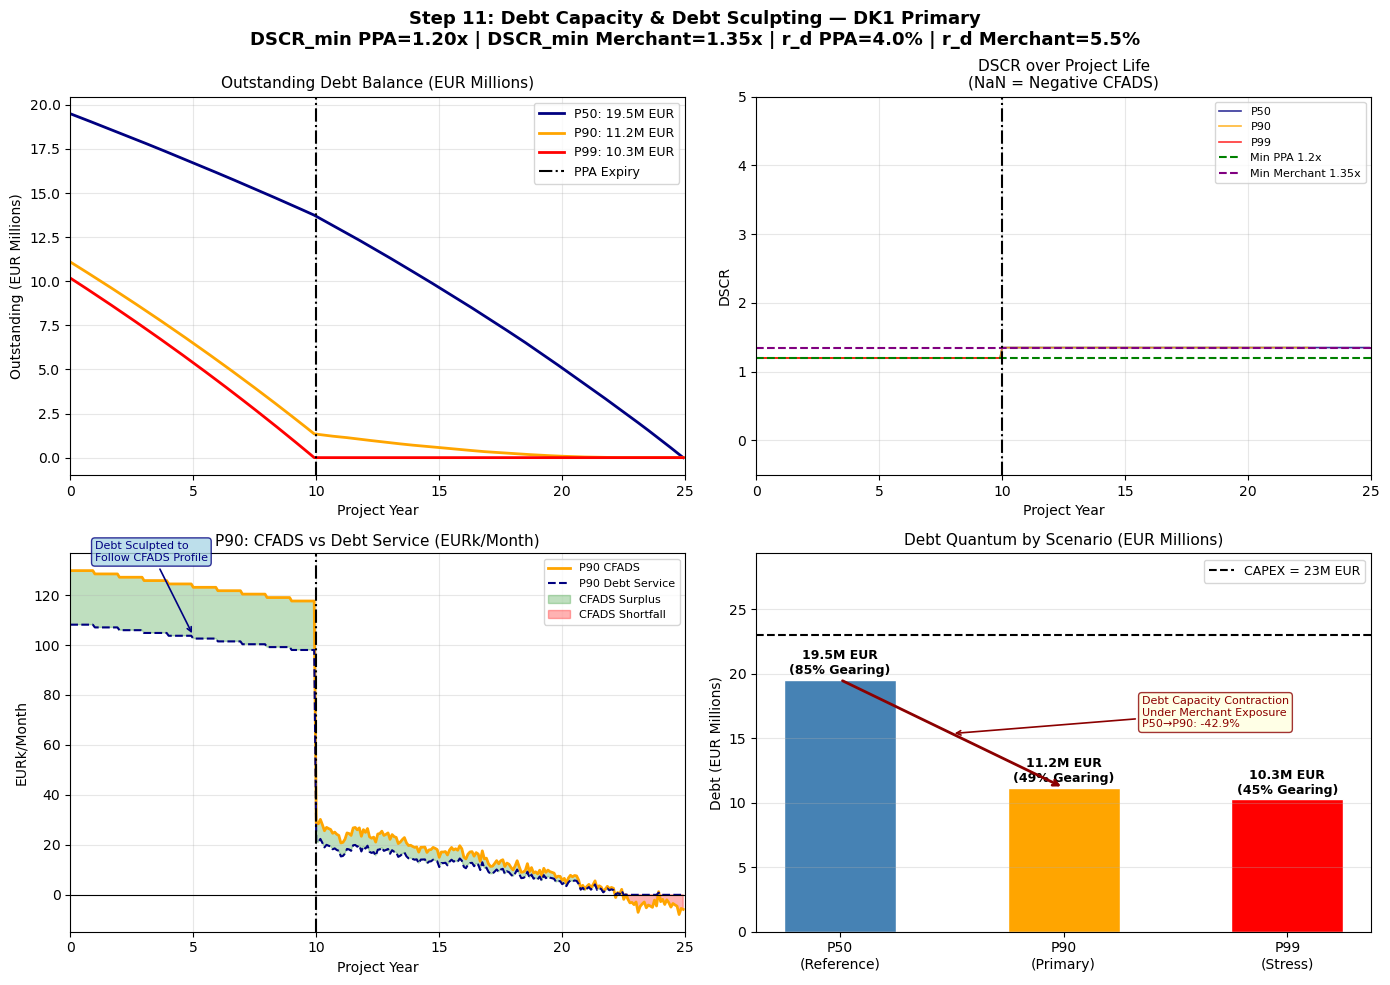

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step9_Debt_Sizing.png
Individual plots saved: Step9a, Step9b, Step9c, Step9d

Exported to Excel: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx
Step 9 complete!


In [98]:
# ── STEP 9: DEBT CAPACITY & DEBT SCULPTING ────────────────────────────────
# ── PARAMETERS ─────────────────────────────────────────────────────────────
DSCR_MIN_PPA    = 1.20
DSCR_MIN_MERCH  = 1.35
R_D_PPA_M       = (1 + 0.04)  **(1/12) - 1
R_D_MERCH_M     = (1 + 0.055) **(1/12) - 1
LOAN_TENOR      = 300
print("=== DEBT SIZING PARAMETERS ===")
print(f"  DSCR min PPA:          {DSCR_MIN_PPA}x")
print(f"  DSCR min Merchant:     {DSCR_MIN_MERCH}x")
print(f"  r_d PPA (annual):      4.00%")
print(f"  r_d Merchant (annual): 5.50%")
# ── CFADS = FCFF (pre-financing, unlevered) ────────────────────────────────
cfads_p50 = fcff_p50.copy()
cfads_p90 = fcff_p90.copy()
cfads_p99 = fcff_p99.copy()
# ── DSCR MINIMUM SCHEDULE ──────────────────────────────────────────────────
dscr_min_schedule = np.where(
    np.arange(N_MONTHS) < PPA_MONTHS,
    DSCR_MIN_PPA,
    DSCR_MIN_MERCH
)
# ── MONTHLY COST OF DEBT SCHEDULE ─────────────────────────────────────────
r_d_schedule = np.where(
    np.arange(N_MONTHS) < PPA_MONTHS,
    R_D_PPA_M,
    R_D_MERCH_M
)
# ── CFADS DIAGNOSTIC ──────────────────────────────────────────────────────
def cfads_diagnostic(cfads, label):
    merchant    = cfads[PPA_MONTHS:]
    neg_months  = (merchant < 0).sum()
    first_neg   = PPA_MONTHS + np.argmax(merchant < 0) + 1 if neg_months > 0 else None
    min_cfads   = merchant.min()
    ppa_cfads   = cfads[:PPA_MONTHS]
    neg_ppa     = (ppa_cfads < 0).sum()
    print(f"\n  [{label}] CFADS DIAGNOSTIC:")
    print(f"    PPA phase:      min={ppa_cfads.min():.2f} EURk | neg months={neg_ppa}")
    print(f"    Merchant phase: min={min_cfads:.2f} EURk | "
          f"neg months={neg_months} / {N_MONTHS - PPA_MONTHS}")
    if first_neg:
        print(f"    First neg CFADS: month {first_neg} (year {first_neg/12:.1f})")
    else:
        print(f"    First neg CFADS: none — merchant CFADS always positive")
    disc_merch_only = np.zeros(N_MONTHS - PPA_MONTHS)
    for i in range(len(disc_merch_only)):
        disc_merch_only[i] = (1/(1+R_D_PPA_M)**PPA_MONTHS
                              * 1/(1+R_D_MERCH_M)**(i+1))
    pos_cfads  = np.maximum(merchant, 0)
    implied_dc = np.sum(pos_cfads / DSCR_MIN_MERCH * disc_merch_only)
    print(f"    Implied merchant debt capacity (positive CFADS only): {implied_dc:,.0f} EURk")
    return neg_months, first_neg, min_cfads
neg_p50, first_p50, _ = cfads_diagnostic(cfads_p50, "P50")
neg_p90, first_p90, _ = cfads_diagnostic(cfads_p90, "P90")
neg_p99, first_p99, _ = cfads_diagnostic(cfads_p99, "P99")
# ── DEBT SCULPTING ALGORITHM ───────────────────────────────────────────────
def debt_sculpt(cfads, dscr_min_sched, r_d_sched, label):
    n         = len(cfads)
    cfads_pos = np.maximum(cfads, 0)
    debt_service = cfads_pos / dscr_min_sched
    discount_factors = np.zeros(n)
    cumulative_r = 1.0
    for t in range(n):
        cumulative_r *= (1 + r_d_sched[t])
        discount_factors[t] = 1 / cumulative_r
    debt_0 = np.sum(debt_service * discount_factors)
    outstanding     = debt_0
    interest_arr    = np.zeros(n)
    principal_arr   = np.zeros(n)
    debt_svc_actual = np.zeros(n)
    dscr_arr        = np.full(n, np.nan)
    outstanding_arr = np.zeros(n)
    for t in range(n):
        interest   = outstanding * r_d_sched[t]
        target_ds  = debt_service[t]
        principal  = max(target_ds - interest, 0)
        principal  = min(principal, outstanding)
        actual_ds  = interest + principal
        outstanding -= principal
        interest_arr[t]    = interest
        principal_arr[t]   = principal
        debt_svc_actual[t] = actual_ds
        outstanding_arr[t] = outstanding
        if actual_ds > 0 and cfads[t] > 0:
            dscr_arr[t] = cfads[t] / actual_ds
        elif actual_ds > 0 and cfads[t] <= 0:
            dscr_arr[t] = np.nan
    llcr = (np.sum(np.maximum(cfads, 0) * discount_factors) / debt_0
            if debt_0 > 0 else np.nan)
    dscr_ppa   = dscr_arr[:PPA_MONTHS]
    dscr_merch = dscr_arr[PPA_MONTHS:]
    min_dscr_ppa    = np.nanmin(dscr_ppa)   if np.any(~np.isnan(dscr_ppa))   else np.nan
    min_dscr_merch  = np.nanmin(dscr_merch) if np.any(~np.isnan(dscr_merch)) else np.nan
    neg_cfads_merch = (cfads[PPA_MONTHS:] < 0).sum()
    print(f"\n  [{label}] DEBT SCULPTING RESULTS:")
    print(f"    Debt quantum D₀:         {debt_0:>10,.0f} EURk")
    print(f"    Gearing (D₀/CAPEX):      {debt_0/CAPEX_EURK:>10.1%}")
    print(f"    LLCR:                    {llcr:>10.2f}x")
    print(f"    Min DSCR PPA:            {min_dscr_ppa:>10.2f}x")
    if np.isnan(min_dscr_merch):
        print(f"    Min DSCR Merchant:       {'N/A — CFADS negative':>10}")
    else:
        print(f"    Min DSCR Merchant:       {min_dscr_merch:>10.2f}x")
    print(f"    Neg CFADS months (merch):{neg_cfads_merch:>9} / "
          f"{N_MONTHS - PPA_MONTHS}")
    return {
        'debt_0':         debt_0,
        'llcr':           llcr,
        'dscr':           dscr_arr,
        'interest':       interest_arr,
        'principal':      principal_arr,
        'debt_service':   debt_svc_actual,
        'outstanding':    outstanding_arr,
        'min_dscr_ppa':   min_dscr_ppa,
        'min_dscr_merch': min_dscr_merch,
        'neg_cfads_merch':neg_cfads_merch,
    }
print("\n=== DEBT SCULPTING ===")
results_p50 = debt_sculpt(cfads_p50, dscr_min_schedule, r_d_schedule, "P50")
results_p90 = debt_sculpt(cfads_p90, dscr_min_schedule, r_d_schedule, "P90")
results_p99 = debt_sculpt(cfads_p99, dscr_min_schedule, r_d_schedule, "P99")
# ── DEBT CAPACITY CONTRACTION ──────────────────────────────────────────────
print("\n=== DEBT CAPACITY CONTRACTION ===")
cont_p90 = (results_p90['debt_0'] - results_p50['debt_0']) / results_p50['debt_0']
cont_p99 = (results_p99['debt_0'] - results_p50['debt_0']) / results_p50['debt_0']
print(f"  P50 → P90: {cont_p90:+.1%}")
print(f"  P50 → P99: {cont_p99:+.1%}")
# ── AMORTISATION CHECK ─────────────────────────────────────────────────────
print("\n=== AMORTISATION CHECK ===")
for lbl, res in [("P50", results_p50), ("P90", results_p90), ("P99", results_p99)]:
    last_ds  = int(np.max(np.where(res['debt_service'] > 0.01)) + 1)
    out_m120 = res['outstanding'][119]
    print(f"  [{lbl}] Outstanding at M120: {out_m120:,.0f} EURk | "
          f"Last DS month: {last_ds} (year {last_ds/12:.1f})")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Step 11: Debt Capacity & Debt Sculpting — DK1 Primary\n'
             'DSCR_min PPA=1.20x | DSCR_min Merchant=1.35x | '
             'r_d PPA=4.0% | r_d Merchant=5.5%',
             fontsize=13, fontweight='bold')
time_years = np.arange(N_MONTHS) / 12
# ── Plot 1: Outstanding Debt ───────────────────────────────────────────────
ax1 = axes[0, 0]
for res, col, lbl in [(results_p50,'navy','P50'),
                       (results_p90,'orange','P90'),
                       (results_p99,'red','P99')]:
    ax1.plot(time_years, res['outstanding']/1000,
             color=col, linewidth=2.0,
             label=f'{lbl}: {res["debt_0"]/1000:,.1f}M EUR')
ax1.axvline(x=10, color='black', linewidth=1.5, linestyle='-.', label='PPA Expiry')
ax1.set_title('Outstanding Debt Balance (EUR Millions)', fontsize=11)
ax1.set_xlabel('Project Year')
ax1.set_ylabel('Outstanding (EUR Millions)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 25)
# ── Plot 2: DSCR Over Time ────────────────────────────────────────────────
ax2 = axes[0, 1]
for res, col, lbl in [(results_p50,'navy','P50'),
                       (results_p90,'orange','P90'),
                       (results_p99,'red','P99')]:
    dscr_plot = np.where(np.isnan(res['dscr']), np.nan, res['dscr'])
    ax2.plot(time_years, dscr_plot, color=col, linewidth=1.2,
             label=lbl, alpha=0.8)
ax2.axhline(y=DSCR_MIN_PPA,   color='green',  linewidth=1.5, linestyle='--',
            label=f'Min PPA {DSCR_MIN_PPA}x')
ax2.axhline(y=DSCR_MIN_MERCH, color='purple', linewidth=1.5, linestyle='--',
            label=f'Min Merchant {DSCR_MIN_MERCH}x')
ax2.axvline(x=10, color='black', linewidth=1.5, linestyle='-.')
ax2.set_title('DSCR over Project Life\n(NaN = Negative CFADS)', fontsize=11)
ax2.set_xlabel('Project Year')
ax2.set_ylabel('DSCR')
ax2.set_ylim(-0.5, 5)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 25)
# ── Plot 3: CFADS vs Debt Service ─────────────────────────────────────────
ax3 = axes[1, 0]
ax3.plot(time_years, cfads_p90,
         color='orange', linewidth=2.0, label='P90 CFADS')
ax3.plot(time_years, results_p90['debt_service'],
         color='navy', linewidth=1.5, linestyle='--', label='P90 Debt Service')
ax3.fill_between(time_years,
                 cfads_p90, results_p90['debt_service'],
                 where=cfads_p90 >= results_p90['debt_service'],
                 alpha=0.25, color='green', label='CFADS Surplus')
ax3.fill_between(time_years,
                 cfads_p90, results_p90['debt_service'],
                 where=cfads_p90 < results_p90['debt_service'],
                 alpha=0.3, color='red', label='CFADS Shortfall')
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.axvline(x=10, color='black', linewidth=1.5, linestyle='-.')
ax3.annotate('Debt Sculpted to\nFollow CFADS Profile',
             xy=(5, float(results_p90['debt_service'][59])),
             xytext=(1, float(results_p90['debt_service'][59]) + 30),
             fontsize=8, color='navy',
             arrowprops=dict(arrowstyle='->', color='navy', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue',
                       edgecolor='navy', alpha=0.8))
ax3.set_title('P90: CFADS vs Debt Service (EURk/Month)', fontsize=11)
ax3.set_xlabel('Project Year')
ax3.set_ylabel('EURk/Month')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 25)
# ── Plot 4: Debt Quantum by Scenario ──────────────────────────────────────
ax4 = axes[1, 1]
scen_labels = ['P50\n(Reference)', 'P90\n(Primary)', 'P99\n(Stress)']
debt_vals   = [results_p50['debt_0']/1000,
               results_p90['debt_0']/1000,
               results_p99['debt_0']/1000]
gearings    = [results_p50['debt_0']/CAPEX_EURK,
               results_p90['debt_0']/CAPEX_EURK,
               results_p99['debt_0']/CAPEX_EURK]
colors_bar  = ['steelblue', 'orange', 'red']
bars = ax4.bar(scen_labels, debt_vals, color=colors_bar,
               edgecolor='white', width=0.5)
ax4.axhline(y=CAPEX_EURK/1000, color='black', linewidth=1.5,
            linestyle='--', label=f'CAPEX = {CAPEX_EURK/1000:.0f}M EUR')
for bar, val, gear in zip(bars, debt_vals, gearings):
    ax4.text(bar.get_x() + bar.get_width()/2,
             val + 0.2,
             f'{val:.1f}M EUR\n({gear:.0%} Gearing)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.annotate('',
             xy=(1, debt_vals[1]),
             xytext=(0, debt_vals[0]),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=2.0))
ax4.annotate(f'Debt Capacity Contraction\nUnder Merchant Exposure\nP50→P90: {cont_p90:.1%}',
             xy=(0.5, (debt_vals[0]+debt_vals[1])/2),
             xytext=(1.35, (debt_vals[0]+debt_vals[1])/2 + 0.5),
             fontsize=8, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='darkred', alpha=0.8))
ax4.set_title('Debt Quantum by Scenario (EUR Millions)', fontsize=11)
ax4.set_ylabel('Debt (EUR Millions)')
ax4.set_ylim(0, max(debt_vals) * 1.5)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# ── Save combined PNG (original) ───────────────────────────────────────────
plot_path = base + '/4. Outputs/Step9_Debt_Sizing.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()

extent1 = axes[0,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step9a_Outstanding_Debt.png', dpi=300, bbox_inches=extent1)

extent2 = axes[0,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step9b_DSCR.png', dpi=300, bbox_inches=extent2)

extent3 = axes[1,0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step9c_CFADS_vs_DebtService.png', dpi=300, bbox_inches=extent3)

extent4 = axes[1,1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step9d_Debt_Quantum.png', dpi=300, bbox_inches=extent4)

print("Individual plots saved: Step9a, Step9b, Step9c, Step9d")

# ── EXPORT TO EXCEL ────────────────────────────────────────────────────────
from openpyxl import load_workbook
master_path = '/Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx'
wb = load_workbook(master_path)
ws = wb['Debt Sizing']
ws.delete_rows(1, ws.max_row)
ws.cell(row=1, column=1,
        value="Debt Sizing — Sculpting Algorithm | "
              "DSCR_min PPA=1.20x | DSCR_min Merchant=1.35x | "
              "r_d PPA=4.00% | r_d Merchant=5.50%")
ws.cell(row=2, column=1,
        value="NOTE: Debt sized on positive CFADS only. "
              "Negative CFADS months indicate periods where "
              "debt service is not supportable.")
ws.cell(row=4, column=1, value="CFADS DIAGNOSTIC")
for col, h in enumerate(["Scenario", "Min CFADS Merchant (EURk)",
                          "Neg CFADS Months (Merchant)",
                          "First Neg Month", "First Neg Year",
                          "Implied Merchant Debt Capacity (EURk)"], 1):
    ws.cell(row=5, column=col, value=h)
for i, (lbl, cfads, neg, first) in enumerate([
    ("P50", cfads_p50, neg_p50, first_p50),
    ("P90", cfads_p90, neg_p90, first_p90),
    ("P99", cfads_p99, neg_p99, first_p99)], 6):
    merchant   = cfads[PPA_MONTHS:]
    disc_m     = np.array([1/(1+R_D_PPA_M)**PPA_MONTHS
                           * 1/(1+R_D_MERCH_M)**(j+1)
                           for j in range(len(merchant))])
    implied_dc = np.sum(np.maximum(merchant, 0) / DSCR_MIN_MERCH * disc_m)
    ws.cell(row=i, column=1, value=lbl)
    ws.cell(row=i, column=2, value=round(float(merchant.min()), 2))
    ws.cell(row=i, column=3, value=int(neg))
    ws.cell(row=i, column=4, value=int(first) if first else "None")
    ws.cell(row=i, column=5, value=round(first/12, 1) if first else "None")
    ws.cell(row=i, column=6, value=round(float(implied_dc), 0))
ws.cell(row=10, column=1, value="DEBT SIZING SUMMARY")
for col, h in enumerate(["Scenario", "Debt Quantum (EURk)",
                          "Gearing (D/CAPEX)", "LLCR",
                          "Min DSCR PPA", "Min DSCR Merchant",
                          "Neg CFADS Months (Merchant)",
                          "Outstanding at M120 (EURk)",
                          "Last Debt Service Month"], 1):
    ws.cell(row=11, column=col, value=h)
for i, (lbl, res) in enumerate([
    ("P50", results_p50),
    ("P90", results_p90),
    ("P99", results_p99)], 12):
    last_ds  = int(np.max(np.where(res['debt_service'] > 0.01)) + 1)
    out_m120 = round(float(res['outstanding'][119]), 0)
    ws.cell(row=i, column=1, value=lbl)
    ws.cell(row=i, column=2, value=round(float(res['debt_0']), 0))
    ws.cell(row=i, column=3, value=round(float(res['debt_0'])/CAPEX_EURK, 4))
    ws.cell(row=i, column=4, value=round(float(res['llcr']), 2))
    ws.cell(row=i, column=5, value=round(float(res['min_dscr_ppa']), 2))
    ws.cell(row=i, column=6,
            value=round(float(res['min_dscr_merch']), 2)
            if not np.isnan(res['min_dscr_merch']) else "N/A")
    ws.cell(row=i, column=7, value=int(res['neg_cfads_merch']))
    ws.cell(row=i, column=8, value=out_m120)
    ws.cell(row=i, column=9, value=last_ds)
ws.cell(row=16, column=1, value="Debt Capacity Contraction P50 → P90")
ws.cell(row=16, column=2, value=round(cont_p90, 4))
ws.cell(row=17, column=1, value="Debt Capacity Contraction P50 → P99")
ws.cell(row=17, column=2, value=round(cont_p99, 4))
ws.cell(row=19, column=1,
        value="MONTHLY DEBT SERVICE SCHEDULE — P90 (Primary Sizing Case)")
for col, h in enumerate(["Month", "Year", "CFADS (EURk)",
                          "Interest (EURk)", "Principal (EURk)",
                          "Debt Service (EURk)", "Outstanding (EURk)",
                          "DSCR"], 1):
    ws.cell(row=20, column=col, value=h)
for t in range(N_MONTHS):
    r        = t + 21
    dscr_val = results_p90['dscr'][t]
    ws.cell(row=r, column=1, value=t+1)
    ws.cell(row=r, column=2, value=round((t+1)/12, 4))
    ws.cell(row=r, column=3, value=round(float(cfads_p90[t]), 4))
    ws.cell(row=r, column=4, value=round(float(results_p90['interest'][t]), 4))
    ws.cell(row=r, column=5, value=round(float(results_p90['principal'][t]), 4))
    ws.cell(row=r, column=6, value=round(float(results_p90['debt_service'][t]), 4))
    ws.cell(row=r, column=7, value=round(float(results_p90['outstanding'][t]), 4))
    ws.cell(row=r, column=8,
            value=round(float(dscr_val), 4)
            if not np.isnan(dscr_val) else "N/A")
wb.save(master_path)
print(f"\nExported to Excel: {master_path}")
print("Step 9 complete!")

# PHASE 7: ROBUSTNESS TESTING

## Step 10: Robustness Testing — Sensitivity Analysis & Scenario Analysis

**Purpose**  
Tests the sensitivity of NPV and debt capacity to changes in key input assumptions.

**Methodology**  
Two complementary stress-testing approaches are applied.

**10A: Tornado Analysis (one-way sensitivity)**  
Each input is varied individually by ±X% while all other inputs are held constant. This identifies which assumptions drive the greatest uncertainty in NPV P50.

**10B: Scenario Analysis (multi-variable)**  
Three internally consistent scenarios are tested simultaneously:
- Optimistic: favourable assumptions across all inputs
- Base case: central assumptions corresponding to the current model
- Pessimistic: adverse assumptions across all inputs

**Specifications**

- **Primary:** NPV sensitivity under the DK1 primary model specification
- **Robustness:** Debt-capacity implications under combined optimistic and pessimistic scenarios

**Parameters / Inputs**
- CAPEX
- PPA price
- NCF
- WACC_PPA
- WACC_merchant
- μ
- σ
- α(t)

**Sub-blocks**
- **10A: Tornado Analysis** — ranked one-way sensitivity of NPV P50 to each input
- **10B: Scenario Analysis** — NPV and debt capacity under optimistic, base-case, and pessimistic combined scenarios

**Output**  
Produces a tornado chart ranking the sensitivity of NPV to each input, a scenario table showing NPV and debt capacity under the three combined scenarios, and an export to the Excel Stress Test sheet.

Base case NPV P50: 3,732 EURk

=== TORNADO ANALYSIS — ONE-WAY SENSITIVITY ===
Input                       Low (-20%)  High (+20%)      Range
--------------------------------------------------------------
CAPEX (EURk)                     8,332         -868      9,200
PPA Price (EUR/MWh)                605        6,859      6,254
NCF (%)                         -2,930       10,392     13,321
WACC_PPA,m                       5,104        2,440      2,664
WACC_merchant,m                  4,551        2,981      1,570
OU mu (EUR/MWh)                     98        7,320      7,222
OU sigma (EUR/MWh)               3,790        3,644        146
Alpha end (%)                    5,086        2,370      2,716

=== SCENARIO ANALYSIS ===
Scenario          NPV P50 (EURk)    vs Base
------------------------------------------
Optimistic                16,496    +12,764
Base Case                  3,732         +0
Pessimistic               -7,461    -11,193


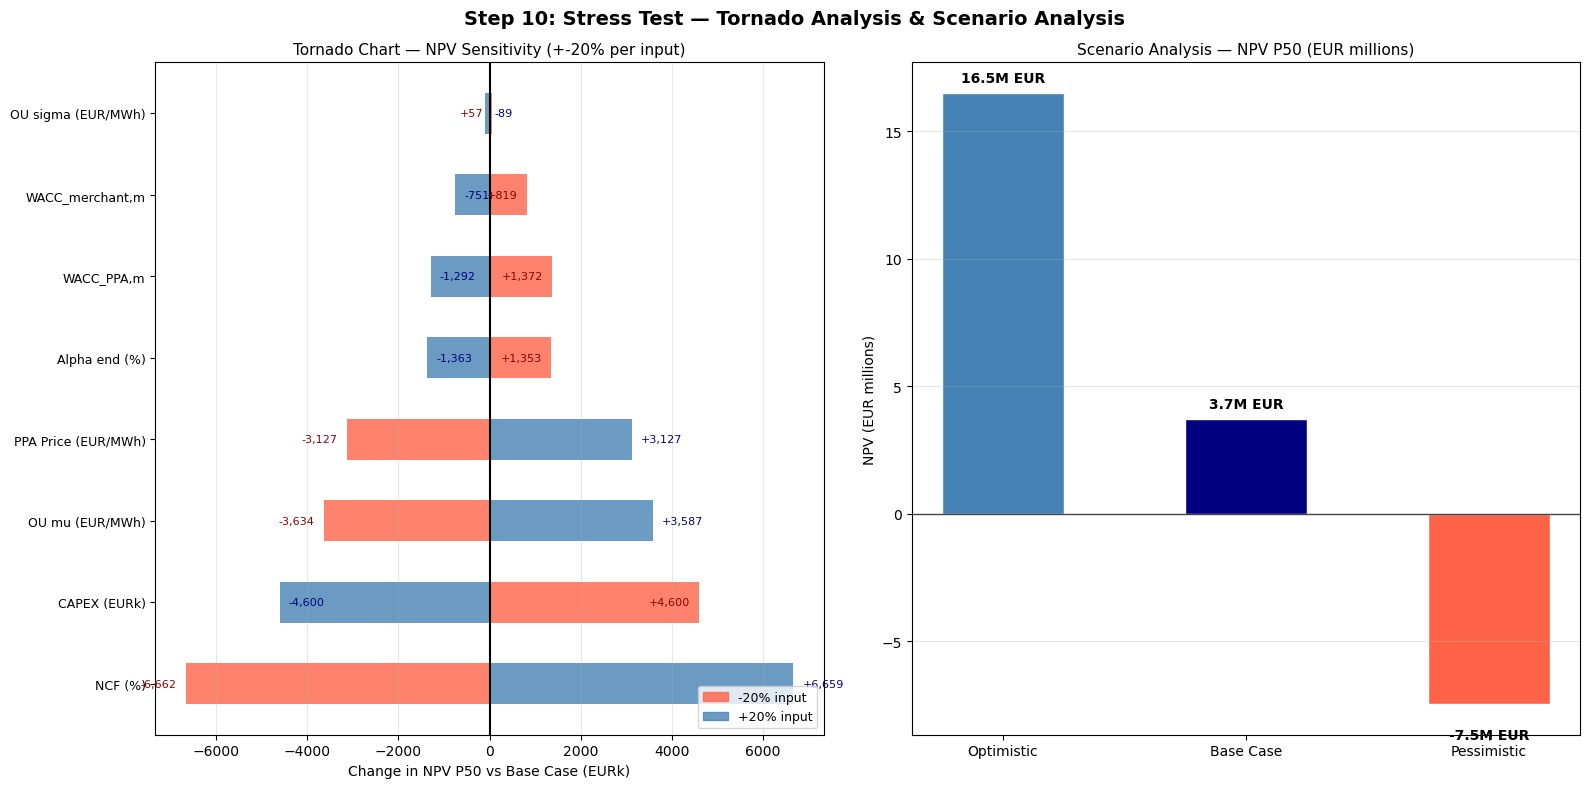

Plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step10_Stress_Test.png
Individual plots saved: Step10a, Step10b

Exported to Excel: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx
Step 10 complete!


In [99]:
# ── STEP 10: STRESS TEST — TORNADO & SCENARIO ANALYSIS ────────────────────
# ── BASE CASE NPV ──────────────────────────────────────────────────────────
npv_base = float(np.percentile(npv_segmented, 50))
print(f"Base case NPV P50: {npv_base:,.0f} EURk")
# ── 10A: TORNADO ANALYSIS ──────────────────────────────────────────────────
print("\n=== TORNADO ANALYSIS — ONE-WAY SENSITIVITY ===")
print(f"{'Input':<25} {'Low (-20%)':>12} {'High (+20%)':>12} {'Range':>10}")
print("-" * 62)
def run_npv(capex=CAPEX_EURK, ncf=NCF_P50, ppa=PPA_PRICE,
            wacc_ppa=WACC_PPA_M, wacc_m=WACC_MERCH_M,
            mu_s=mu_final, sigma_s=sigma_final, alpha_end=0.20):
    prod = np.zeros(N_MONTHS)
    for t in range(N_MONTHS):
        yr = t // 12
        prod[t] = (CAPACITY_MW * 1000 * ncf
                   * 8760 / 12
                   * (1 - DEGRADATION)**yr
                   / 1000)
    disc = np.zeros(N_MONTHS)
    for t in range(N_MONTHS):
        if t < PPA_MONTHS:
            disc[t] = 1 / (1 + wacc_ppa)**(t+1)
        else:
            disc[t] = (1 / (1 + wacc_ppa)**PPA_MONTHS
                       * 1 / (1 + wacc_m)**(t - PPA_MONTHS + 1))
    np.random.seed(42)
    alpha_t_s  = np.linspace(0.05, alpha_end, N_MONTHS)
    mu_cap_s   = mu_s * (1 - alpha_t_s)
    exp_kdt_s  = np.exp(-kappa_final)
    var_s      = (sigma_s**2 / (2*kappa_final)) * (1 - np.exp(-2*kappa_final))
    std_s      = np.sqrt(var_s)
    paths_s       = np.zeros((N_PATHS, N_MONTHS))
    paths_s[:, 0] = mu_s
    for t in range(1, N_MONTHS):
        eps = np.random.normal(0, 1, N_PATHS)
        paths_s[:, t] = (mu_cap_s[t]
                         + (paths_s[:, t-1] - mu_cap_s[t]) * exp_kdt_s
                         + std_s * eps)
    price_s = np.zeros((N_PATHS, N_MONTHS))
    price_s[:, :PPA_MONTHS]  = ppa
    price_s[:, PPA_MONTHS:]  = paths_s[:, PPA_MONTHS:]
    rev_s    = price_s * prod / 1000
    opex_s   = np.tile(monthly_opex, (N_PATHS, 1))
    ebitda_s = rev_s + opex_s
    tax_s    = np.where(ebitda_s > 0, -ebitda_s * TAX_RATE, 0)
    fcff_s   = ebitda_s + tax_s
    npv_s = np.sum(fcff_s * disc, axis=1) - capex
    return float(np.percentile(npv_s, 50))
# ── Define sensitivities ───────────────────────────────────────────────────
sensitivities = [
    ("CAPEX (EURk)",       "capex",     CAPEX_EURK,   0.20),
    ("PPA Price (EUR/MWh)","ppa",       PPA_PRICE,    0.20),
    ("NCF (%)",            "ncf",       NCF_P50,      0.20),
    ("WACC_PPA,m",         "wacc_ppa",  WACC_PPA_M,   0.20),
    ("WACC_merchant,m",    "wacc_m",    WACC_MERCH_M, 0.20),
    ("OU mu (EUR/MWh)",    "mu_s",      mu_final,     0.20),
    ("OU sigma (EUR/MWh)", "sigma_s",   sigma_final,  0.20),
    ("Alpha end (%)",      "alpha_end", 0.20,         0.50),
]
tornado_results = []
for name, param, base_val, pct in sensitivities:
    low_val  = base_val * (1 - pct)
    high_val = base_val * (1 + pct)
    npv_low  = run_npv(**{param: low_val})
    npv_high = run_npv(**{param: high_val})
    rng      = abs(npv_high - npv_low)
    tornado_results.append((name, npv_low, npv_high, rng, base_val, pct))
    print(f"{name:<25} {npv_low:>12,.0f} {npv_high:>12,.0f} {rng:>10,.0f}")
tornado_results.sort(key=lambda x: x[3], reverse=True)
# ── 12B: SCENARIO ANALYSIS ────────────────────────────────────────────────
print("\n=== SCENARIO ANALYSIS ===")
print(f"{'Scenario':<15} {'NPV P50 (EURk)':>16} {'vs Base':>10}")
print("-" * 42)
scenarios_def = {
    "Optimistic": dict(
        capex    = CAPEX_EURK    * 0.85,
        ppa      = PPA_PRICE     * 1.10,
        ncf      = NCF_P50       * 1.10,
        wacc_ppa = WACC_PPA_M    * 0.90,
        wacc_m   = WACC_MERCH_M  * 0.90,
        mu_s     = mu_final      * 1.10,
        sigma_s  = sigma_final   * 0.85,
        alpha_end= 0.15),
    "Base Case": dict(
        capex    = CAPEX_EURK,
        ppa      = PPA_PRICE,
        ncf      = NCF_P50,
        wacc_ppa = WACC_PPA_M,
        wacc_m   = WACC_MERCH_M,
        mu_s     = mu_final,
        sigma_s  = sigma_final,
        alpha_end= 0.20),
    "Pessimistic": dict(
        capex    = CAPEX_EURK    * 1.15,
        ppa      = PPA_PRICE     * 0.90,
        ncf      = NCF_P50       * 0.90,
        wacc_ppa = WACC_PPA_M    * 1.10,
        wacc_m   = WACC_MERCH_M  * 1.10,
        mu_s     = mu_final      * 0.90,
        sigma_s  = sigma_final   * 1.15,
        alpha_end= 0.25),
}
scenario_results = {}
for scen_name, params in scenarios_def.items():
    npv_val = run_npv(**params)
    scenario_results[scen_name] = npv_val
    vs_base = npv_val - npv_base
    print(f"{scen_name:<15} {npv_val:>16,.0f} {vs_base:>+10,.0f}")
# ── VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Step 10: Stress Test — Tornado Analysis & Scenario Analysis',
             fontsize=14, fontweight='bold', y=0.98)
ax1 = axes[0]
names  = [r[0] for r in tornado_results]
lows   = [r[1] - npv_base for r in tornado_results]
highs  = [r[2] - npv_base for r in tornado_results]
y_pos  = range(len(names))
for i, (low, high) in enumerate(zip(lows, highs)):
    ax1.barh(i, low,  color='tomato',    alpha=0.8, height=0.5)
    ax1.barh(i, high, color='steelblue', alpha=0.8, height=0.5)
    ax1.text(low  - 200, i, f'{low:+,.0f}',  va='center', ha='right',
             fontsize=8, color='darkred')
    ax1.text(high + 200, i, f'{high:+,.0f}', va='center', ha='left',
             fontsize=8, color='navy')
ax1.axvline(x=0, color='black', linewidth=1.5)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(names, fontsize=9)
ax1.set_xlabel('Change in NPV P50 vs Base Case (EURk)', fontsize=10)
ax1.set_title('Tornado Chart — NPV Sensitivity (+-20% per input)', fontsize=11)
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato',    alpha=0.8, label='-20% input'),
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.8, label='+20% input')],
    fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3, axis='x')
ax2 = axes[1]
scen_names = list(scenario_results.keys())
scen_vals  = [scenario_results[s]/1000 for s in scen_names]
colors     = ['steelblue', 'navy', 'tomato']
bars = ax2.bar(scen_names, scen_vals, color=colors,
               edgecolor='white', width=0.5)
ax2.axhline(y=0, color='black', linewidth=1.0, linestyle='-', alpha=0.7)
for bar, val in zip(bars, scen_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if val >= 0 else -1.5),
             f'{val:,.1f}M EUR',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('Scenario Analysis — NPV P50 (EUR millions)', fontsize=11)
ax2.set_ylabel('NPV (EUR millions)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# ── Save combined PNG (original) ───────────────────────────────────────────
output_path = base + '/4. Outputs/Step10_Stress_Test.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {output_path}")

# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()

extent1 = axes[0].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step10a_Tornado_Chart.png', dpi=300, bbox_inches=extent1)

extent2 = axes[1].get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step10b_Scenario_Analysis.png', dpi=300, bbox_inches=extent2)

print("Individual plots saved: Step10a, Step10b")

# ── EXPORT TO EXCEL ────────────────────────────────────────────────────────
from openpyxl import load_workbook
master_path = '/Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx'
wb = load_workbook(master_path)
ws = wb['Stress Test']
ws.delete_rows(1, ws.max_row)
ws.cell(row=1, column=1, value="Stress Test — Tornado Analysis & Scenario Analysis")
ws.cell(row=2, column=1,
        value=f"DK1 Primary | Base case NPV P50 = {npv_base:,.0f} EURk")
for col, h in enumerate(["Input", "Base Value", "NPV Low (-20%)",
                          "NPV High (+20%)", "Range (EURk)",
                          "Change Low vs Base", "Change High vs Base"], 1):
    ws.cell(row=4, column=col, value=h)
ws.cell(row=3, column=1, value="TORNADO ANALYSIS — ONE-WAY SENSITIVITY (+-20%)")
for i, (name, npv_low, npv_high, rng, base_val, pct) in \
        enumerate(tornado_results, 5):
    ws.cell(row=i, column=1, value=name)
    ws.cell(row=i, column=2, value=round(base_val, 4))
    ws.cell(row=i, column=3, value=round(npv_low,  0))
    ws.cell(row=i, column=4, value=round(npv_high, 0))
    ws.cell(row=i, column=5, value=round(rng,      0))
    ws.cell(row=i, column=6, value=round(npv_low  - npv_base, 0))
    ws.cell(row=i, column=7, value=round(npv_high - npv_base, 0))
scen_row = 5 + len(tornado_results) + 2
ws.cell(row=scen_row, column=1, value="SCENARIO ANALYSIS")
for col, h in enumerate(["Scenario", "NPV P50 (EURk)",
                          "vs Base Case (EURk)", "vs Base Case (%)"], 1):
    ws.cell(row=scen_row+1, column=col, value=h)
for i, (scen_name, npv_val) in enumerate(scenario_results.items(), 2):
    vs_base = npv_val - npv_base
    ws.cell(row=scen_row+i, column=1, value=scen_name)
    ws.cell(row=scen_row+i, column=2, value=round(npv_val, 0))
    ws.cell(row=scen_row+i, column=3, value=round(vs_base,  0))
    ws.cell(row=scen_row+i, column=4,
            value=round(vs_base/abs(npv_base), 4) if npv_base != 0 else 0)
wb.save(master_path)
print(f"\nExported to Excel: {master_path}")
print("Step 10 complete!")

# FINAL EXPORT (consolidation, not in Figure 2)

## Step 11: Export Results to Output Sheet

**Purpose**  
Consolidates all key analytical results into a single Output sheet for summary reporting, cross-checking, and direct use in the thesis.

**Methodology**  
Results from the calibration, simulation, valuation, debt-sizing, and robustness-testing steps are written into a structured Excel summary sheet.

**Parameters / Inputs**
- OU calibration outputs
- Monte Carlo horizon statistics
- NPV results under segmented and single WACC
- Debt-sizing results under P50, P90, and P99
- Tornado top 5 sensitivity results
- Scenario analysis results
- Final thesis summary statements

**Output**  
Creates a single Output sheet containing:
- OU calibration parameters (DK1 primary + robustness)
- Monte Carlo simulation summary (P50/P90/P99 at key horizons)
- NPV results (Segmented vs Single WACC)
- Debt sizing summary (P50/P90/P99)
- Stress test summary (Tornado top 5 + scenarios)
- Key thesis findings

Step 11 complete — Output sheet exported
  NPV P50 segmented: 3,732 EURk
  Debt contraction P50->P90: -42.9%
Saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx


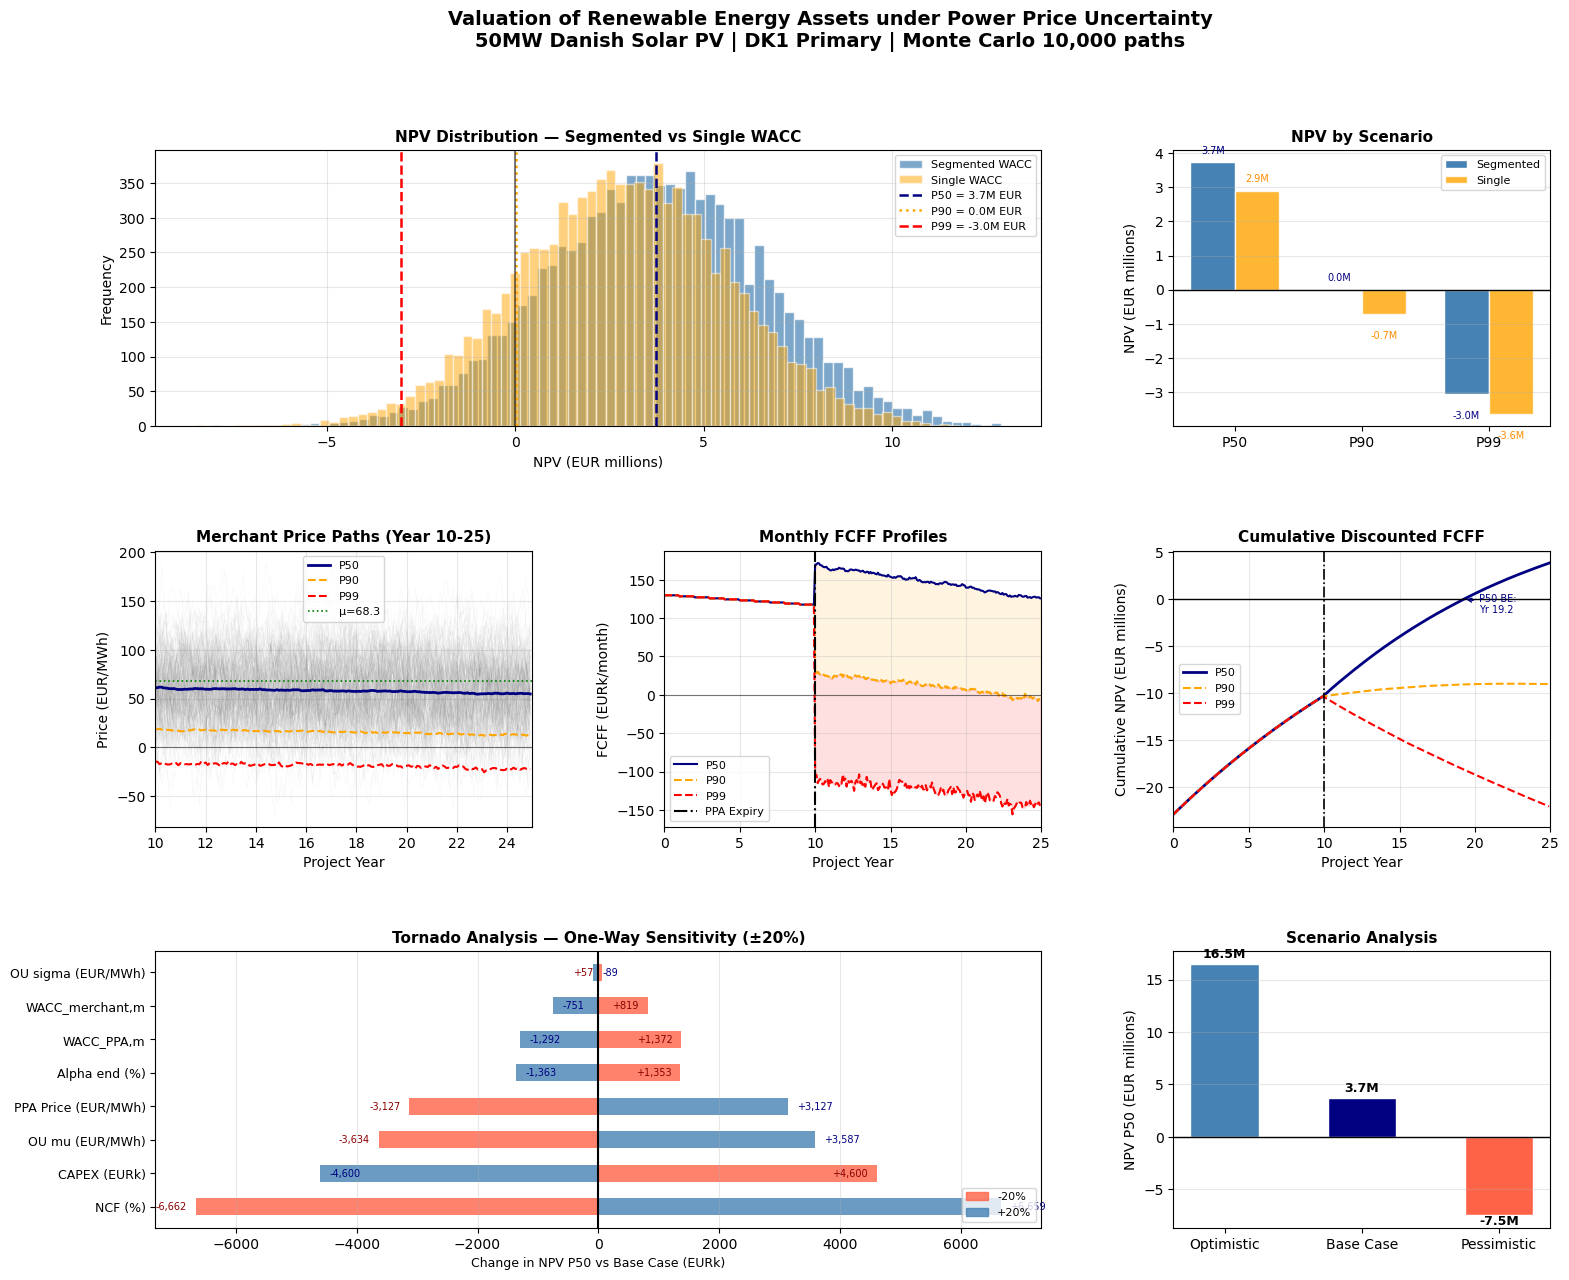

Summary plot saved to: /Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/4. Outputs/Step11_Summary.png
Individual plots saved: Step11a through Step11g


In [100]:
# ── STEP 11: EXPORT RESULTS TO OUTPUT SHEET ────────────────────────────────
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
# ── CALCULATE NPV FROM SCRATCH ──────────────────────────────────────────────
npv_seg_12   = np.sum(fcff * disc_merch,  axis=1) - CAPEX_EURK
npv_sing_12  = np.sum(fcff * disc_single, axis=1) - CAPEX_EURK
npv_base_12  = float(np.percentile(npv_seg_12, 50))
master_path = '/Users/sarahwulff/Desktop/4. Semester/Thesis/4. Analysis/Excel/Master Model.xlsx'
wb = load_workbook(master_path)
ws = wb['Output']
ws.delete_rows(1, ws.max_row)
# ── STYLES ─────────────────────────────────────────────────────────────────
DARK_BLUE  = "1F4E79"
MID_BLUE   = "2E75B6"
LIGHT_BLUE = "D6E4F0"
WHITE      = "FFFFFF"
GREY       = "F2F2F2"
GREEN      = "E2EFDA"
ORANGE     = "FCE4D6"
RED        = "FFE0E0"
thin = Side(style="thin", color="BFBFBF")
bdr  = Border(left=thin, right=thin, top=thin, bottom=thin)
def hf(h): return PatternFill("solid", start_color=h)
def w(ws, row, col, val, bold=False, color="000000", fill=None,
      align="left", fmt=None, size=10):
    c = ws.cell(row=row, column=col, value=val)
    c.font = Font(name="Arial", bold=bold, color=color, size=size)
    c.alignment = Alignment(horizontal=align, vertical="center")
    c.border = bdr
    if fill: c.fill = fill
    if fmt:  c.number_format = fmt
    return c
def section(ws, row, title, n_cols=6):
    ws.merge_cells(f"A{row}:{chr(64+n_cols)}{row}")
    c = ws.cell(row=row, column=1, value=title)
    c.font      = Font(name="Arial", bold=True, color=DARK_BLUE, size=11)
    c.fill      = hf(LIGHT_BLUE)
    c.alignment = Alignment(horizontal="left", vertical="center")
    c.border    = bdr
    ws.row_dimensions[row].height = 18
def header(ws, row, cols):
    for col, val in enumerate(cols, 1):
        c = ws.cell(row=row, column=col, value=val)
        c.font      = Font(name="Arial", bold=True, color=WHITE, size=9)
        c.fill      = hf(MID_BLUE)
        c.alignment = Alignment(horizontal="center", vertical="center")
        c.border    = bdr
    ws.row_dimensions[row].height = 16
# ── TITLE ──────────────────────────────────────────────────────────────────
ws.merge_cells("A1:F1")
c = ws["A1"]
c.value = ("Output Summary — Valuation of Renewable Energy Assets under "
           "Power Price Uncertainty | DK1 Primary Specification")
c.font  = Font(name="Arial", bold=True, color=WHITE, size=12)
c.fill  = hf(DARK_BLUE)
c.alignment = Alignment(horizontal="left", vertical="center")
ws.row_dimensions[1].height = 24
ws.merge_cells("A2:F2")
c = ws["A2"]
c.value = (f"50MW Danish Solar PV | 25-Year Project Life | "
           f"PPA {PPA_MONTHS//12} years @ {PPA_PRICE} EUR/MWh | "
           f"CAPEX {CAPEX_EURK:,} EURk | NCF {NCF_P50:.1%}")
c.font  = Font(name="Arial", italic=True, color="595959", size=9)
c.alignment = Alignment(horizontal="left", vertical="center")
ws.row_dimensions[2].height = 14
r = 4
# ── SECTION 1: OU CALIBRATION ──────────────────────────────────────────────
section(ws, r, "1. OU CALIBRATION PARAMETERS — DK1 PRIMARY"); r += 1
header(ws, r, ["Parameter", "DK1 ex-2022 (Primary)",
               "DK1 Post-crisis", "DK2 ex-2022", "DK2 Post-crisis", "Unit"])
r += 1
for param, v1, v2, v3, v4, unit in [
    ("Long-run mean (mu)",     mu_final,    mu_dk1r,    mu_dk2,    mu_dk2r,    "EUR/MWh"),
    ("Mean reversion (kappa)", kappa_final, kappa_dk1r, kappa_dk2, kappa_dk2r, "/month"),
    ("Volatility (sigma)",     sigma_final, sigma_dk1r, sigma_dk2, sigma_dk2r, "EUR/MWh"),
    ("Half-life",              np.log(2)/kappa_final, np.log(2)/kappa_dk1r,
                               np.log(2)/kappa_dk2,   np.log(2)/kappa_dk2r,   "months"),
]:
    for col, val in enumerate([param, v1, v2, v3, v4, unit], 1):
        fill = hf(GREEN) if col == 2 else hf(WHITE)
        w(ws, r, col,
          round(float(val), 4) if isinstance(val, (float, np.floating)) else val,
          fill=fill, align="center" if col > 1 else "left")
    ws.row_dimensions[r].height = 16
    r += 1
r += 1
# ── SECTION 2: MONTE CARLO SUMMARY ────────────────────────────────────────
section(ws, r, "2. MONTE CARLO SIMULATION — DK1 PRIMARY (10,000 paths)"); r += 1
header(ws, r, ["Horizon", "P50 (EUR/MWh)", "P90 (EUR/MWh)",
               "P99 (EUR/MWh)", "mu_capture (EUR/MWh)", ""])
r += 1
for yr, mo in [(5,59),(10,119),(15,179),(20,239),(25,299)]:
    vals = [f"Year {yr}",
            round(float(np.percentile(paths[:,mo], 50)), 2),
            round(float(np.percentile(paths[:,mo], 10)), 2),
            round(float(np.percentile(paths[:,mo],  1)), 2),
            round(float(mu_capture[mo]), 2), ""]
    for col, val in enumerate(vals, 1):
        fill = hf(LIGHT_BLUE) if yr == 10 else hf(WHITE)
        w(ws, r, col, val, fill=fill,
          align="center" if col > 1 else "left")
    if yr == 10:
        ws.cell(row=r, column=6).value = "<- PPA expiry"
    ws.row_dimensions[r].height = 16
    r += 1
r += 1
# ── SECTION 3: NPV RESULTS ─────────────────────────────────────────────────
section(ws, r, "3. NPV RESULTS — SEGMENTED vs SINGLE WACC"); r += 1
header(ws, r, ["Scenario", "NPV Segmented WACC (EURk)",
               "NPV Single WACC (EURk)", "Difference (EURk)",
               "Difference (%)", "Interpretation"])
r += 1
npv_interp = {
    "P50": "Base case — project marginally viable",
    "P90": "Conservative downside — project loss-making",
    "P99": "Extreme stress — significant loss",
}
for scen, pct in [("P50",50),("P90",10),("P99",1)]:
    seg  = round(float(np.percentile(npv_seg_12,  pct)), 0)
    sing = round(float(np.percentile(npv_sing_12, pct)), 0)
    diff = round(sing - seg, 0)
    pct_diff = round(diff/abs(seg), 4) if seg != 0 else 0
    fill = hf(GREEN) if seg > 0 else hf(RED)
    for col, val in enumerate([scen, seg, sing, diff, pct_diff,
                                npv_interp[scen]], 1):
        w(ws, r, col, val, fill=fill,
          align="center" if 1 < col < 6 else "left",
          fmt='#,##0' if col in [2,3,4] else ('0.0%' if col == 5 else None))
    ws.row_dimensions[r].height = 16
    r += 1
r += 1
# ── SECTION 4: DEBT SIZING ─────────────────────────────────────────────────
section(ws, r, "4. DEBT SIZING — P90 PRIMARY | DSCR_min PPA=1.20x | Merchant=1.35x"); r += 1
header(ws, r, ["Scenario", "Debt Quantum (EURk)", "Gearing (D/CAPEX)",
               "LLCR", "Min DSCR PPA", "Min DSCR Merchant"])
r += 1
for scen, res in [("P50 (reference)", results_p50),
                   ("P90 (primary)",   results_p90),
                   ("P99 (stress)",    results_p99)]:
    fill = hf(ORANGE) if "P90" in scen else hf(WHITE)
    vals = [scen,
            round(float(res['debt_0']), 0),
            round(float(res['debt_0'])/CAPEX_EURK, 4),
            round(float(res['llcr']), 2),
            round(float(res['dscr'][:PPA_MONTHS].min()), 2),
            round(min(float(res['dscr'][PPA_MONTHS:].min()), 99), 2)]
    for col, val in enumerate(vals, 1):
        w(ws, r, col, val, fill=fill,
          align="center" if col > 1 else "left",
          fmt='#,##0' if col == 2 else ('0.0%' if col == 3 else None))
    ws.row_dimensions[r].height = 16
    r += 1
r += 1
w(ws, r, 1, "Debt Capacity Contraction (P50 -> P90):", bold=True, fill=hf(GREY))
w(ws, r, 2,
  round((results_p90['debt_0']-results_p50['debt_0'])/results_p50['debt_0'], 4),
  fill=hf(GREY), fmt='0.0%', align="center")
ws.row_dimensions[r].height = 16; r += 1
w(ws, r, 1, "Debt Capacity Contraction (P50 -> P99):", bold=True, fill=hf(GREY))
w(ws, r, 2,
  round((results_p99['debt_0']-results_p50['debt_0'])/results_p50['debt_0'], 4),
  fill=hf(GREY), fmt='0.0%', align="center")
ws.row_dimensions[r].height = 16; r += 2
# ── SECTION 5: STRESS TEST SUMMARY ────────────────────────────────────────
section(ws, r, "5. STRESS TEST — TOP 5 SENSITIVITIES & SCENARIO ANALYSIS"); r += 1
header(ws, r, ["Input", "NPV Low (-20%) (EURk)", "NPV Base (EURk)",
               "NPV High (+20%) (EURk)", "Range (EURk)", "Rank"])
r += 1
for rank, (name, npv_low, npv_high, rng, _, _) in enumerate(tornado_results[:5], 1):
    vals = [name,
            round(float(npv_low),      0),
            round(float(npv_base_12),  0),
            round(float(npv_high),     0),
            round(float(rng),          0),
            rank]
    for col, val in enumerate(vals, 1):
        w(ws, r, col, val, fill=hf(WHITE),
          align="center" if col > 1 else "left",
          fmt='#,##0' if col in [2,3,4,5] else None)
    ws.row_dimensions[r].height = 16
    r += 1
r += 1
header(ws, r, ["Scenario", "NPV P50 (EURk)", "vs Base (EURk)",
               "vs Base (%)", "", ""])
r += 1
scen_fills = {"Optimistic": hf(GREEN), "Base Case": hf(WHITE),
              "Pessimistic": hf(ORANGE)}
for scen_name, npv_val in scenario_results.items():
    npv_val_f = float(npv_val)
    vs_base   = round(npv_val_f - npv_base_12, 0)
    vals = [scen_name, round(npv_val_f, 0), vs_base,
            round(vs_base/abs(npv_base_12), 4) if npv_base_12 != 0 else 0,
            "", ""]
    for col, val in enumerate(vals, 1):
        w(ws, r, col, val, fill=scen_fills[scen_name],
          align="center" if col > 1 else "left",
          fmt='#,##0' if col in [2,3] else ('0.0%' if col == 4 else None))
    ws.row_dimensions[r].height = 16
    r += 1
r += 1
# ── SECTION 6: KEY THESIS FINDINGS ────────────────────────────────────────
section(ws, r, "6. KEY THESIS FINDINGS"); r += 1
npv_diff  = round(float(np.percentile(npv_sing_12, 50))
                  - float(np.percentile(npv_seg_12, 50)), 0)
debt_cont = abs(round((results_p90['debt_0']-results_p50['debt_0'])
                      / results_p50['debt_0']*100, 1))
tor_1     = round(float(tornado_results[0][3]), 0)
tor_2     = round(float(tornado_results[1][3]), 0)
tor_last  = round(float(tornado_results[-1][3]), 0)
npv_p50   = round(float(np.percentile(npv_seg_12, 50)), 0)
npv_p99   = round(float(np.percentile(npv_seg_12,  1)), 0)
findings = [
    ("Finding 1",
     f"Segmented WACC framework produces higher NPV than single WACC "
     f"(difference: {npv_diff:+,.0f} EURk at P50). "
     f"Single WACC systematically overestimates the discount rate applied "
     f"to contracted PPA cash flows, leading to systematic undervaluation."),
    ("Finding 2",
     f"Merchant tail risk causes significant debt capacity contraction of "
     f"{debt_cont:.1f}% from P50 to P90. "
     f"A lender using P50 to size debt would over-leverage the project. "
     f"P90 is the appropriate conservative basis for debt sizing in "
     f"non-recourse project finance."),
    ("Finding 3",
     f"NCF (capacity factor) is the primary value driver "
     f"(sensitivity range: {tor_1:,.0f} EURk), "
     f"followed by long-run mean price mu ({tor_2:,.0f} EURk). "
     f"OU volatility sigma has negligible NPV impact ({tor_last:,.0f} EURk) — "
     f"volatility affects risk distribution, not expected value."),
    ("Finding 4",
     f"P50 NPV = {npv_p50:,.0f} EURk under segmented WACC. "
     f"P99 NPV = {npv_p99:,.0f} EURk under extreme merchant stress. "
     f"The segmented WACC framework reveals a valuation gap that a single "
     f"blended WACC would obscure, with material implications for both "
     f"equity valuation and debt capacity assessment."),
]
for finding, text in findings:
    w(ws, r, 1, finding, bold=True, fill=hf(LIGHT_BLUE))
    ws.merge_cells(f"B{r}:F{r}")
    c = ws.cell(row=r, column=2, value=text)
    c.font      = Font(name="Arial", size=9)
    c.alignment = Alignment(horizontal="left", vertical="center",
                             wrap_text=True)
    c.border    = bdr
    ws.row_dimensions[r].height = 45
    r += 1
# ── COLUMN WIDTHS ──────────────────────────────────────────────────────────
ws.column_dimensions['A'].width = 32
ws.column_dimensions['B'].width = 20
ws.column_dimensions['C'].width = 18
ws.column_dimensions['D'].width = 18
ws.column_dimensions['E'].width = 16
ws.column_dimensions['F'].width = 35
wb.save(master_path)
print("Step 11 complete — Output sheet exported")
print(f"  NPV P50 segmented: {npv_p50:,.0f} EURk")
print(f"  Debt contraction P50->P90: -{debt_cont:.1f}%")
print(f"Saved to: {master_path}")

# ── STEP 11: SUMMARY VISUALISATION ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Valuation of Renewable Energy Assets under Power Price Uncertainty\n'
             '50MW Danish Solar PV | DK1 Primary | Monte Carlo 10,000 paths',
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
# ── PLOT 1: NPV Distribution ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
npv_seg_12  = np.sum(fcff * disc_merch,  axis=1) - CAPEX_EURK
npv_sing_12 = np.sum(fcff * disc_single, axis=1) - CAPEX_EURK
ax1.hist(npv_seg_12/1000,  bins=80, color='steelblue', alpha=0.7,
         edgecolor='white', label='Segmented WACC')
ax1.hist(npv_sing_12/1000, bins=80, color='orange',    alpha=0.5,
         edgecolor='white', label='Single WACC')
for pct, col, ls in [(50,'navy','--'),(10,'orange',':'),(1,'red','--')]:
    v = np.percentile(npv_seg_12, pct)/1000
    ax1.axvline(x=v, color=col, linewidth=1.8, linestyle=ls,
                label=f'P{100-pct if pct!=50 else 50} = {v:,.1f}M EUR')
ax1.axvline(x=0, color='black', linewidth=1.2, alpha=0.6)
ax1.set_title('NPV Distribution — Segmented vs Single WACC', fontsize=11, fontweight='bold')
ax1.set_xlabel('NPV (EUR millions)')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
# ── PLOT 2: NPV Summary bar ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
scenarios  = ['P50', 'P90', 'P99']
seg_vals   = [np.percentile(npv_seg_12,  p)/1000 for p in [50, 10, 1]]
sing_vals  = [np.percentile(npv_sing_12, p)/1000 for p in [50, 10, 1]]
x     = np.arange(3)
width = 0.35
b1 = ax2.bar(x - width/2, seg_vals,  width, color='steelblue',
             label='Segmented', edgecolor='white')
b2 = ax2.bar(x + width/2, sing_vals, width, color='orange',
             label='Single',    edgecolor='white', alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=1.0)
for bar in list(b1) + list(b2):
    v = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.2 if v >= 0 else -0.8),
             f'{v:,.1f}M', ha='center', va='bottom', fontsize=7,
             color='navy' if bar in b1 else 'darkorange')
ax2.set_title('NPV by Scenario', fontsize=11, fontweight='bold')
ax2.set_ylabel('NPV (EUR millions)')
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')
# ── PLOT 3: Monte Carlo price paths ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
time_years = np.arange(N_MONTHS) / 12
for i in np.random.choice(N_PATHS, 200, replace=False):
    ax3.plot(time_years[PPA_MONTHS:], paths[i, PPA_MONTHS:],
             color='grey', alpha=0.05, linewidth=0.5)
ax3.plot(time_years[PPA_MONTHS:],
         np.percentile(paths[:, PPA_MONTHS:], 50, axis=0),
         color='navy',   linewidth=2.0, label='P50')
ax3.plot(time_years[PPA_MONTHS:],
         np.percentile(paths[:, PPA_MONTHS:], 10, axis=0),
         color='orange', linewidth=1.5, linestyle='--', label='P90')
ax3.plot(time_years[PPA_MONTHS:],
         np.percentile(paths[:, PPA_MONTHS:], 1,  axis=0),
         color='red',    linewidth=1.5, linestyle='--', label='P99')
ax3.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax3.axhline(y=mu_final, color='green', linewidth=1.2,
            linestyle=':', label=f'μ={mu_final:.1f}')
ax3.set_title('Merchant Price Paths (Year 10-25)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Project Year')
ax3.set_ylabel('Price (EUR/MWh)')
ax3.legend(fontsize=8)
ax3.set_xlim(10, 25)
ax3.grid(True, alpha=0.3)
# ── PLOT 4: FCFF profiles ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_years, fcff_p50, color='navy',   linewidth=1.5, label='P50')
ax4.plot(time_years, fcff_p90, color='orange', linewidth=1.5,
         linestyle='--', label='P90')
ax4.plot(time_years, fcff_p99, color='red',    linewidth=1.5,
         linestyle='--', label='P99')
ax4.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax4.axvline(x=10, color='black', linewidth=1.5, linestyle='-.',
            label='PPA Expiry')
ax4.fill_between(time_years, fcff_p90, fcff_p50, alpha=0.12, color='orange')
ax4.fill_between(time_years, fcff_p99, fcff_p90, alpha=0.12, color='red')
ax4.set_title('Monthly FCFF Profiles', fontsize=11, fontweight='bold')
ax4.set_xlabel('Project Year')
ax4.set_ylabel('FCFF (EURk/month)')
ax4.legend(fontsize=8)
ax4.set_xlim(0, 25)
ax4.grid(True, alpha=0.3)
# ── PLOT 5: Cumulative NPV ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
cum_p50 = np.cumsum(fcff_p50 * disc_merch) - CAPEX_EURK
cum_p90 = np.cumsum(fcff_p90 * disc_merch) - CAPEX_EURK
cum_p99 = np.cumsum(fcff_p99 * disc_merch) - CAPEX_EURK
ax5.plot(time_years, cum_p50/1000, color='navy',   linewidth=2.0, label='P50')
ax5.plot(time_years, cum_p90/1000, color='orange', linewidth=1.5,
         linestyle='--', label='P90')
ax5.plot(time_years, cum_p99/1000, color='red',    linewidth=1.5,
         linestyle='--', label='P99')
ax5.axhline(y=0, color='black', linewidth=1.0)
ax5.axvline(x=10, color='black', linewidth=1.2, linestyle='-.')
for arr, col, lbl in [(cum_p50,'navy','P50'),(cum_p90,'orange','P90')]:
    cross = np.where(np.diff(np.sign(arr)))[0]
    if len(cross) > 0:
        be = time_years[cross[0]]
        ax5.annotate(f'{lbl} BE:\nYr {be:.1f}',
                     xy=(be, 0), xytext=(be+1, -1.5),
                     fontsize=7, color=col,
                     arrowprops=dict(arrowstyle='->', color=col, lw=1.0))
ax5.set_title('Cumulative Discounted FCFF', fontsize=11, fontweight='bold')
ax5.set_xlabel('Project Year')
ax5.set_ylabel('Cumulative NPV (EUR millions)')
ax5.legend(fontsize=8)
ax5.set_xlim(0, 25)
ax5.grid(True, alpha=0.3)
# ── PLOT 6: Tornado chart ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
npv_base_12 = float(np.percentile(npv_seg_12, 50))
names  = [r[0] for r in tornado_results]
lows   = [r[1] - npv_base_12 for r in tornado_results]
highs  = [r[2] - npv_base_12 for r in tornado_results]
y_pos  = range(len(names))
for i, (low, high) in enumerate(zip(lows, highs)):
    ax6.barh(i, low,  color='tomato',    alpha=0.8, height=0.5)
    ax6.barh(i, high, color='steelblue', alpha=0.8, height=0.5)
    ax6.text(low  - 150, i, f'{low:+,.0f}',  va='center', ha='right',
             fontsize=7, color='darkred')
    ax6.text(high + 150, i, f'{high:+,.0f}', va='center', ha='left',
             fontsize=7, color='navy')
ax6.axvline(x=0, color='black', linewidth=1.5)
ax6.set_yticks(list(y_pos))
ax6.set_yticklabels(names, fontsize=9)
ax6.set_xlabel('Change in NPV P50 vs Base Case (EURk)', fontsize=9)
ax6.set_title('Tornado Analysis — One-Way Sensitivity (±20%)',
              fontsize=11, fontweight='bold')
ax6.legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato',    alpha=0.8, label='-20%'),
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.8, label='+20%')],
    fontsize=8, loc='lower right')
ax6.grid(True, alpha=0.3, axis='x')
# ── PLOT 7: Scenario analysis ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
scen_names = list(scenario_results.keys())
scen_vals  = [scenario_results[s]/1000 for s in scen_names]
colors     = ['steelblue', 'navy', 'tomato']
bars = ax7.bar(scen_names, scen_vals, color=colors,
               edgecolor='white', width=0.5)
ax7.axhline(y=0, color='black', linewidth=1.0)
for bar, val in zip(bars, scen_vals):
    ax7.text(bar.get_x() + bar.get_width()/2,
             val + (0.3 if val >= 0 else -1.2),
             f'{val:,.1f}M', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax7.set_title('Scenario Analysis', fontsize=11, fontweight='bold')
ax7.set_ylabel('NPV P50 (EUR millions)')
ax7.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ── Save combined PNG (original) ───────────────────────────────────────────
summary_path = base + '/4. Outputs/Step11_Summary.png'
plt.savefig(summary_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Summary plot saved to: {summary_path}")

# ── Save individual PNGs ───────────────────────────────────────────────────
renderer = fig.canvas.get_renderer()

extent1 = ax1.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11a_NPV_Distribution.png', dpi=300, bbox_inches=extent1)

extent2 = ax2.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11b_NPV_by_Scenario.png', dpi=300, bbox_inches=extent2)

extent3 = ax3.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11c_Merchant_Price_Paths.png', dpi=300, bbox_inches=extent3)

extent4 = ax4.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11d_FCFF_Profiles.png', dpi=300, bbox_inches=extent4)

extent5 = ax5.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11e_Cumulative_NPV.png', dpi=300, bbox_inches=extent5)

extent6 = ax6.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11f_Tornado.png', dpi=300, bbox_inches=extent6)

extent7 = ax7.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig(base + '/4. Outputs/Step11g_Scenario_Analysis.png', dpi=300, bbox_inches=extent7)

print("Individual plots saved: Step11a through Step11g")